---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 2"</h2></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми курсу:</b></p>
<ul style="text-align: left;">
  <li>Перехідні процеси в лінійних електричних колах</li>
  <li>Операторний метод (перетворення Лапласа)</li>
  <li>Перехідні процеси 2-го порядку (RLC)</li>
  <li>Довга лінія (телеграфне рівняння)</li>
  <li>Радіотехнічні сигнали</li>
  <li>Елементи функціонального аналізу</li>
  <li>Ряди та перетворення Фур'є</li>
  <li>Кореляційний аналіз та модуляція сигналів</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<img src="Teacher.jpg" width="150" style="border-radius: 50%; display: block; margin: 10px auto;"/>
<p style="text-align: center;"><b>Пахалюк Богдан Петрович</b></p>
<p style="text-align: center;">Доктор філософії</p>
<p style="text-align: center;">Кафедра РТВС</p>
<hr/>
<p style="text-align: center; font-size: 0.9em;">Частина 2 з 2</p>
</div>
    </th>
  </tr>
</table>

---

<p style="text-align: center;"><b>Зміст</b></p>

* [Перехідні процеси в лінійних електричних ланцюгах](#commutation-law)
    * [Перший закон комутації](#first-commutation-law)
    * [Другий закон комутації](#second-commutation-law)
    * [RL ланцюг: розрахунок та інтерактивний аналіз](#RL-comutation-calculation-classic)
    * [RC ланцюг: розрахунок та інтерактивний аналіз](#RC-comutation-calculation-classic)
    * [Порядок розрахунку, характеристичне рівняння, сталі інтегрування](#classical-method-algorithm)
    * [Вмикання кіл на синусоїдну напругу](#ac-switching)
* [Операторний метод розрахунку перехідних процесів](#Comutation-calculation-laplace)
    * [Закони Кірхгофа в операторній формі](#Laplace-laws)
    * [Таблиця перетворень Лапласа](#laplace-table)
    * [Правила переходу від оригіналу до зображення](#Laplace-transform-law)
    * [Розрахунок RC ланцюга операторним методом](#RC-comutation-calculation-laplace)
* [Перехідні процеси другого порядку](#Comutation-calculation-2nd-order)
    * [Послідовне включення RLC](#RLC-serial-comutation-calculation-classic)
    * [Паралельне включення RLC](#RLC-parallel-comutation-calculation-classic)
* [Довга лінія](#transmission-line)
    * [Параметри та інтерактивний аналіз](#transmission-line-interactive)
    * [Моделювання ланцюговою схемою](#line-ladder-model)
    * [Телеграфне рівняння](#Line-Telegraphe-equation)
    * [Рухома хвиля: пряма і зворотна](#traveling-wave)
    * [Лінія, що не спотворює. Лінія без втрат](#distortionless-line)
* [Радіотехнічні сигнали. Основні поняття](#radio-signals-intro)
* [Елементи функціонального аналізу](#functional-analysis)
* [Ряди та перетворення Фур'є](#Fourier_series)
    * [Узагальнений ряд Фур'є](#Fourier_series_basic)
    * [Тригонометричний ряд Фур'є](#Fourier_series_trig)
    * [Спектральна діаграма](#spectral-diagram)
    * [Комплексна форма ряду Фур'є](#Fourier_series_complex)
    * [Інтерактивна візуалізація](#fourier-interactive)
    * [Пряме та зворотне перетворення Фур'є, властивості, формула Релея](#fourier-transform-direct-inverse)
* [Кореляційний аналіз та модуляція сигналів](#correlation-modulation)
    * [Взаємна спектральна густина. Енергетичний спектр](#cross-spectral-density)
    * [Автокореляційна та взаємокореляційна функції](#autocorrelation)
    * [Амплітудна, балансна, однополосна модуляції](#am-modulation)
    * [Фазова та частотна модуляції](#fm-pm-modulation)
    * [Теорема Котельникова](#kotelnikov-theorem)

---

In [1]:
import sympy as smp
import sympy as sp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

/home/bp/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати фізичну суть перехідних процесів та причини їх виникнення
> - Формулювати перший та другий закони комутації
> - Визначати початкові умови за законами комутації
> - Розраховувати перехідні процеси в RL та RC ланцюгах класичним методом
> - Знаходити постійну часу та будувати часові діаграми

</div>

### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **Перехідний процес** | Зміна струмів/напруг при переході між усталеними режимами |
| **Комутація** | Зміна параметрів або топології кола (перемикання ключів) |
| **Постійна часу $\tau$** | Час, за який перехідна складова зменшується в $e$ разів |
| **Усталений режим** | Режим, при якому всі змінні не залежать від часу (або змінюються за законом джерела) |
| **Початкові умови** | Значення струмів та напруг безпосередньо після комутації $t(0_+)$ |



# Перехідні процеси в лінійних електричних ланцюгах із зосередженими параметрами, основні поняття та визначення <a class="anchor" id="commutation-law"></a>
    
**Перехідним** називається процес зміни в часі струмів та напруг, який виникає в електричній схемі при переході від одного усталеного режиму до іншого внаслідок комутації.

**Комутація** – це зміна параметрів елементів (наприклад, зміна величини опору резистора) або зміна топології кола, яку на електричній схемі відображають за допомогою ідеальних ключів.

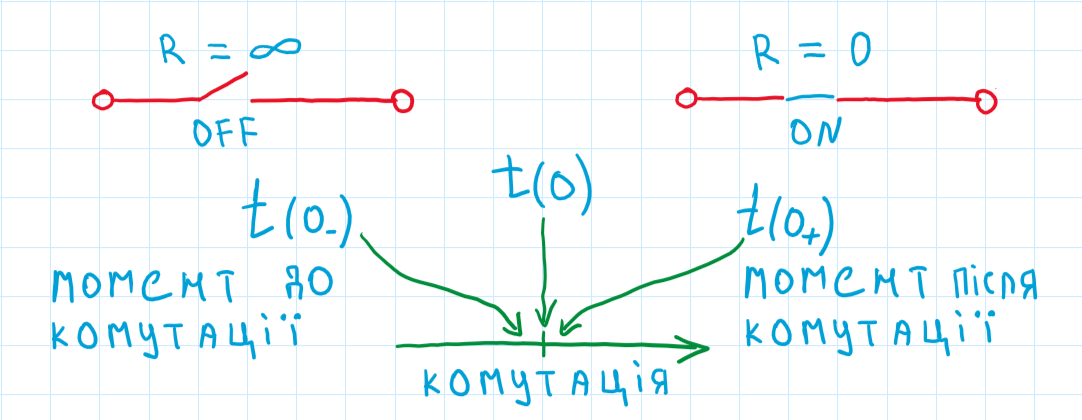

**Ідеальні ключі** мають такі властивості:
1. в замкненому стані опір ключа дорівнює нулю;
1. в розімкненому стані провідність ключа дорівнює нулю;
1. час перемикання ключа дорівнює нулю

Необхідними умовами **виникнення перехідних процесів** є:
- наявність у колі хоча б одного реактивного елемента, оскільки саме в часовому процесі переходу від одного усталеного режиму до іншого змінюється накопичена в цьому елементі електромагнітна енергія;
- наявність саме такої комутації, при якій замикаючий ключ знаходиться під ненульовою напругою, або розмикаючий ключ проводить ненульовій струм, оскільки за протилежних умов комутація не змінює стану електричного кола.

---
---

## Перший закон комутації <a class="anchor" id="first-commutation-law"></a>

Розглянемо схему з індуктивністю **L** і резистором **R**:

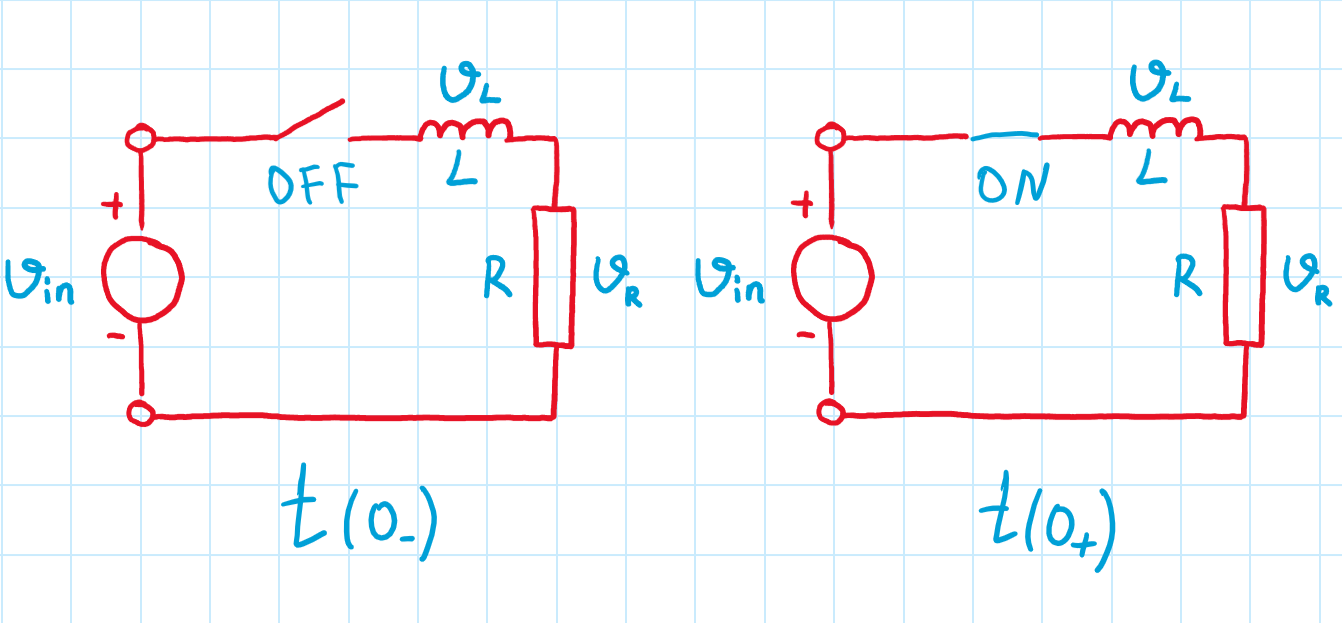

Запишемо рівняння яке описує схему:

$$
  v_{in} = v_{R} + v_{L}
$$

Враховуючи що:

$$
v_{R} = i R; \quad   v_{L} = L \frac{di}{dt};
$$

$$
  v_{in} = i R + L \frac{di}{dt}
$$

Якщо би струм міг змінюватись миттєво то похідна струму $i$ буде наближатись до $\infty$:

$$
  \frac{di}{dt} => \infty 
$$ 
  
І відповідно:

$$
  v_{L} = L \frac{di}{dt} => \infty
$$

> У початковий момент після комутації струм в котушці індуктивності залишається саме таким, яким він був безпосередньо перед комутацією

$$
  i_{L}(0_{-}) = i_{L}(0_{+})
$$

---
---

## Другий закон комутації  <a class="anchor" id="second-commutation-law"></a>
    
Розглянемо схему з ємністю **C** і резистором **R**:

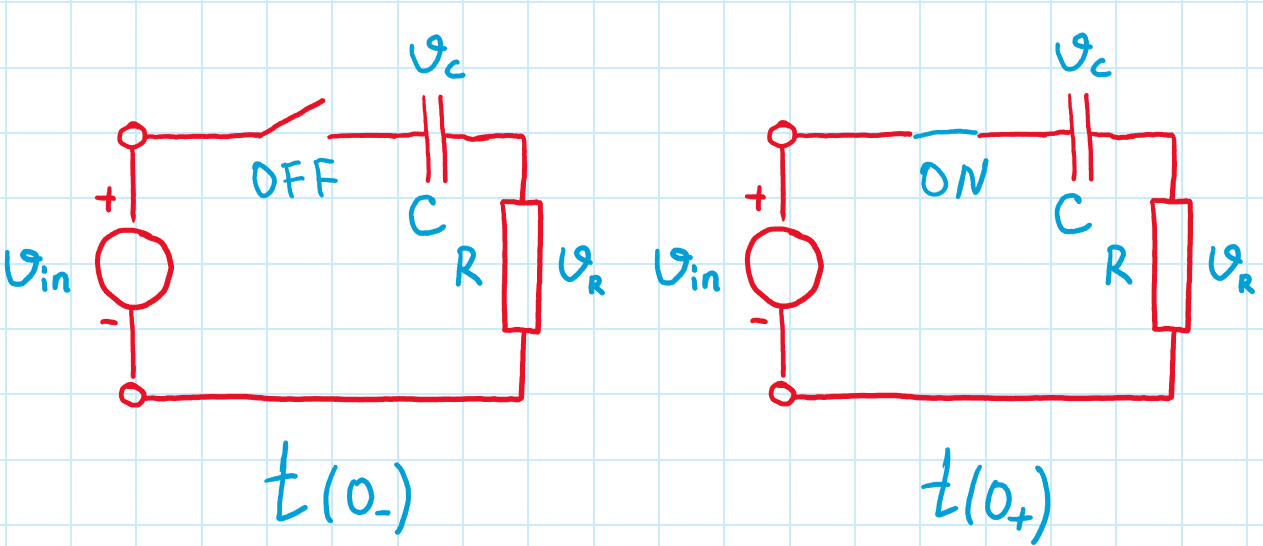

Запишемо рівняння яке описує схему:

$$
  v_{in} = v_{R} + v_{С};
$$

Враховуючи що:

$$
i_{C} = C \frac{d v_{C}}{dt};
$$

$$
  v_{in} = v_{c} + R C \frac{d v_{C}}{dt};
$$

Якщо би напруга могла змінюватись миттєво:

$$
  \frac{d v_{C}}{dt} => \infty 
$$ 
  
І відповідно:

$$
  i_{C} = C \frac{d v_{C}}{dt} => \infty
$$

> у початковий момент після комутації напруга на конденсаторі залишається саме такою, якою вона була безпосередньо перед комутацією

$$
  v_{C}(0_{-}) = v_{C}(0_{+})
$$

---
---

## Порядок розрахунку перехідних процесів класичним методом <a class="anchor" id="classical-method-algorithm"></a>

Розрахунок перехідного процесу класичним методом виконують у такій послідовності:

1. **Визначають незалежні початкові умови** — значення $i_L(0_-)$ і $u_C(0_-)$ у колі **до** комутації (в усталеному режимі), і за законами комутації переносять їх на момент одразу після комутації: $i_L(0_+)=i_L(0_-)$, $u_C(0_+)=u_C(0_-)$.
2. **Складають диференціальне рівняння кола після комутації** відносно шуканої величини (струму чи напруги), використовуючи закони Кірхгофа та рівняння елементів.
3. **Знаходять вимушену (усталену) складову** $x_{вим}(t)$ — розв'язок для нового усталеного режиму (значення джерела після комутації: стала напруга, синусоїда тощо).
4. **Складають характеристичне рівняння** однорідного диференціального рівняння і знаходять його корені $p_k$ — вони визначають вигляд вільної складової $x_{вл}(t)$.
5. **Записують загальний розв'язок** $x(t)=x_{вим}(t)+x_{вл}(t)$ з невідомими сталими інтегрування, і, підставивши початкові умови (за потреби — і їх похідні в момент $t=0_+$), знаходять ці сталі.
6. **Записують кінцевий вираз** $x(t)$ і за потреби будують часову діаграму.

## Характеристичне рівняння: способи отримання і властивості коренів <a class="anchor" id="characteristic-equation"></a>

**Спосіб 1 — з диференціального рівняння.** В однорідному диференціальному рівнянні (вимушену складову й джерело прирівнюють до нуля) замінюють похідні $k$-го порядку на $p^k$:

$$\dfrac{d^k x}{dt^k} \;\longrightarrow\; p^k$$

**Спосіб 2 — з операторного (комплексного) опору кола.** Записують повний опір кола відносно розриву (наприклад, для RC — $Z(p)=R+\dfrac{1}{pC}$, як у прикладі вище) і прирівнюють його до нуля: $Z(p)=0$. Обидва способи дають однакове рівняння — це той самий поліном, корені якого визначають динаміку вільного процесу, лише отриманий різними шляхами.

> **Порядок характеристичного рівняння дорівнює порядку кола** — кількості незалежних накопичувачів енергії (котушок і конденсаторів) після їх можливого об'єднання (послідовно/паралельно з'єднані однотипні елементи рахують за один).

**Властивості коренів і відповідний вигляд вільної складової:**

| Тип кореня $p_k$ | Вигляд доданка вільної складової |
|-------------------|-----------------------------------|
| Простий дійсний від'ємний корінь $p_k=-a$ | $A\,e^{-at}$ — аперіодичний (монотонний) спад |
| Кратний дійсний корінь кратності $r$ | $(A_0+A_1t+\dots+A_{r-1}t^{r-1})\,e^{p_k t}$ |
| Пара комплексно-спряжених коренів $p_{1,2}=-\sigma\pm j\omega$ | $e^{-\sigma t}(A\cos\omega t+B\sin\omega t)$ — згасаючі коливання |

Для будь-якого **стійкого** (пасивного, без активних елементів, здатних вносити «негативний опір») електричного кола всі корені характеристичного рівняння мають **від'ємну дійсну частину** ($\operatorname{Re}p_k<0$), тому вільна складова із часом згасає до нуля — саме це й означає завершення перехідного процесу.

## Визначення сталих інтегрування з початкових умов <a class="anchor" id="integration-constants"></a>

Кількість невідомих сталих $A_k$ у вільній складовій **дорівнює порядку кола** (порядку характеристичного рівняння), тому для їх знаходження потрібно стільки ж рівнянь:

- Для кола **першого порядку** досить однієї незалежної початкової умови — $i_L(0_+)$ або $u_C(0_+)$ (див. приклади RL та RC вище).
- Для кола **другого порядку** (RLC, розглянуте нижче) потрібні **дві** умови: сама незалежна початкова умова $x(0_+)$ **і** її похідна $\left.\dfrac{dx}{dt}\right|_{t=0_+}$. Похідну знаходять не з закону комутації напряму (він дає лише саму величину), а складанням рівняння кола (за законом Кірхгофа) в момент $t=0_+$ — наприклад, зі струму конденсатора $i_C(0_+)=C\!\left.\dfrac{du_C}{dt}\right|_{0_+}$, де $i_C(0_+)$ знаходять із першого закону Кірхгофа в цей момент.


---
---
## Розрахунок перехідного процесу RL ланцюга  <a class="anchor" id="RL-comutation-calculation-classic"></a>

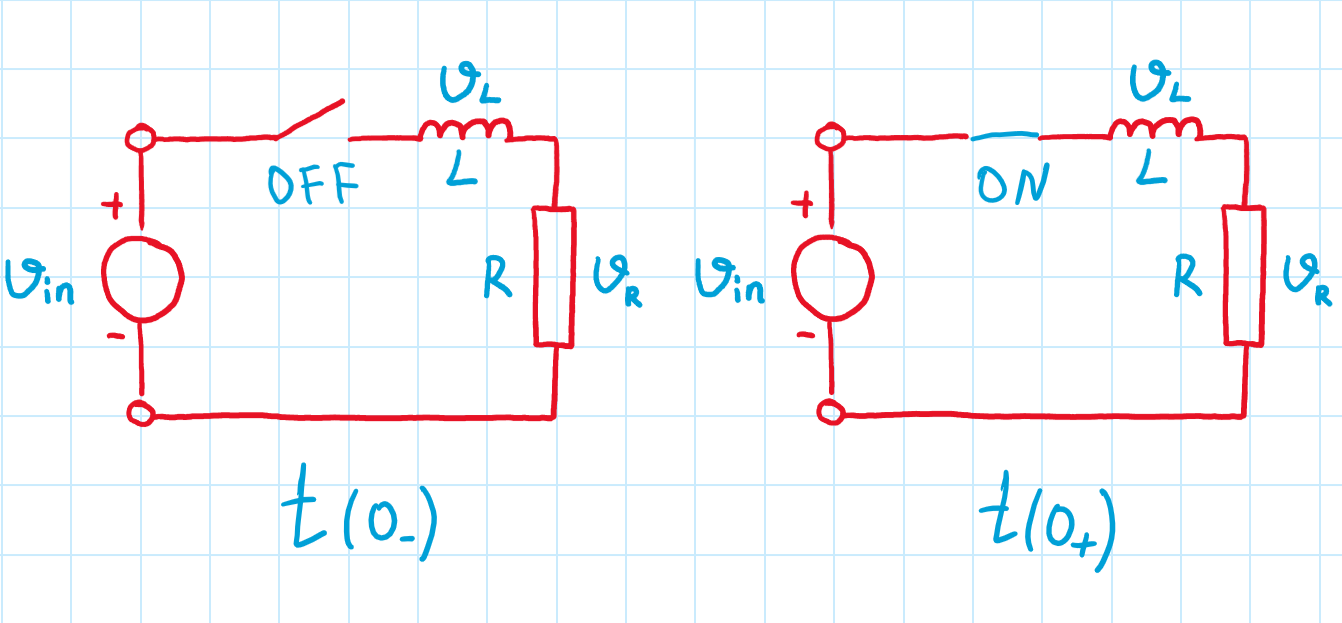

Запишемо рівняння яке описує схему:

$$
  v_{in} = i R + L \frac{di}{dt}
$$

**Порядком електричного кола** називають порядок диференційного рівняння, яким описується коло після комутації. Зазвичай порядок кола співпадає з кількістю його реактивних елементів, тобто у даному випадку розраховується перехідний процес в колі
першого порядку з конденсатором. Підставивши значення сталої часу, отримаємо шукане диференційне рівняння:

Розв’язок диференційного рівняння складає вільну та вимушену складові і отримуємо

$$
i(t) = i_{вм} + i_{вл}
$$

Де:

$i_{вм}$ - вимушена складова, тобто усталена реакція кола на дію джерела;

$i_{вл}$ - вільна складова, яка описує перехідний процесс;

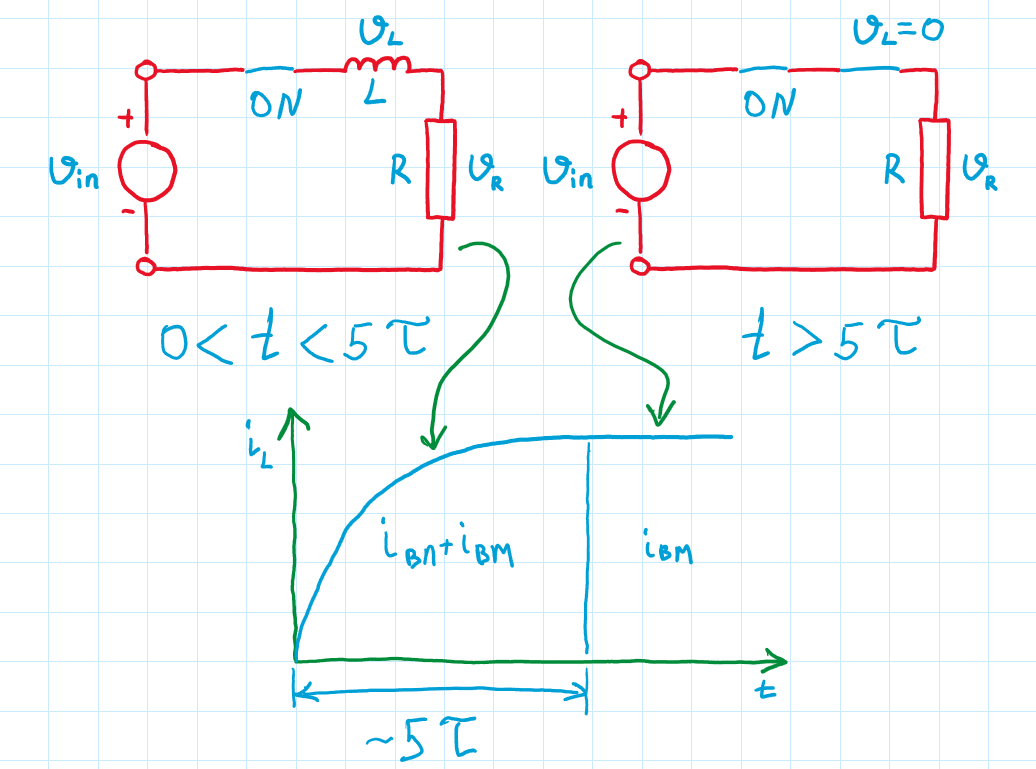

---

Виконаємо розрахунок для наступних параметрів схеми:

$$v_{in} = 80 [V] \quad R=40 [\Omega] \quad L = 0.1 [H] $$

---

Вимушена складова має вигляд

$$i_{вм} = \frac{v_{in}}{Z_{заг}} = \frac{v_{in}}{ R + j \omega L} $$

Оскільки $\omega = 2 \pi f$, а частота постійного джерела напруги нульова:

$$i_{вм} = \frac{v_{in}}{R}  = \frac{80}{40} = 2 А$$

Вільна складова має вигляд:

$$i_{вл} = A e^{pt}$$

$$
  Z(j\omega) = R + j \omega L = 0; \quad j \omega \rightarrow p 
$$

Знайдемо значення p:

$$
  R + p L = 0;  
$$

$$
  p = -\frac{R}{L} = -\frac{40}{0.1} = -400;  
$$

Для знаходження $A$ підставляємо отримані значення до $i(t)$:

$$
i(t) = i_{вм} + i_{вл} = 2 + A e^{-400t}
$$

В момент $t(0+)$, враховуючи перший закон комутації:

$$
i(0+) = i_{вм} + i_{вл} = 2 + A e^{-400 \cdot 0} = 2 + A;
$$

$$
A = -2;
$$

Розв'язок:
$$
i(t) = 2 - 2 e^{-400 \cdot t} [A];
$$


In [2]:
# Інтерактивний перехідний процес RL ланцюга (заряд + розряд)
def rl_transient(R_sb=40, L_sb=0.1, V_sb=10, mode='Заряд (підключення до V)'):
    tau = L_sb / R_sb
    t_max = 5 * tau
    t_vals = np.linspace(0, t_max, 500)
    if mode == 'Заряд (підключення до V)':
        i_vals = (V_sb / R_sb) * (1 - np.exp(-t_vals / tau))
        uL_vals = V_sb * np.exp(-t_vals / tau)
        title_i = 'Заряд: i(t) = (V/R)(1 - e^{-t/tau})'
    else:
        i_vals = (V_sb / R_sb) * np.exp(-t_vals / tau)
        uL_vals = -V_sb * np.exp(-t_vals / tau)
        title_i = 'Розряд: i(t) = (V/R)e^{-t/tau}'

    uR_vals = i_vals * R_sb

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(t_vals*1000, i_vals, '#2196F3')
    axes[0].axvline(tau*1000, color='red', ls='--', label=f'tau={tau*1000:.1f} мс')
    axes[0].axhline(0.632*V_sb/R_sb, color='orange', ls=':', label='0.632 * I_max')
    axes[0].set_xlabel('Час, мс'); axes[0].set_ylabel('Струм, А')
    axes[0].set_title(title_i); axes[0].legend()

    axes[1].plot(t_vals*1000, uR_vals, '#4CAF50', label='u_R(t)')
    axes[1].plot(t_vals*1000, uL_vals, '#FF9800', ls='--', label='u_L(t)')
    axes[1].plot(t_vals*1000, uR_vals + uL_vals, 'k:', label='u_R + u_L = V', lw=1)
    axes[1].set_xlabel('Час, мс'); axes[1].set_ylabel('Напруга, В')
    axes[1].set_title('Напруги на елементах'); axes[1].legend()

    W_L = 0.5 * L_sb * i_vals**2
    axes[2].plot(t_vals*1000, W_L*1000, '#9C27B0')
    axes[2].set_xlabel('Час, мс'); axes[2].set_ylabel('Енергія, мДж')
    axes[2].set_title(f'Енергія W_L(t) = 0.5L*i^2\nW_max = {0.5*L_sb*(V_sb/R_sb)**2*1000:.2f} мДж')

    plt.suptitle(f'RL ланцюг: R={R_sb} Ом, L={L_sb} Гн, V={V_sb} В | tau={tau*1000:.2f} мс',
                 fontsize=11)
    plt.tight_layout(); plt.show()
    print(f'tau = L/R = {tau:.4f} с = {tau*1000:.2f} мс')
    print(f'I_уст = {V_sb/R_sb:.4f} А | W_L_max = {0.5*L_sb*(V_sb/R_sb)**2*1000:.4f} мДж')

interact(rl_transient,
         R_sb=widgets.IntSlider(min=1, max=200, step=5, value=40, description='R (Ом)'),
         L_sb=widgets.FloatSlider(min=0.001, max=1.0, step=0.01, value=0.1, description='L (Гн)'),
         V_sb=widgets.FloatSlider(min=1, max=100, step=1, value=10, description='V (В)'),
         mode=widgets.Dropdown(options=['Заряд (підключення до V)', 'Розряд (відключення)'],
                               description='Режим'))

interactive(children=(IntSlider(value=40, description='R (Ом)', max=200, min=1, step=5), FloatSlider(value=0.1…

<function __main__.rl_transient(R_sb=40, L_sb=0.1, V_sb=10, mode='Заряд (підключення до V)')>

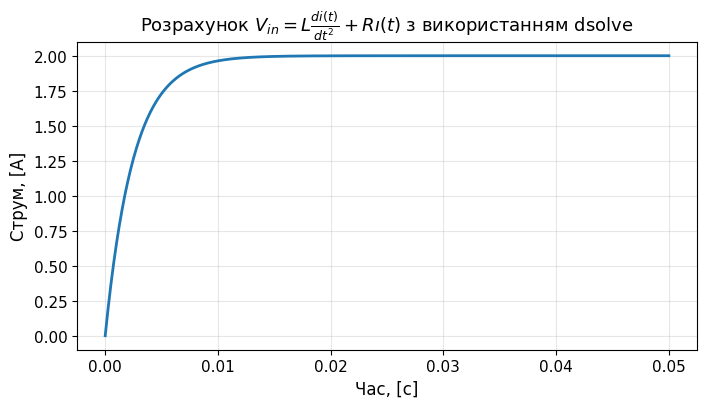

In [3]:
# Step 1: Define circuit parameters and initial conditions
R = 40  # Resistance (in ohms)
L = 0.1  # Inductance (in henrys)
#C = 0.05  # Capacitance (in farads)
V = 80   # Applied DC voltage (in volts)

t = smp.symbols('t')  # Time symbol
I = smp.Function('I')(t)  # Current through the circuit

# Step 2: Set up the differential equation
eq = L * I.diff(t, 1) + R * I - V
# Initial conditions (I(0) = 0, di/dt(0) = 0)
ics = {I.subs(t, 0): 0}

# Step 3: Solve the differential equation
sol = smp.dsolve(eq, I, ics=ics)

# Step 4: Convert symbolic solution to a callable function
I_func = smp.lambdify(t, sol.rhs, 'numpy')

# Step 5: Generate a range of time values
time_values = np.linspace(0, 0.05, 1000)  # Adjust the range as needed

# Step 6: Evaluate I(t) for each time point
current_values = np.array([I_func(ti) for ti in time_values])

# Step 7: Plot the graph
plt.plot(time_values, current_values)
plt.title('Розрахунок $ V_{in} = L\\frac{di(t)}{dt^{2}} + R\\i(t) $ з використанням dsolve')
plt.xlabel('Час, [c]')
plt.ylabel('Струм, [A]')
plt.grid(True)
plt.show()

### 📌 Підсумок: Перехідний процес RL ланцюга

<div style="background-color: #f0fdf4; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Закон комутації для індуктивності (перший закон):**
$$i_L(0_-) = i_L(0_+)$$
Струм через котушку індуктивності не може змінитися стрибком.

**Струм при підключенні RL до джерела напруги $V$:**
$$i(t) = \frac{V}{R}\left(1 - e^{-\frac{R}{L}t}\right) = \frac{V}{R}\left(1 - e^{-t/\tau}\right)$$

**Постійна часу:** $\tau = \dfrac{L}{R}$ (секунди)

**Напруга на індуктивності:** $u_L(t) = V \cdot e^{-t/\tau}$

</div>



---
### ⚡ Практичне застосування: Перехідний процес RL ланцюга

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**RL-ланцюги у радіотехніці:**

| Застосування | tau типове | Пояснення |
|-------------|-----------|----------|
| **Фільтр НЧ (дросель + навантаження)** | 10–100 мкс | Придушення ВЧ-завад у блоках живлення |
| **Котушка реле** | 1–10 мс | Перехідний процес при ввімкненні/вимкненні реле |
| **Розмагнічування трансформатора** | мс | Захист від перенапруг при відключенні |
| **ВЧ-дросель у підсилювачі** | нс–мкс | Ізоляція ВЧ-тракту від кіл живлення |

> **Зворотний ЕРС:** При розмиканні кола з котушкою виникає ЕРС самоіндукції
> $e_L = -L \cdot di/dt$, яка може у десятки разів перевищувати напругу живлення.
> Захист — діод шунтування (flyback diode).

</div>

---
### ✅ Питання для самоперевірки: Перехідний процес RL ланцюга

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Що фізично означає постійна часу tau = L/R?</summary>

> **Відповідь:** Час, за який струм змінюється на 63.2% від кінцевого значення. Це характеристичний час накопичення/розсіювання магнітної енергії в котушці.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому струм через котушку не може змінитися стрибком?</summary>

> **Відповідь:** Миттєва зміна струму $\Delta i$ потребувала б нескінченно великої напруги $u_L = L \cdot di/dt \to \infty$, що неможливо для реального джерела з кінцевою потужністю.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> За скільки постійних часу перехідний процес вважається завершеним і чому?</summary>

> **Відповідь:** Практично за $5\tau$: $e^{-5} \approx 0.0067$, тобто залишок відхилення — менш ніж 1% від кінцевого значення.

</details>

---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Не переплутайте формули постійної часу! Для **RL** кола (щойно розглянутого вище): $\tau = L/R$. Для **RC** кола, яке починається нижче: $\tau = R \cdot C$. Легко перевірити розмірністю: $[L/R] = \text{Гн}/\text{Ом} = \text{с}$, $[RC] = \text{Ом}\cdot\text{Ф} = \text{с}$ — обидві дають секунди, тому формули не можна впізнати «на око», якщо не пам'ятати, яка з них до якого кола відноситься.


</div>


---
---

## Розрахунок перехідного процесу RC ланцюга  <a class="anchor" id="RC-comutation-calculation-classic"></a>

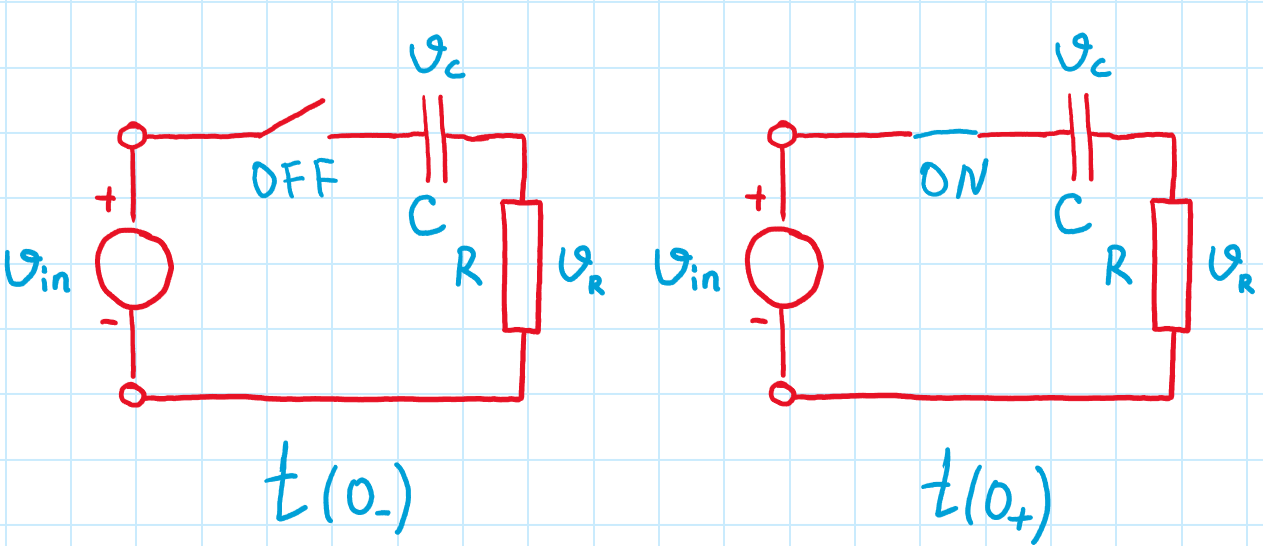

Запишемо рівняння яке описує схему:

$$
  v_{in}(t) = v_{c}(t) + R C \frac{d u_{C}(t)}{dt};
$$

Розв’язок диференційного рівняння складає вільну та вимушену складові і отримуємо

$$
v_{c}(t) = v_{вм}(t) + v_{вл}(t)
$$

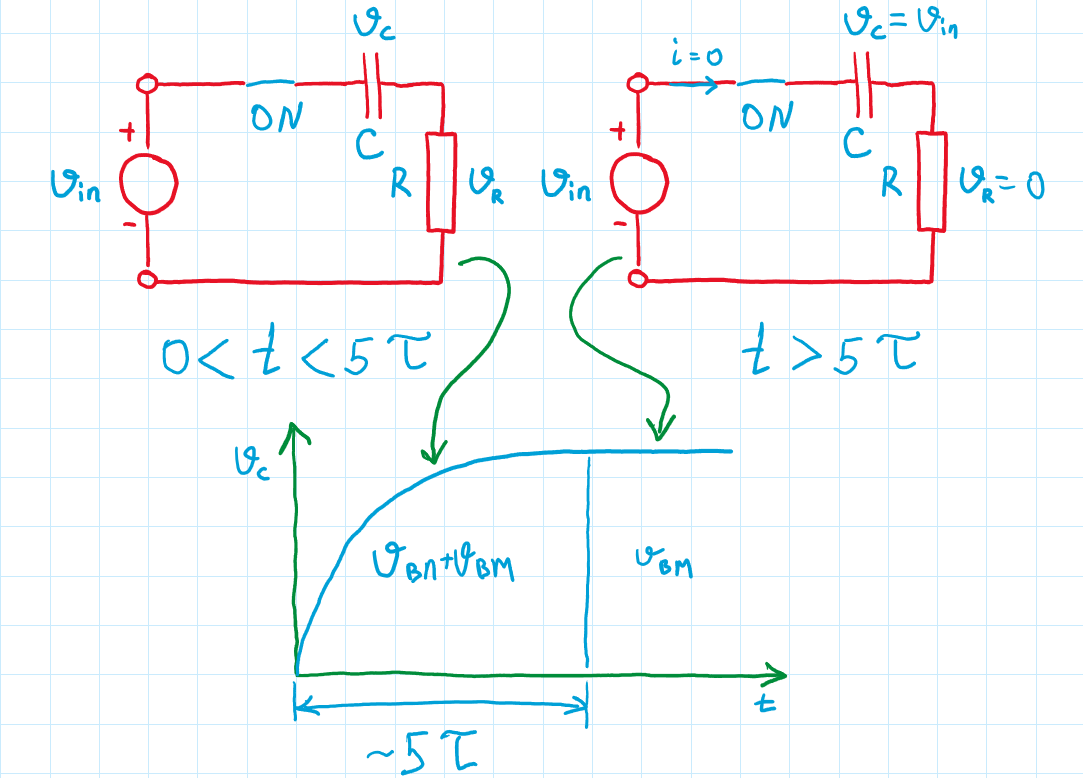

---

Виконаємо розрахунок для наступних параметрів схеми:

$$v_{in} = 80 [V] \quad R=40 [\Omega] \quad C = 0.1 [mF] $$

---

Вимушена складова має вигляд

Оскільки $\omega = 2 \pi f$, а частота постійного джерела напруги нульова:

$$v_{вм}(t) = v_{in}(t) = 80 V$$

Конденсатор зарядиться до напруги живлення. В цей момент відповідно струм буде 0 і падіння напруги на резисторі також буди 0.

Вільна складова має вигляд:

$$v_{вл}(t) = A e^{pt}$$

Запишемо характеристичне рівняння:

$$
  Z(j \omega) = R + \cfrac{1}{j \omega C};
$$

Виконаємо заміну на p і приведемо до загального знаменника:

$$
  Z(p) = R + \cfrac{1}{pC} = \cfrac{RpC+1}{pC};
$$

Прирівняємо праву частину до 0:

$$
  \cfrac{RpC+1}{pC} = 0;
$$

Дріб буде нульовий коли чисельник буде рівним нулю, тоді:

$$
  RpC+1 = 0;
$$

Тоді р:

$$
  p = \cfrac{-1}{RC} = -\frac{1}{4*10^{-3}} = -250;
$$

Для знаходження $A$ підставляємо отримані значення до $v_{c}(t)$:

$$
v_{c}(t) = v_{вм}(t) + v_{вл}(t) = 80V + A e^{-250}
$$

В момент $t(0+)$, враховуючи перший закон комутації:

$$
v_{c}(0+) = v_{вм}(t) + v_{вл}(t) = 80V + A e^{-250 \cdot 0} = 40 + A;
$$

$$
A = -80;
$$

Розв'язок:
$$
v_{c}(t) = 80 - 80 e^{-250 \cdot t} [V];
$$
    

In [4]:
# Інтерактивний перехідний процес RC ланцюга
def rc_transient(R_sb=40, C_sb=1.0, V_sb=10, mode='Заряд (підключення до V)'):
    C_F = C_sb * 1e-3  # мФ -> Ф
    tau = R_sb * C_F
    t_max = 5 * tau
    t_vals = np.linspace(0, t_max, 500)
    if mode == 'Заряд (підключення до V)':
        uC_vals = V_sb * (1 - np.exp(-t_vals / tau))
        i_vals = (V_sb / R_sb) * np.exp(-t_vals / tau)
        title = 'Заряд: u_C(t) = V(1 - e^{-t/tau})'
    else:
        uC_vals = V_sb * np.exp(-t_vals / tau)
        i_vals = -(V_sb / R_sb) * np.exp(-t_vals / tau)
        title = 'Розряд: u_C(t) = V * e^{-t/tau}'

    uR_vals = i_vals * R_sb
    W_C = 0.5 * C_F * uC_vals**2

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(t_vals*1000, uC_vals, '#2196F3', label='u_C(t)')
    axes[0].axvline(tau*1000, color='red', ls='--', label=f'tau={tau*1000:.1f} мс')
    axes[0].axhline(0.632*V_sb, color='orange', ls=':', label='0.632 V')
    axes[0].set_xlabel('Час, мс'); axes[0].set_ylabel('Напруга, В')
    axes[0].set_title(title); axes[0].legend()

    axes[1].plot(t_vals*1000, i_vals*1000, '#4CAF50')
    axes[1].set_xlabel('Час, мс'); axes[1].set_ylabel('Струм, мА')
    axes[1].set_title('Струм i(t) = (V/R)e^{-t/tau}')

    axes[2].plot(t_vals*1000, W_C*1e6, '#FF9800')
    axes[2].set_xlabel('Час, мс'); axes[2].set_ylabel('Енергія, мкДж')
    axes[2].set_title(f'Енергія W_C = 0.5C*u_C^2\nW_max = {0.5*C_F*V_sb**2*1e6:.2f} мкДж')

    plt.suptitle(f'RC ланцюг: R={R_sb} Ом, C={C_sb} мФ, V={V_sb} В | tau={tau*1000:.2f} мс',
                 fontsize=11)
    plt.tight_layout(); plt.show()
    print(f'tau = RC = {tau:.4f} с = {tau*1000:.2f} мс')
    print(f'U_C_уст = {V_sb:.2f} В | W_C_max = {0.5*C_F*V_sb**2*1e6:.4f} мкДж')

interact(rc_transient,
         R_sb=widgets.IntSlider(min=10, max=1000, step=10, value=40, description='R (Ом)'),
         C_sb=widgets.FloatSlider(min=0.01, max=10, step=0.1, value=1.0, description='C (мФ)'),
         V_sb=widgets.FloatSlider(min=1, max=100, step=1, value=10, description='V (В)'),
         mode=widgets.Dropdown(options=['Заряд (підключення до V)', 'Розряд (відключення)'],
                               description='Режим'))

interactive(children=(IntSlider(value=40, description='R (Ом)', max=1000, min=10, step=10), FloatSlider(value=…

<function __main__.rc_transient(R_sb=40, C_sb=1.0, V_sb=10, mode='Заряд (підключення до V)')>

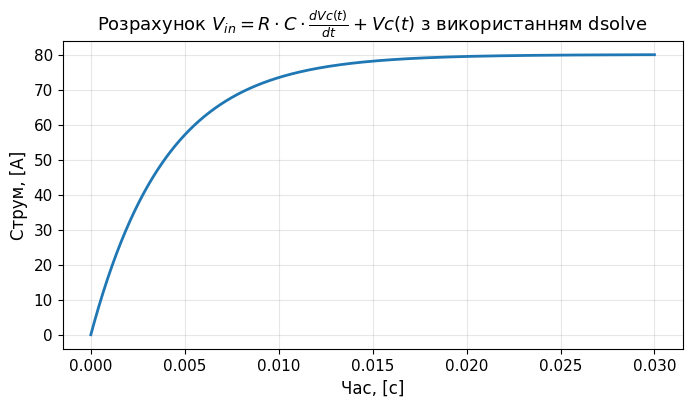

In [5]:
# Step 1: Define circuit parameters and initial conditions
R = 40  # Resistance (in ohms)
#L = 0.1  # Inductance (in henrys)
C = 0.1*1e-3  # Capacitance (in farads)
V = 80   # Applied DC voltage (in volts)

t = smp.symbols('t')  # Time symbol
Vc = smp.Function('Vc')(t)  # Current through the circuit


# Step 2: Set up the differential equation
eq = R * C * Vc.diff(t) + Vc - V
# Initial conditions (I(0) = 0, di/dt(0) = 0)
ics = {Vc.subs(t, 0): 0}

# Step 3: Solve the differential equation
sol = smp.dsolve(eq, Vc, ics=ics)

# Step 4: Convert symbolic solution to a callable function
Vc_func = smp.lambdify(t, sol.rhs, 'numpy')

# Step 5: Generate a range of time values
time_values = np.linspace(0, 0.03, 1000)  # Adjust the range as needed

# Step 6: Evaluate I(t) for each time point
current_values = np.array([Vc_func(ti) for ti in time_values])

# Step 7: Plot the graph
plt.plot(time_values, current_values)
plt.title(r'Розрахунок $ V_{in} =  R\cdot C \cdot\frac{dVc(t)}{dt} + Vc(t) $ з використанням dsolve')
plt.xlabel('Час, [c]')
plt.ylabel('Струм, [A]')
plt.grid(True)
plt.show()

### 📌 Підсумок: Перехідний процес RC ланцюга

<div style="background-color: #f0fdf4; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Закон комутації для ємності (другий закон):**
$$u_C(0_-) = u_C(0_+)$$
Напруга на конденсаторі не може змінитися стрибком.

**Напруга при заряді RC ланцюга від джерела $V$:**
$$u_C(t) = V\left(1 - e^{-\frac{t}{RC}}\right) = V\left(1 - e^{-t/\tau}\right)$$

**Постійна часу:** $\tau = R \cdot C$ (секунди)

**Струм у ланцюзі:** $i(t) = \dfrac{V}{R} e^{-t/\tau}$

</div>

---


---
### ⚡ Практичне застосування: Перехідний процес RC ланцюга

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**RC-ланцюги у радіотехніці:**

| Застосування | tau типове | Пояснення |
|-------------|-----------|----------|
| **Фільтр НЧ (інтегруюче коло)** | залежно від смуги | Згладжування пульсацій, детектор АМ |
| **Диференціюче коло** | << T сигналу | Виділення фронтів прямокутного імпульсу |
| **Тайм-схема (555 таймер)** | мкс–хвилини | RC визначає час спрацювання |
| **Схема сполучення каскадів** | RC >> 1/f_min | Блокування DC, пропускання AC |
| **АЦП Sample-and-Hold** | нс | Час вибірки аналогового сигналу |

> **Частота зрізу:** $f_c = \frac{1}{2\pi RC} = \frac{1}{2\pi \tau}$.
> При $f = f_c$ рівень АЧХ = $-3$ дБ (у $\sqrt{2}$ разів менший за максимальний).

</div>

---
### ✅ Питання для самоперевірки: Перехідний процес RC ланцюга

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому напруга на конденсаторі не може змінитися стрибком?</summary>

> **Відповідь:** Миттєва зміна $\Delta U_C$ потребувала б нескінченно великого струму $i = C \cdot dU_C/dt \to \infty$, що неможливо для реального кола з кінцевим опором.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чим відрізняється інтегруюче коло від диференціюючого?</summary>

> **Відповідь:** Інтегруюче RC ($\tau \gg T$): вихідний сигнал — з ємності, форма наближена до інтеграла вхідного. Диференціюче RC ($\tau \ll T$): вихідний сигнал — з резистора, форма наближена до похідної вхідного.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Яка енергія накопичується в конденсаторі при зарядці до напруги V?</summary>

> **Відповідь:** $W_C = \frac{1}{2}CV^2$. При цьому рівно така ж енергія розсіюється на резисторі $R$, незалежно від його величини. Тобто ККД заряду ємності від джерела напруги через резистор — 50%.

</details>

---

## Вмикання кіл на синусоїдальну напругу <a class="anchor" id="ac-switching"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Записувати вимушену складову перехідного процесу при синусоїдному джерелі
> - Пояснювати, чому вигляд вільної складової (τ, характеристичне рівняння) не залежить від типу джерела
> - Визначати, за якої фази включення транзиторний струм максимальний, а за якої — відсутній

</div>

### RL-коло, яке вмикається на синусоїдну напругу

Нехай до кола $R,L$ (спочатку знеструмленого, $i(0_-)=0$) у момент $t=0$ підключають джерело $v_{in}(t)=V_m\sin(\omega t+\psi)$, де $\psi$ — **фаза включення** (значення фази синусоїди саме в момент комутації).

Диференціальне рівняння кола таке саме, як і для постійної напруги — джерело живлення входить лише через праву частину:

$$L\frac{di}{dt}+Ri = V_m\sin(\omega t+\psi)$$

**Вільна складова** визначається тим самим характеристичним рівнянням $R+pL=0$, що й при вмиканні на постійну напругу (воно залежить лише від топології кола, а не від джерела):

$$i_{вл}(t) = A\,e^{-t/\tau}, \qquad \tau=\frac{L}{R}$$

**Вимушена складова** — це усталений синусоїдний режим, який шукають символічним методом:

$$i_{вим}(t) = I_m\sin(\omega t+\psi-\varphi), \qquad I_m=\frac{V_m}{\sqrt{R^2+(\omega L)^2}}, \qquad \varphi=\operatorname{arctg}\frac{\omega L}{R}$$

**Стала інтегрування** знаходиться з початкової умови $i(0_+)=i(0_-)=0$:

$$0 = I_m\sin(\psi-\varphi) + A \quad\Longrightarrow\quad A=-I_m\sin(\psi-\varphi)$$

$$\boxed{i(t) = I_m\sin(\omega t+\psi-\varphi) - I_m\sin(\psi-\varphi)\,e^{-t/\tau}}$$

### Вплив фази включення

- Якщо **$\psi-\varphi=0$ або $\pi$** («включення у фазі»), то $\sin(\psi-\varphi)=0$, стала $A=0$ — вільна складова відсутня, і коло одразу переходить в усталений синусоїдний режим без перехідного процесу.
- Якщо **$\psi-\varphi=\pm\pi/2$** («включення в квадратурі»), $\sin(\psi-\varphi)=\pm1$ — стала максимальна за модулем, $A=\mp I_m$, і струм у перший момент після комутації може сягати майже подвоєної амплітуди усталеного струму $I_m$ — це **найгірший (найбільш небезпечний) випадок включення**, який враховують при виборі комутаційної апаратури (вимикачів, запобіжників) для потужних індуктивних навантажень (трансформатори, електродвигуни).


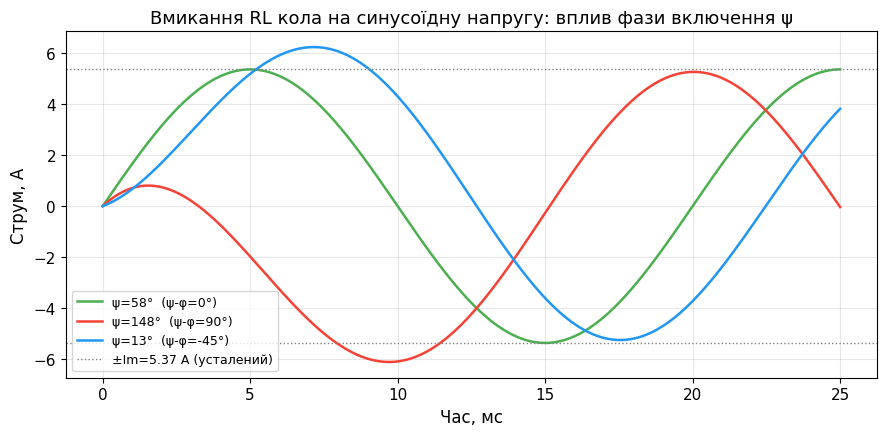

tau = 5.00 мс, Im = 5.370 А, φ = 57.5°
При ψ-φ=0 перехідного процесу немає; при ψ-φ=±90° кидок струму максимальний (до ~2·Im).


In [6]:
# Вплив фази включення на кидок струму при вмиканні RL кола на синусоїдну напругу
R_ac, L_ac, Vm_ac, f_ac = 10.0, 0.05, 100.0, 50.0
w_ac = 2*np.pi*f_ac
tau_ac = L_ac / R_ac
Im_ac = Vm_ac / np.sqrt(R_ac**2 + (w_ac*L_ac)**2)
phi_ac = np.arctan2(w_ac*L_ac, R_ac)

t_ac = np.linspace(0, 5*tau_ac, 2000)

fig, ax = plt.subplots(figsize=(9, 4.5))
for psi_deg, color in [(np.degrees(phi_ac), '#4CAF50'), (np.degrees(phi_ac)+90, '#F44336'), (np.degrees(phi_ac)-45, '#2196F3')]:
    psi = np.radians(psi_deg)
    i_t = Im_ac*np.sin(w_ac*t_ac+psi-phi_ac) - Im_ac*np.sin(psi-phi_ac)*np.exp(-t_ac/tau_ac)
    ax.plot(t_ac*1e3, i_t, color=color, lw=1.8, label=f'ψ={psi_deg:.0f}°  (ψ-φ={psi_deg-np.degrees(phi_ac):.0f}°)')

ax.axhline(Im_ac, color='gray', ls=':', lw=1)
ax.axhline(-Im_ac, color='gray', ls=':', lw=1, label=f'±Im={Im_ac:.2f} А (усталений)')
ax.set_xlabel('Час, мс'); ax.set_ylabel('Струм, А')
ax.set_title('Вмикання RL кола на синусоїдну напругу: вплив фази включення ψ')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f'tau = {tau_ac*1000:.2f} мс, Im = {Im_ac:.3f} А, φ = {np.degrees(phi_ac):.1f}°')
print('При ψ-φ=0 перехідного процесу немає; при ψ-φ=±90° кидок струму максимальний (до ~2·Im).')


---
### ⚡ Практичне застосування: Вмикання на синусоїдну напругу

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

- **Пусковий кидок струму трансформатора (inrush current)** — якщо трансформатор вмикають у мережу саме в момент, близький до найгіршої фази ($\psi-\varphi\approx\pm90°$), намагнічувальний струм може у кілька разів перевищувати номінальний, що враховують при виборі запобіжників і автоматів.
- **М'який пуск (soft-start) потужних електродвигунів** — керовані тиристорні пускачі свідомо підбирають момент включення (кут керування), щоб уникнути «найгіршої фази» і зменшити пусковий струм.
- **Комутаційні перенапруги в енергетиці** — аналогічний ефект для RLC-кіл (лінії, компенсаційні конденсаторні батареї) враховують при проєктуванні вимикачів високої напруги.

</div>

---
### ✅ Питання для самоперевірки: Вмикання на синусоїдну напругу

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому стала часу τ=L/R однакова, чи вмикається коло на постійну, чи на синусоїдну напругу?</summary>

> **Відповідь:** Стала часу визначається коренем характеристичного рівняння $R+pL=0$, яке залежить лише від параметрів самого кола (R, L) і не залежить від виду джерела — форма вільної складової $e^{-t/\tau}$ та сама, змінюється лише спосіб знаходження сталої A через вимушену складову.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> За якої умови включення RL кола на синусоїдну напругу перехідний процес не виникає взагалі?</summary>

> **Відповідь:** Коли фаза включення співпадає з фазою вимушеної складової в момент комутації ($\psi-\varphi=0$ або $\pi$), тобто $i_{вим}(0_+)=i(0_-)=0$ автоматично — стала A=0 і коло одразу в усталеному режимі.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому найбільший кидок струму небезпечний саме для індуктивних навантажень (трансформаторів, двигунів)?</summary>

> **Відповідь:** У найгіршому випадку ($\psi-\varphi=\pm90°$) миттєвий струм може досягати майже подвоєної амплітуди усталеного режиму — для потужних індуктивних навантажень це означає значний струмовий кидок, здатний спрацювати захист або пошкодити обмотки, тому це явище обов'язково враховують при проєктуванні пускової апаратури.

</details>

### 🎯 Мета вивчення розділу: Операторний метод

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати сутність перетворення Лапласа
> - Застосовувати таблицю перетворень Лапласа
> - Записувати закони Кірхгофа в операторній формі
> - Розраховувати перехідні процеси операторним методом
> - Застосовувати формулу розкладу для знаходження оригіналів

</div>

### Перетворення Лапласа: основні пари

| Оригінал $f(t)$ | Зображення $F(p)$ | Назва |
|----------------|-----------------|-------|
| $1$ | $\dfrac{1}{p}$ | Одиничний стрибок |
| $t$ | $\dfrac{1}{p^2}$ | Лінійна функція |
| $e^{-at}$ | $\dfrac{1}{p+a}$ | Експонента |
| $\sin(\omega t)$ | $\dfrac{\omega}{p^2+\omega^2}$ | Синус |
| $\cos(\omega t)$ | $\dfrac{p}{p^2+\omega^2}$ | Косинус |
| $\delta(t)$ | $1$ | Дельта-функція |



### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Операторне числення розробив у 1880-х **Олівер Хевісайд** — інженер-самоучка, який також вивів **телеграфне рівняння** (розділ «Довга лінія» далі в цьому конспекті) та ввів позначення $j=\sqrt{-1}$ для розрахунків кіл змінного струму. Математики того часу критикували його метод за відсутність строгого обґрунтування — воно з'явилося лише через десятиліття, коли Т. Бромвіч показав його зв'язок саме з перетворенням Лапласа.


</div>


### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Не плутайте оператор Лапласа $p = \sigma + j\omega$ із символічним методом $j\omega$ із Частини 1. Символічний метод — окремий випадок операторного при $\sigma = 0$ (чисто усталений синусоїдний режим). Оператор $p$ загальніший: дійсна частина $\sigma$ описує загасання/наростання перехідного процесу, а уявна $j\omega$ — коливальну складову. Щоб перейти від $H(p)$ до частотної характеристики $H(j\omega)$, достатньо підставити $p \to j\omega$ — але це коректно лише для **стійкого** кола в **усталеному** режимі.


</div>


## Операторний метод розрахунку перехідних процесів  <a class="anchor" id="Comutation-calculation-laplace"></a>

Сутність **операторного методу** полягає в тому, що функції $f(x)$ дійсної змінної t, яку називають **оригіналом**, ставиться у відповідність функція $F(p)$ комплексної змінної $p = s + j \omega$, яку називають **зображенням**. В результаті цього похідні та інтеграли від оригіналів замінюються алгебраїчними функціями від відповідних зображень (диференціювання замінюється множенням на оператор р, а інтегрування - діленням на нього), що в свою чергу визначає перехід від системи **інтегро-диференціальних рівнянь до системи алгебраїчних рівнянь** щодо зображень шуканих змінних . При вирішенні цих рівнянь знаходяться зображення і далі шляхом зворотного переходу - оригінали. Найважливішим моментом при цьому в практичному плані є необхідність визначення тільки незалежних початкових умов, що істотно полегшує розрахунок перехідних процесів в ланцюгах високого порядку в порівнянні з класичним методом.

Зображення заданої функції визначається відповідно з прямим перетворенням Лапласа:

$$
F(p) = \int_{0}^{\infty}e^{-pt}f(t)dt;
$$

У скороченою записи відповідність між зображенням і оригіналом позначається, як:

$$
F(p) = f(t) \quad   або \quad  F(p) = L\{f(t)\};
$$

Слід зазначити, що якщо оригінал збільшується з ростом t, то для збіжності інтеграла (1) необхідно більш швидке спадання модуля  . Функції, з якими зустрічаються на практиці при розрахунку перехідних процесів, цій умові задовольняють. В якості прикладу в табл. 1 наведено зображення деяких характерних функцій, що часто зустрічаються при аналізі нестаціонарних режимів.

---
---
## Закони Кірхгофа в операторній формі  <a class="anchor" id="Laplace-laws"></a>

**Перший закон Кірхгофа**: алгебраїчна сума зображень струмів, що сходяться у вузлі, дорівнює нулю

$$
\sum_{k=1}^{n} I_{k}(p) = 0;
$$

**Другий закон Кірхгофа**: алгебраїчна сума зображень ЕРС, що діють в контурі, дорівнює алгебраїчній сумі зображень напруг на пасивних елементах цього контуру

$$
\sum_{k=1}^{m} E_{k}(p) = \sum_{k=1}^{m} v_{k}(p);
$$

## Властивості перетворення Лапласа  <a class="anchor" id="Laplace-properties"></a>

Лінійність:

$$
a_{1}f_{1}(t)+a_{2}f_{2}(t)+... \rightarrow a_{1}F_{1}(p)+a_{2}F_{2}(p)+...;
$$

Теорема інтегрування:

$$
x(t) = \int_{0}^{t}f(t)dt+x(0) \rightarrow \frac{1}{p}F(p)+\frac{1}{p}x(0);
$$

Теорема диференціювання:

$$
\frac{d}{dt}f(t) \rightarrow pF(p) - f(0_{+});
$$

$$
\frac{d^{2}}{dt^{2}}f(t) \rightarrow p^{2}F(p) - pf(0_{+}) - \frac{d}{dt}f(0_{+});
$$

$$
\frac{d^{n}}{dt^{n}}f(t) \rightarrow p^{n}F(p) - p^{n-1}f(0_{+}) - p^{n-2}\frac{d}{dt}f(0_{+})-...p\frac{d^{n-2}}{dt^{n-2}}f(0_{+}) - \frac{d^{n-1}}{dt^{n-1}}f(0_{+});
$$

Теорема запізнювання:

$$
f(t-t_{0}) \rightarrow F(p)e^{-pt};
$$


---
### Таблиця перетворень Лапласа (основні пари)

| Оригінал $f(t)$, $t \geq 0$ | Зображення $F(p)$ | Примітка |
|------------------------------|------------------|----------|
| $\delta(t)$ — дельта-функція | $1$ | Імпульсна характеристика |
| $\mathbf{1}(t)$ — одиничний стрибок | $\dfrac{1}{p}$ | Ступінчате збудження |
| $e^{-at}$ | $\dfrac{1}{p+a}$ | Експоненційний спад |
| $t \cdot e^{-at}$ | $\dfrac{1}{(p+a)^2}$ | Критичний випадок RL/RC |
| $\sin(\omega t)$ | $\dfrac{\omega}{p^2+\omega^2}$ | Синусоїдне збудження |
| $\cos(\omega t)$ | $\dfrac{p}{p^2+\omega^2}$ | Косинусоїдне збудження |
| $e^{-at}\sin(\omega t)$ | $\dfrac{\omega}{(p+a)^2+\omega^2}$ | Затухаючі коливання |
| $e^{-at}\cos(\omega t)$ | $\dfrac{p+a}{(p+a)^2+\omega^2}$ | Затухаючі коливання |

**Теореми:**

| Теорема | Формула |
|---------|--------|
| Диференціювання | $\mathcal{L}\{f'(t)\} = p \cdot F(p) - f(0_+)$ |
| Інтегрування | $\mathcal{L}\left\{\int_0^t f\,d\tau\right\} = \dfrac{F(p)}{p}$ |
| Запізнення | $\mathcal{L}\{f(t-\tau)\} = e^{-p\tau} F(p)$ |
| Початкове значення | $f(0_+) = \lim_{p\to\infty} p F(p)$ |
| Кінцеве значення | $f(\infty) = \lim_{p\to 0} p F(p)$ |

### Правила переходу від оригіналу до зображення  <a class="anchor" id="Laplace-transform-law"></a>

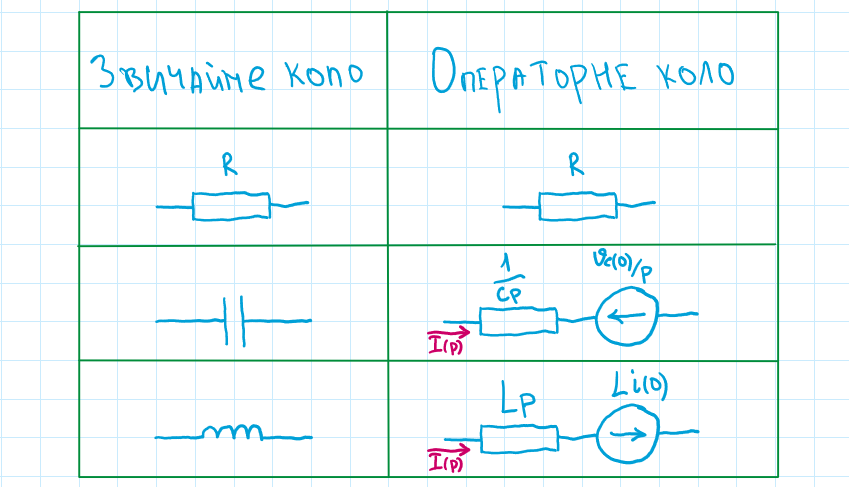

---
---

## Розрахунок перехідного процесу RC ланцюга операторним методом  <a class="anchor" id="RC-comutation-calculation-laplace"></a>

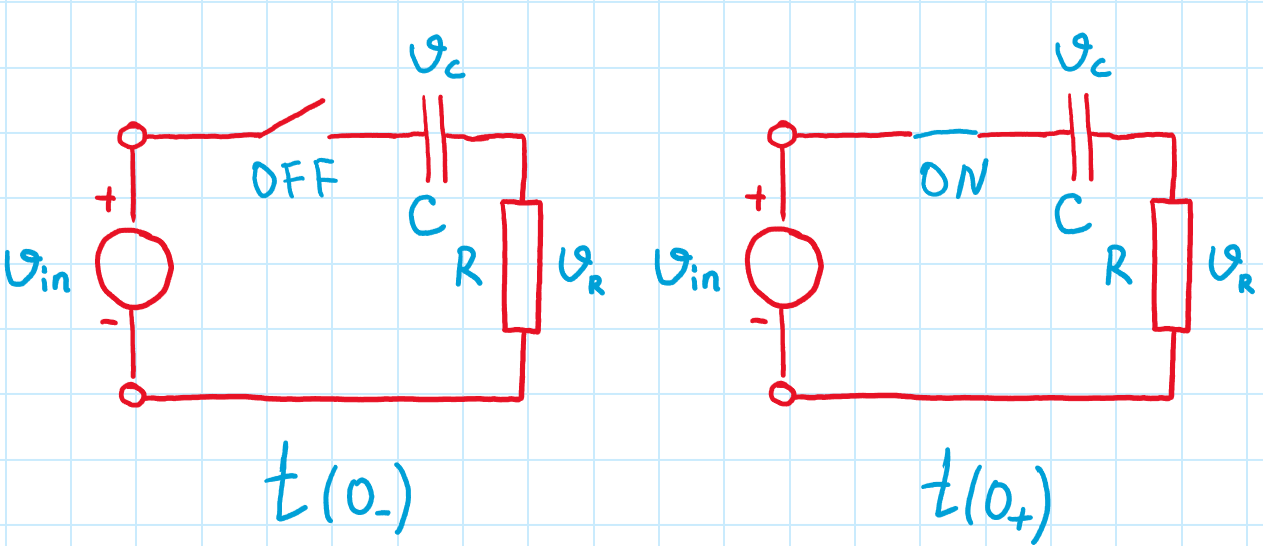

---

Виконаємо розрахунок для наступних параметрів схеми:

$$v_{in} = 80 [V] \quad R=40 [\Omega] \quad C = 0.1 [mF] $$

---

Запишемо операторну схему заміщення

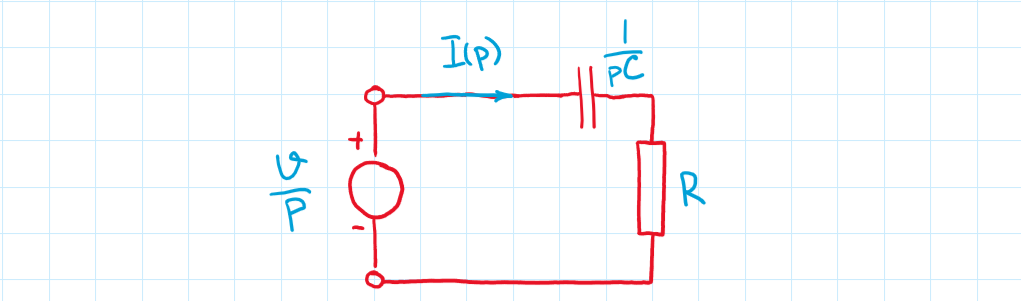

Запишемо рівняння:

$$
  Z(p) = R + \cfrac{1}{pC};
$$

Приведемо до загального знаменника:

$$
  Z(p) = \cfrac{RpC+1}{pC};
$$

Визначимо струм в контурі поділивши вхідну напругу на повний опір схеми:

$$
  I(p) = (\cfrac{v_{in}}{p}) / (\cfrac{RpC+1}{pC}) = (\cfrac{v_{in}}{p}) \cdot (\cfrac{pC}{RpC+1});
$$

Скоротимo p:

$$
  I(p) =  \cfrac{v_{in}C}{RpC+1};
$$

Визначимо напругу на резисторі $R$:

$$
  v_{r}(p) = R \cdot I(p) =  R \cdot \cfrac{v_{in}C}{RpC+1};
$$

Запишемо рівняння по 2-му закону Кірхгофа:

$$
  v_{r}(p) + v_{с}(p) = \cfrac{v_{in}}{p};
$$

Тоді:

$$
   v_{с}(p) = \cfrac{v_{in}}{p} - v_{r}(p) = \cfrac{v_{in}}{p} - R \cdot \cfrac{v_{in}C}{RpC+1};
$$

Приведемо до загального знаменника:

$$
   v_{с}(p) = \cfrac{
   v_{in}(RpC+1) - pv_{in}RC
   }
   {
   p(RpC+1)
   }  
$$

Розкриємо дужки і отримаємо фінальне зображення напруги на конденсаторі $v_{с}(p)$:

$$
   v_{с}(p) = 
   \cfrac{
   v_{in}RCp+v_{in}- pv_{in}RC
   }
   {
   p(RpC+1)
   }
   =
   \cfrac{
   v_{in}
   }
   {
   p(RpC+1)
   }
   =
   \cfrac{
   F_{1}(p)
   }
   {
   F_{2}(p)
   }
$$

Для перевірки знайдемо корені знаменника і порівняємо з класичним методом:

$$
   p(RpC+1) = 0
$$

Перший корінь

$$
   p_{0} = 0
$$

Другий корінь

$$
   RpC+1 = 0
$$

Тоді $р_{1}$:

$$
  p_{1} = \cfrac{-1}{RC} = -\frac{1}{4*10^{-3}} = -250;
$$

$$
  F_{1}(p) = v_{in} = 80;\\
  F_{1}(p_{0}) = 80;\\
  F_{1}(p_{1}) = 80;
$$

$$
  F^{'}_{2}(p) =  p^2RC+p;
$$

Візьмемо похідну і підставимо отримані корені:

$$
  F_{2}(p) =  2pRC+1;
$$

$$
  F^{'}_{2}(p_{0}) = F^{'}_{2}(0) =1;
$$

$$
  F^{'}_{2}(p_{1}) = 2 \cdot -250 \cdot 40 \cdot (0.1) \cdot 10^{-3} + 1 = -1;
$$

Запишемо формулу переходу в часовій області:

$$
  v_{c}(t) = 
  \cfrac{F_{1}(p_{0})}{F^{'}_{2}(p_{0})} \cdot e^{p_{0}t} +
  \cfrac{F_{1}(p_{1})}{F^{'}_{2}(p_{1})} \cdot  e^{p_{1}t};
$$

$$
  v_{c}(t) = \cfrac{80}{1} + \cfrac{80}{-1} \cdot  e^{-250\cdot t};
$$

Розв'язок:
$$
v_{c}(t) = 80 - 80 e^{-250 \cdot t} [V];
$$

---
## 📐 Формула розкладу і її застосування при розрахунку перехідних процесів

Ці формули дозволяють знайти оригінал $f(t)$, якщо зображення задано дробово-раціональною функцією:

$$
F(p) = \frac{F_1(p)}{F_2(p)} = \frac{a_m p^m + a_{m-1}p^{m-1} + \ldots + a_1 p + a_0}{b_n p^n + b_{n-1}p^{n-1} + \ldots + b_1 p + b_0}
$$

Формулу розкладання можна застосовувати тільки тоді, коли степінь чисельника нижчий за степінь знаменника ($m < n$). Якщо це не так, спочатку ділять чисельник на знаменник, виділяючи цілу частину, і застосовують формулу розкладання лише до правильного дробового залишку.

Характеристичне рівняння $F_2(p) = 0$ визначає корені $p_k$, кожному з яких відповідає доданок в оригіналі:

**1. Простий дійсний корінь $p_k$:**
$$
f_k(t) = \frac{F_1(p_k)}{F_2'(p_k)} \, e^{p_k t}
$$

**2. Пара простих комплексно-спряжених коренів $p_{1,2} = -\sigma \pm j\omega$:**

Обчисливши лишок при корені з додатною уявною частиною $p_1$: $\dfrac{F_1(p_1)}{F_2'(p_1)} = M e^{j\psi}$ (у показниковій формі), сума доданків від обох спряжених коренів дає **дійсну** функцію:
$$
f_{1,2}(t) = 2M\, e^{-\sigma t}\cos(\omega t + \psi)
$$

**3. Кратний корінь $p_k$ кратності 2** (тобто $F_2(p) = (p-p_k)^2 \tilde{F}_2(p)$):
$$
f_k(t) = \left(\frac{F_1(p_k)}{\tilde{F}_2(p_k)}\, t + \left[\frac{F_1(p)}{\tilde{F}_2(p)}\right]'_{p=p_k}\right) e^{p_k t}
$$
Найпростіший практичний приклад кратного кореня — **критичний режим** RLC ланцюга (розділ «Перехідні процеси 2-го порядку» нижче), де $p_{1,2} = -\alpha$ і розв'язок містить доданок вигляду $(A + Bt)e^{-\alpha t}$.

### Приклад застосування формули розкладання

Нехай зображення струму має вигляд:
$$
I(p) = \frac{24}{p(p+2)(p+4)}
$$

Тут $F_1(p) = 24$, $F_2(p) = p(p+2)(p+4) = p^3 + 6p^2 + 8p$, звідки $F_2'(p) = 3p^2 + 12p + 8$. Характеристичне рівняння $F_2(p)=0$ дає три прості дійсні корені: $p_0 = 0$, $p_1 = -2$, $p_2 = -4$.

Обчислюємо $F_2'(p)$ у кожному корені:
$$
F_2'(0) = 8, \qquad F_2'(-2) = 12-24+8 = -4, \qquad F_2'(-4) = 48-48+8 = 8
$$

За формулою розкладання (випадок 1) для кожного кореня:
$$
i(t) = \frac{F_1(0)}{F_2'(0)} + \frac{F_1(-2)}{F_2'(-2)}e^{-2t} + \frac{F_1(-4)}{F_2'(-4)}e^{-4t}
     = \frac{24}{8} - \frac{24}{4}e^{-2t} + \frac{24}{8}e^{-4t}
$$

$$
\boxed{i(t) = 3 - 6e^{-2t} + 3e^{-4t} \ \text{[А]}}
$$

**Перевірка:** $i(0) = 3-6+3=0$ (збігається з нульовими початковими умовами), $i(\infty) = 3$ А (усталений струм). Той самий результат отримується розкладанням на прості дроби методом невизначених коефіцієнтів — формула розкладання просто автоматизує цю процедуру.


---
### 🔬 Інтерактивно: полюси $H(p)$ і перехідна характеристика

<div style="background-color: #f5f3ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #7c3aed; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Розташування полюсів передавальної функції $H(p) = \dfrac{\omega_n^2}{p^2+2\zeta\omega_n p+\omega_n^2}$ у комплексній площині повністю визначає характер перехідного процесу — так само, як корені характеристичного рівняння визначали режим RLC-кола вище. Змінюйте коефіцієнт демпфування $\zeta$ та власну частоту $\omega_n$ і спостерігайте, як полюси рухаються площиною, а перехідна характеристика змінює форму: від аперіодичного спаду ($\zeta > 1$) до незгасаючих коливань на межі стійкості ($\zeta \to 0$).


</div>


In [7]:
# Інтерактивна карта полюсів та перехідна характеристика H(p)
from scipy import signal

def poles_step_interactive(zeta=0.3, wn=10.0):
    num = [wn**2]
    den = [1, 2*zeta*wn, wn**2]
    poles = np.roots(den)

    if zeta < 0.999:
        regime = 'Коливальний (недодемпфований), ζ < 1'
    elif zeta < 1.001:
        regime = 'Критичний, ζ ≈ 1'
    else:
        regime = 'Аперіодичний (передемпфований), ζ > 1'

    slowest_decay = np.min(np.abs(poles.real))
    if slowest_decay < 1e-3 * wn:
        slowest_decay = 0.05 * wn
    t_max = float(np.clip(6 / slowest_decay, 0.2/wn, 300/wn))
    t = np.linspace(0, t_max, 1000)
    system = signal.TransferFunction(num, den)
    _, y = signal.step(system, T=t)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    ax1.axhline(0, color='gray', lw=0.5)
    ax1.axvline(0, color='gray', lw=0.5)
    ax1.scatter(poles.real, poles.imag, marker='x', s=140, color='#dc2626',
                linewidths=3, label='Полюси H(p)', zorder=5)
    lim = max(abs(poles.real).max(), abs(poles.imag).max(), wn) * 1.3 + 1
    ax1.set_xlim(-lim, lim*0.3)
    ax1.set_ylim(-lim, lim)
    ax1.set_xlabel('Re(p)'); ax1.set_ylabel('Im(p)')
    ax1.set_title('Карта полюсів H(p)')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(t*1000, y, color='#7c3aed', lw=2)
    ax2.axhline(1, color='gray', ls=':', lw=1)
    ax2.set_xlabel('Час, мс'); ax2.set_ylabel('h(t)')
    ax2.set_title(f'Перехідна характеристика: {regime}')

    plt.suptitle(f'ζ = {zeta:.2f}, ω_n = {wn:.1f} рад/с', fontsize=11)
    plt.tight_layout(); plt.show()
    print(f'Режим: {regime}')
    print(f'Полюси: p1,2 = {poles[0]:.3f}, {poles[1]:.3f}')
    if zeta < 1:
        print(f'Частота загасаючих коливань: omega_d = omega_n*sqrt(1-zeta^2) = {wn*np.sqrt(1-zeta**2):.2f} рад/с')

interact(poles_step_interactive,
         zeta=widgets.FloatSlider(min=0.05, max=2.0, step=0.05, value=0.3, description='ζ (демпфування)'),
         wn=widgets.FloatSlider(min=1, max=50, step=1, value=10, description='ω_n (рад/с)'))


interactive(children=(FloatSlider(value=0.3, description='ζ (демпфування)', max=2.0, min=0.05, step=0.05), Flo…

<function __main__.poles_step_interactive(zeta=0.3, wn=10.0)>

---
### ⚡ Практичне застосування: Операторний метод

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Операторний метод в реальних задачах:**

- **Проектування фільтрів:** Передавальна функція $H(p) = Y(p)/X(p)$ описує фільтр. Нулі та полюси $H(p)$ визначають АЧХ і ФЧХ. Наприклад, для RC НЧФ: $H(p) = \frac{1}{1 + pRC}$.

- **Аналіз стійкості:** Система стійка, якщо всі полюси $H(p)$ мають від'ємну дійсну частину ($\text{Re}(p_k) < 0$) — критерій Рауса–Гурвіца.

- **MATLAB/Control Toolbox:** Функції `laplace()`, `ilaplace()`, `tf()`, `step()` — прямий інструментарій для операторного аналізу.

- **Зв'язок з Z-перетворенням:** При дискретизації $p \to \frac{2}{T_s}\frac{z-1}{z+1}$ (білінійне перетворення) — основа для проектування цифрових фільтрів.

</div>

---
### ✅ Питання для самоперевірки: Операторний метод

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> У чому перевага операторного методу над класичним?</summary>

> **Відповідь:** Операторний метод зводить диференціальне рівняння до алгебраїчного і автоматично враховує початкові умови через $p \cdot F(p) - f(0_+)$. Це особливо ефективно для схем вищого порядку.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Що таке передавальна функція H(p)?</summary>

> **Відповідь:** $H(p) = Y(p)/X(p)$ — відношення зображень виходу до входу при нульових початкових умовах. Повністю описує динамічні властивості лінійної системи.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Яким є зв'язок між полюсами H(p) і характером перехідного процесу?</summary>

> **Відповідь:** Дійсні від'ємні полюси $p_k = -a$ дають експоненційний спад $e^{-at}$. Комплексно-спряжені полюси $p_k = -\sigma \pm j\omega$ — затухаючі коливання $e^{-\sigma t}\cos(\omega t + \phi)$. Якщо $\sigma = 0$ — незатухаючі коливання (межа стійкості).

</details>

### 🎯 Мета вивчення розділу: Перехідні процеси 2-го порядку

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Складати диференціальне рівняння для RLC ланцюга
> - Визначати характеристичне рівняння та його корені
> - Розрізняти аперіодичний, критичний та коливальний режими
> - Розраховувати повне рішення для кожного режиму

</div>

### Класифікація режимів RLC ланцюга

| Умова | Режим | Характер перехідного процесу |
|-------|-------|------------------------------|
| $\left(\frac{R}{2L}\right)^2 > \frac{1}{LC}$ | Аперіодичний | Без коливань, експоненціальне загасання |
| $\left(\frac{R}{2L}\right)^2 = \frac{1}{LC}$ | Критичний | Граничний випадок, швидке загасання |
| $\left(\frac{R}{2L}\right)^2 < \frac{1}{LC}$ | Коливальний | Згасаючі коливання з частотою $\omega_d$ |

**Власна частота:** $\omega_0 = \dfrac{1}{\sqrt{LC}}$, &nbsp; **Коефіцієнт загасання:** $\alpha = \dfrac{R}{2L}$



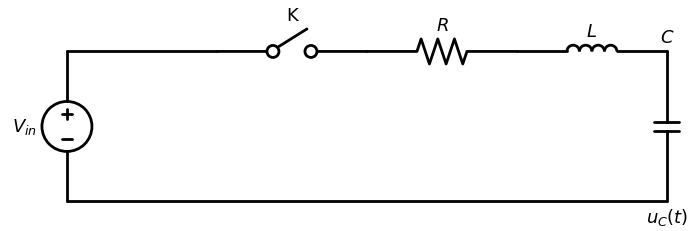

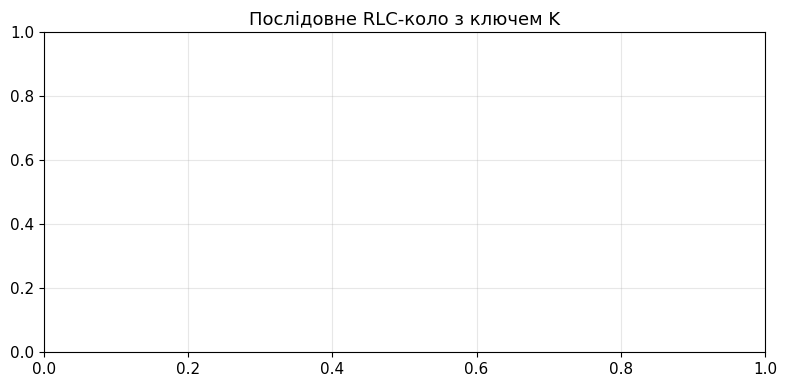

In [8]:
# Schemdraw: RLC series circuit
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13) as d:
        d += (v := elm.SourceV().up().label('$V_{in}$'))
        d += elm.Line().right()
        d += (sw := elm.Switch().right().label('K', loc='top'))
        d += (r := elm.Resistor().right().label('$R$'))
        d += (l := elm.Inductor().right().label('$L$'))
        d += (c := elm.Capacitor().down().label('$C$', loc='right').label('$u_C(t)$', loc='left'))
        d += elm.Line().left().tox(v.start)
    plt.title('Послідовне RLC-коло з ключем K')
    plt.tight_layout(); plt.show()
else:
    print('pip install schemdraw')

---
---
## Перехідні процеси другого порядку  <a class="anchor" id="Comutation-calculation-2nd-order"></a>

### Розрахунок послідовного включення RLC  <a class="anchor" id="RLC-series-comutation-calculation-classic"></a>

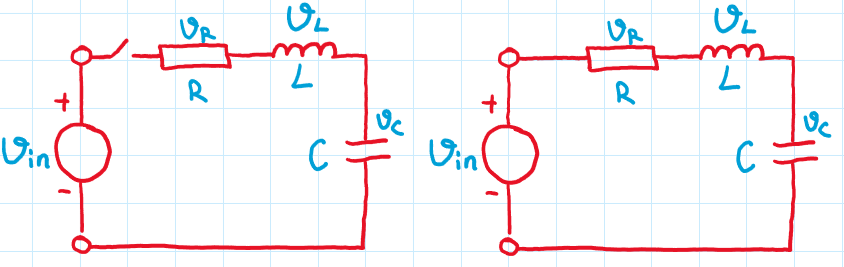

Запишемо диференційне рівняння для опису схеми в момент $t(0_+)$ після комутації:

$$v_{in}(t) = v_{R}(t) + v_{L}(t) + v_{C}(t)$$

Струм в контурі:

$$i = i_{c} = C \cdot \cfrac{dv_{c}}{dt}$$

Опишемо напруги на компонентах через напругу на конденсаторі:

$$v_{r} = i \cdot R = RC \cdot \cfrac{dv_{c}}{dt}$$

$$v_{L} = L \cdot \cfrac{di}{dt} = LC \cfrac{d^{2}v_{c}}{dt^{2}}$$

$$ LC \cfrac{d^{2}v_{c}(t)}{dt^{2}} + RC \cdot \cfrac{dv_{c(t)}}{dt} + v_{c}(t) = v_{in}(t)$$

$$ \cfrac{d^{2}v_{c}(t)}{dt^{2}} + \cfrac{R}{L} \cdot \cfrac{dv_{c(t)}}{dt} + \cfrac{1}{LC} v_{c}(t) = \cfrac{v_{in}(t)}{LC}  $$

$$ \cfrac{d^{2}v_{c}(t)}{dt^{2}} + \cfrac{R}{L} \cdot \cfrac{dv_{c(t)}}{dt} + \cfrac{1}{LC} v_{c}(t) = 0  $$

Введемо заміну $D$: 

$$ D^{2} + \cfrac{R}{L} \cdot D + \cfrac{v_{c}}{LC} = 0  $$

Розв'язки рівняння:

$$ D_{1} = -\cfrac{R}{2L} + \sqrt{  (\cfrac{R}{2L})^2 - \cfrac{1}{LC} }$$

$$ D_{2} = -\cfrac{R}{2L} - \sqrt{  (\cfrac{R}{2L})^2 - \cfrac{1}{LC} }$$

Введемо заміни:

$$ \alpha = \cfrac{R}{2L}$$

$$ \beta  = \sqrt{  (\cfrac{R}{2L})^2 - \cfrac{1}{LC} }$$

Розв'язки рівняння:

$$ D_{1} = -\alpha + \beta$$

$$ D_{2} = -\alpha - \beta$$

Natural frequency

$$ \omega = \cfrac{1}{\sqrt{LC}}$$

Damping coefficient

$$ \alpha = \cfrac{R}{2L} $$

Damping factor:

$$ \cfrac{\alpha}{\omega} = \zeta = \cfrac{R}{2} \sqrt{ \cfrac{C}{L} }$$

---
#### Випадок 1: 

$$ (\cfrac{R}{2L})^2 >  \cfrac{1}{LC} $$

В цьому випадку корені рівнняння негативні і некомплексні

$$ v_{c}(t) = C_{1} \cdot e^{-D_{1}t} + C_{2} \cdot e^{-D_{2}t} $$

Overdamped response

$$ (\cfrac{R}{2L})^2 >  \cfrac{1}{LC} $$

 ---
#### Випадок 2: 

$$(\cfrac{R}{2L})^2 =  \cfrac{1}{LC} $$

В цьому випадку корені рівнняння негативні, некомплексні і однакові

$$ D_{1} = D_{2} = - \alpha $$

$$ v_{c}(t) = (C_{1} + C_{2}t) \cdot e^{-\alpha t} $$

Critically damped response
$$ (\cfrac{R}{2L})^2 =  \cfrac{1}{LC} $$

---
#### Випадок 3:

$$ (\cfrac{R}{2L})^2 <  \cfrac{1}{LC} $$

В цьому випадку корені рівнняння комплексно-спряжені

$$ D_{1} = - \alpha + j\beta $$
$$ D_{2} = - \alpha - j\beta $$

$$ v_{c}(t) = e^{-\alpha t} \cdot ( C_{1} cos( \beta t) +C_{2} sin( \beta t)) $$

Under damped response
$$ (\cfrac{R}{2L})^2 < \cfrac{1}{LC} $$

---

#### Випадок 4: 

$$ R = 0 $$

В цьому випадку корені рівнняння комплексні

$$ D_{1} = j \sqrt{\frac{1}{LC}} = j \omega $$
$$ D_{2} = - j \omega $$

$$ v_{c}(t) =   C_{1} cos( \omega t) +C_{2} sin( \omega t)  $$

---

### Приклад розрахунку напруги ємності в числовому вигляді з використанням PySpice

In [9]:
def g(R_sb, L_sb, C_sb):
    # Define circuit
    circuit = Circuit('RLC series connection')
    source = circuit.PulseVoltageSource('input', 1, circuit.gnd,
                                        initial_value=0@u_V, pulsed_value=12@u_V,
                                        pulse_width=100@u_ms, period=200@u_ms)
    # Define components
    circuit.R(1, 2, 1, R_sb@u_Ω)
    circuit.L(1, 3, 2, L_sb@u_mH)
    circuit.C(1, circuit.gnd, 3, C_sb@u_nF)

    # Perform transient analysis
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    steptime = 1@u_us
    finaltime = 1@u_ms
    analysis = simulator.transient(step_time=steptime, end_time=finaltime)

    # Plot the results
    figure, axe = plt.subplots(figsize=(10, 6))
    plt.title('Перехідний процес послідовно включених RLC')
    plt.xlabel('Час, [с]')
    plt.ylabel('Напруга, [В]')

    plot((analysis['1'] - analysis['2'])/R_sb, axis=axe)
    #plot(analysis['3'], axis=axe)

    plt.grid()
    plt.legend(('Вхідний сигнал', 'Напруга на конденсаторі'), loc='best')
    cursor = Cursor(axe, useblit=True, color='red', linewidth=1)
    plt.tight_layout()
    plt.show()

w = interactive(g, 
                R_sb=widgets.IntSlider(min=0, max=20000, step=1, value=14140, description = '$R_{1}, [/Omega]$'), 
                L_sb=widgets.IntSlider(min=1, max=1000, step=1, value=20, description ='$L_{1}, [uH]$'), 
                C_sb=widgets.IntSlider(min=1, max=1000, step=1, value=10, description = '$C_{1},[mF]$'))
display(w)



interactive(children=(IntSlider(value=14140, description='$R_{1}, [/Omega]$', max=20000), IntSlider(value=20, …

___
### Приклад розрахунку струму контуру в аналітичному вигляді з використанням sympy.dsolve

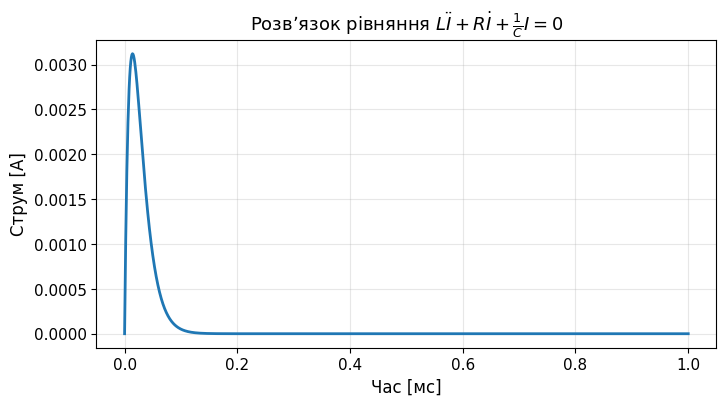

In [10]:
import sympy as smp
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define circuit parameters and initial conditions
R = 2828  # Resistance (Ohms)
#R = 14140
L = 20e-3  # Inductance (Henries)
C = 10e-9  # Capacitance (Farads)
V = 12     # Voltage (Volts)

t = smp.symbols('t')
I = smp.Function('I')(t)

# Step 2: Set up the differential equation
eq = smp.Eq(L * I.diff(t, 2) + R * I.diff(t) + (1/C) * I, 0)

# Step 3: Initial conditions: I(0)=0, dI/dt(0)=V/L
ics = {
    I.subs(t, 0): 0,
    I.diff(t).subs(t, 0): V / L
}

# Step 4: Solve the differential equation
sol = smp.dsolve(eq, I, ics=ics)

# Step 5: Convert symbolic solution to numerical function
I_func = smp.lambdify(t, sol.rhs, 'numpy')

# Step 6: Time values
time_values = np.linspace(0, 1e-3, 1000)  # Adjusted for milliseconds scale

# Step 7: Evaluate I(t)
current_values = I_func(time_values)

# Step 8: Plot
plt.plot(time_values * 1e3, current_values)  # convert time to milliseconds
plt.title('Розв’язок рівняння $L\\ddot{I} + R\\dot{I} + \\frac{1}{C}I = 0$')
plt.xlabel('Час [мс]')
plt.ylabel('Струм [A]')
plt.grid(True)
plt.show()

In [11]:
sol.rhs

0.488273075262056*exp(-70700.0*t)*sin(1228.82057274606*t)

In [12]:
sol.lhs

I(t)

In [13]:
if ((R/(2*L))**2) > 1/(L*C):
  print("Випадок 1: В цьому випадку корені рівнняння негативні і некомплексні")
elif ((R/(2*L))**2) == 1/(L*C):
  print("Випадок 2: В цьому випадку корені рівнняння комплексно-спряжені")
elif ((R/(2*L))**2) < 1/(L*C):
  print("Випадок 3: В цьому випадку корені рівнняння комплексно-спряжені")
elif R == 0:
  print("Випадок 4: В цьому випадку корені рівнняння негативні і некомплексні")
else:
  print("Помилка")

Випадок 3: В цьому випадку корені рівнняння комплексно-спряжені


In [14]:
D1, D2 = smp.symbols('D1 D2')

eq1 = -R/(2*L)+smp.sqrt( (R/(2*L))**2 - 1/(L*C) )-D1
eq2 = -R/(2*L)-smp.sqrt( (R/(2*L))**2 - 1/(L*C) )-D2

sol_2 = smp.solve([eq1, eq2], [D1,D2])

In [15]:
sol_2

{D1: -70700.0 + 1228.82057274445*I, D2: -70700.0 - 1228.82057274445*I}

In [16]:
p = smp.symbols('p')
#Крок 2: Налаштуйте диференціальне рівняння
eq = (V * C)/ (p**2 * L * C + p * R * C + 1) 
print(eq)

num,den = smp.fraction(eq)
print(num)
print(den)

#Крок 3: Розв'яжіть диференціальне рівняння
sol_p = smp.solve([den], [p], dict=True)
print(sol)

den_diff = smp.diff(den, p)
print(den_diff)

I = smp.Function('I')(t) # Current through the circuit
I = ((num.subs(p,sol_p[0][p]))/(den_diff.subs(p,sol_p[0][p])))*smp.exp(sol_p[0][p]*t)+((num.subs(p,sol_p[1][p]))/(den_diff.subs(p,sol_p[1][p])))*smp.exp(sol_p[1][p]*t)
I_func = smp.lambdify(t, I, 'numpy')

#Крок 6: Оцініть I(t) для кожного моменту часу
current_values3 = np.array([I_func(ti) for ti in time_values])

1.2e-7/(2.0e-10*p**2 + 2.828e-5*p + 1)
1.20000000000000e-7
2.0e-10*p**2 + 2.828e-5*p + 1


Eq(I(t), 0.488273075262056*exp(-70700.0*t)*sin(1228.82057274606*t))
4.0e-10*p + 2.828e-5


---
---
### Розрахунок паралельного включення RLC  <a class="anchor" id="RLC-parallel-comutation-calculation-classic"></a>

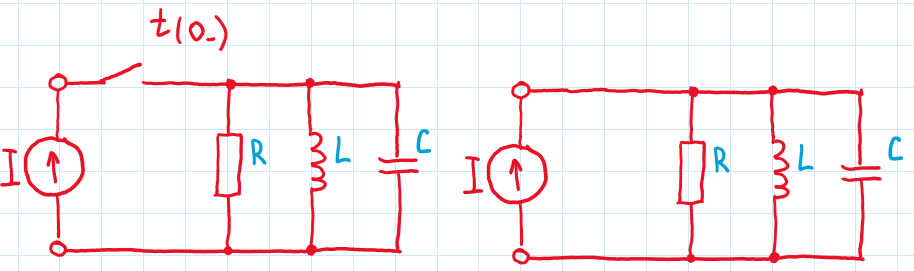

Запишемо диференційне рівняння для опису схеми в момент $t(0_+)$ після комутації:

$$i_{in}(t) =  i_{R}(t) + i_{L}(t) + i_{C}(t)$$

$$i_{in}(t) =  \cfrac{v}{R}  + \cfrac{1}{L} \int v dt + C \cfrac{dv}{dt}$$

Візьмемо похідну:

$$ C \cfrac{d^2v(t)}{dt^2} + \cfrac{1}{R}\cfrac{dv(t)}{dt} + \cfrac{1}{L} v(t)  = 0 $$

Поділимо на $C$ і виконаємо заміну  $D$:

$$  D^2 + \cfrac{1}{RC} D + \cfrac{1}{LC}  = 0 $$

$$ D_{1} = -\cfrac{1}{2RC} + \sqrt{  (\cfrac{1}{2RC})^2 - \cfrac{1}{LC} }$$

$$ D_{2} = -\cfrac{1}{2RC} - \sqrt{  (\cfrac{1}{2RC})^2 - \cfrac{1}{LC} }$$

Введемо заміни:

$$ \alpha = \cfrac{1}{2RC}$$

$$ \beta  = \sqrt{  (\cfrac{1}{2RC})^2 - \cfrac{1}{LC} }$$

$$ D_{1} = -\alpha + \beta$$

$$ D_{2} = -\alpha - \beta$$

---
#### Випадок 1: 

$$ (\cfrac{1}{2RC})^2 >  \cfrac{1}{LC} $$

В цьому випадку корені рівнняння негативні і некомплексні

$$ v_{c}(t) = C_{1} \cdot e^{-D_{1}t} + C_{2} \cdot e^{-D_{2}t}$$

Overdamped response

$$ (\cfrac{1}{2RC})^2 >  \cfrac{1}{LC} $$

---
#### Випадок 2: 

$$(\cfrac{1}{2RC})^2 =   \cfrac{1}{LC} $$

В цьому випадку корені рівнняння негативні, некомплексні і однакові

$$ D_{1} = D_{2} = - \alpha$$

$ v_{c}(t) = (C_{1} + C_{2}t) \cdot e^{-\alpha t}  $

Critically damped response

$$(\cfrac{1}{2RC})^2 =   \cfrac{1}{LC} $$

---
#### Випадок 3: 

$$ (\cfrac{1}{2RC})^2 <   \cfrac{1}{LC} $$

В цьому випадку корені рівнняння комплексно-спряжені

$$ D_{1} = - \alpha + j\beta $$
$$ D_{2} = - \alpha - j\beta $$

$$ v_{c}(t) = e^{-\alpha t} \cdot ( C_{1} cos( \beta t) +C_{2} sin( \beta t)) $$

Under damped response

$$ (\cfrac{1}{2RC})^2 <   \cfrac{1}{LC} $$

---
#### Випадок 4: 

$$ R = \infty $$

В цьому випадку корені рівнняння комплексні

$$ D_{1} = j \sqrt{\frac{1}{LC}} = j \omega $$
$$ D_{2} = - j \omega $$

$$ v_{c}(t) =   C_{1} cos( \omega t) +C_{2} sin( \omega t)  $$

---

In [17]:
def g(R_sb, L_sb, C_sb):
    # Define circuit
    circuit = Circuit('RLC series connection')
    source = circuit.PulseCurrentSource('input', 1, circuit.gnd,
                                        initial_value=0@u_A, pulsed_value=10@u_A,
                                        pulse_width=100@u_ms, period=200@u_ms)
    # Define components
    circuit.R(1, 1, circuit.gnd, R_sb@u_Ω)
    circuit.L(1, 1, circuit.gnd, L_sb@u_mH)
    circuit.C(1, 1, circuit.gnd, C_sb@u_uF)

    # Perform transient analysis
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    steptime = 1@u_us
    finaltime = 200@u_ms
    analysis = simulator.transient(step_time=steptime, end_time=finaltime)

    # Plot the results
    figure, axe = plt.subplots(figsize=(10, 6))
    plt.title('Перехідний процес послідовно включених RLC')
    plt.xlabel('Час, [с]')
    plt.ylabel('Напруга, [В]')

    plot(analysis['1'], axis=axe)

    plt.grid()
    plt.legend(('Напруга на конденсаторі','Вхідний сигнал' ), loc='best')
    cursor = Cursor(axe, useblit=True, color='red', linewidth=1)
    plt.tight_layout()
    plt.show()

w = interactive(g, 
                R_sb=widgets.IntSlider(min=0, max=1000, step=1, value=40, description = r'$R_{1}, [\Omega]$'), 
                L_sb=widgets.IntSlider(min=1, max=1000, step=1, value=300, description ='$L_{1}, [uH]$'), 
                C_sb=widgets.IntSlider(min=1, max=100, step=1, value=10, description = '$C_{1},[mF]$'))
display(w)

interactive(children=(IntSlider(value=40, description='$R_{1}, [\\Omega]$', max=1000), IntSlider(value=300, de…

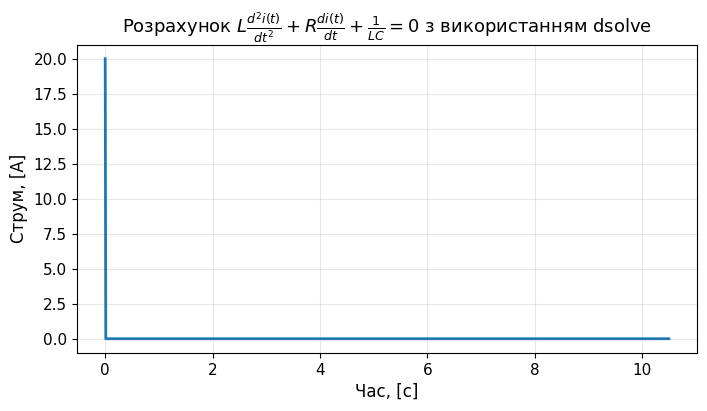

In [18]:
# Step 1: Define circuit parameters and initial conditions
R = 0.01  # Resistance (in ohms)
L = 1  # Inductance (in henrys)
C = 0.05  # Capacitance (in farads)
Vin = 20   # Applied DC voltage (in volts)

t = smp.symbols('t')  # Time symbol
V = smp.Function('V')(t)  # Current through the circuit

# Step 2: Set up the differential equation
eq = C * V.diff(t, 2) + 1/R * V.diff(t) + 1/L * V
# Initial conditions: заряджений конденсатор V(0)=Vin, i_L(0)=0 -> C*V'(0) = -Vin/R
ics = {V.subs(t, 0): Vin, smp.diff(V, t).subs(t, 0): -Vin/(R*C)}

# Step 3: Solve the differential equation
sol = smp.dsolve(eq, V, ics=ics)


# Step 4: Convert symbolic solution to a callable function
V_func = smp.lambdify(t, sol.rhs, 'numpy')

# Step 5: Generate a range of time values
time_values = np.linspace(0, 10.5, 1000)  # Adjust the range as needed

# Step 6: Evaluate I(t) for each time point
current_values = np.array([V_func(ti) for ti in time_values])

# Step 7: Plot the graph
plt.plot(time_values, current_values)
plt.title('Розрахунок $ L\\frac{d^{2}i(t)}{dt^{2}} + R\\frac{di(t)}{dt} + \\frac{1}{LC} = 0 $ з використанням dsolve')
plt.xlabel('Час, [c]')
plt.ylabel('Струм, [A]')
plt.grid(True)
plt.show()


In [19]:
sol.rhs

20.0001000015*exp(-1999.98999995*t) - 0.00010000150002*exp(-0.0100000500005*t)

In [20]:
V_func(2)


np.float64(-9.802132784605816e-05)

$$ C \cfrac{d^2v(t)}{dt^2} + \cfrac{1}{R}\cfrac{dv(t)}{dt} + \cfrac{1}{L} v(t)  = 0 $$


---
### ⚡ Практичне застосування: Перехідні процеси 2-го порядку (RLC)

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Три режими перехідного процесу в послідовному RLC:**

| Режим | Умова | Характер u_C(t) | Де використовується |
|-------|-------|----------------|--------------------|
| **Аперіодичний** | $R > 2\sqrt{L/C}$ | Монотонне наростання | Схеми живлення без перерегулювання |
| **Критичний** | $R = 2\sqrt{L/C}$ | Монотонне, мінімальний час | Швидкодіючі позиціонери |
| **Коливний (недогасаючий)** | $R < 2\sqrt{L/C}$ | Затухаючі коливання | LC-генератори, резонансні контури |

**Добротність:**
$$Q = \frac{1}{R}\sqrt{\frac{L}{C}} = \frac{\omega_0}{2\delta}$$
де $\delta = R/(2L)$ — декремент затухання. Чим більше $Q$, тим повільніше затухає процес.

> **Радіопрактика:** Резонансний контур радіоприймача — це RLC-ланцюг у коливному режимі. $Q = 50\ldots200$ забезпечує вибірковість каналів.

</div>

---
### ✅ Питання для самоперевірки: Перехідні процеси 2-го порядку

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> При яких умовах виникає аперіодичний, критичний і коливний режими?</summary>

> **Відповідь:** Дискримінант характеристичного рівняння $p^2 + 2\delta p + \omega_0^2 = 0$:
> - $\delta^2 > \omega_0^2$ ($R > 2\sqrt{L/C}$) — два дійсних кореня, аперіодичний режим.
> - $\delta^2 = \omega_0^2$ — кратний корінь, критичний режим.
> - $\delta^2 < \omega_0^2$ — комплексні корені, коливний режим.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Яка фізична роль декременту затухання delta?</summary>

> **Відповідь:** $\delta = R/(2L)$ — показник швидкості спаду огинаючої коливань: $e^{-\delta t}$. За час $\tau = 1/\delta$ амплітуда зменшується в $e$ разів.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Що таке часткова частота і яка відмінність від резонансної?</summary>

> **Відповідь:** Резонансна (власна): $\omega_0 = 1/\sqrt{LC}$. Частота коливань при перехідному процесі: $\omega_d = \sqrt{\omega_0^2 - \delta^2} < \omega_0$. При малому загасанні $\omega_d \approx \omega_0$.

</details>

## Довга лінія <a class="anchor" id="transmission-line"></a>

---

У математиці, фізиці та інженерії, поняття **довгих ліній** є ключовим для розуміння різноманітних фізичних явищ та їх моделювання. Довгі лінії - це електричні елементи зі значною довжиною у порівнянні з довжиною хвиль, які поширюються в них.

### Основні аспекти

1. **Довга лінія** - це електричний елемент, що виявляє значний вплив на передачу електричних сигналів через нього. Її довжина порівняно велика порівняно з довжиною хвиль у передаваному сигналі. Це може бути кабель, провід або структура, яка здатна передавати сигнали.

2. **Розповсюдження сигналів**: Довгі лінії мають здатність передавати електричні сигнали на великі відстані без помітних спотворень. Це дозволяє використовувати їх у телекомунікаційних мережах, системах передачі даних, а також у системах електропередачі.

3. **Характеристичний імпеданс**: Кожна довга лінія має характеристичний імпеданс ($Z_0$), що визначається властивостями самої лінії. Він відіграє важливу роль у визначенні передачі сигналів через лінію та може бути обчислений за допомогою спеціальних формул.

    Формула для характеристичного імпедансу:
    $$ Z_0 = \sqrt{\frac{R + j\omega L}{G + j\omega C}} $$
    
     Де:
    - $R$ - опір на одиницю довжини лінії,
    - $L$ - індуктивність на одиницю довжини лінії,
    - $G$ - провідність на одиницю довжини лінії,
    - $C$ - ємність на одиницю довжини лінії,
    - $\omega$ - кругова частота сигналу.

4. **Розподіл параметрів**: Довгі лінії характеризуються розподілом параметрів, таких як імпеданс, індуктивність та ємність, вздовж їх довжини. Цей розподіл може бути змінним або сталим в залежності від характеру лінії та її конструкції.

5. **Реакція на сигнали**: Довгі лінії виявляють реакцію на різноманітні сигнали, що проходять через них. Ця реакція може включати в себе затримку сигналу, зміну амплітуди та спотворення хвильової форми. Розуміння цих ефектів дозволяє інженерам ефективно проектувати та використовувати довгі лінії у різних системах.

### Важливість у практиці

Довгі лінії мають широкі застосування у різних галузях:

- **Телекомунікаційні системи**: Вони використовуються для передачі даних у телефонних мережах, Інтернеті, телевізійних та радіомовних системах.

- **Електропередача**: Довгі лінії використовуються для передачі електроенергії від джерела до споживача.

- **Електроніка**: У мікроелектроніці вони використовуються для передачі сигналів між різними частинами електронних пристроїв.

- **Мережі передачі даних**: Вони є основою для створення мереж передачі даних, які використовуються у бізнесі та особистому житті.

- **Радіоімунікація**: У бездротових системах зв'язку довгі лінії використовуються для передачі радіосигналів на великі відстані.


---
### Параметри довгої лінії та їх фізичний зміст <a class="anchor" id="transmission-line-interactive"></a>

| Параметр | Позначення | Одиниця | Фізичний зміст |
|----------|-----------|---------|----------------|
| Погонний опір | $R'$ | Ом/м | Активні втрати провідника |
| Погонна індуктивність | $L'$ | Гн/м | Магнітна енергія навколо лінії |
| Погонна провідність | $G'$ | См/м | Втрати в діелектрику між провідниками |
| Погонна ємність | $C'$ | Ф/м | Електрична енергія між провідниками |

**Характеристичний імпеданс (хвильовий опір):**
$$Z_0 = \sqrt{\frac{R' + j\omega L'}{G' + j\omega C'}}$$
При малих втратах ($R' \ll \omega L'$, $G' \ll \omega C'$): $Z_0 \approx \sqrt{L'/C'}$

**Коефіцієнт поширення:**
$$\gamma = \alpha + j\beta = \sqrt{(R' + j\omega L')(G' + j\omega C')}$$
- $\alpha$ — коефіцієнт загасання (Нп/м)
- $\beta = \omega/v_{ph}$ — коефіцієнт фази, $v_{ph} = 1/\sqrt{L'C'}$ — фазова швидкість

**Коефіцієнт відбиття:**
$$\Gamma = \frac{Z_L - Z_0}{Z_L + Z_0}$$
- $\Gamma = 0$ при $Z_L = Z_0$ — узгоджений режим (максимальна передача потужності)
- $\Gamma = -1$ при $Z_L = 0$ (КЗ) — повне відбиття з інверсією
- $\Gamma = +1$ при $Z_L = \infty$ (розрив) — повне відбиття без інверсії

In [21]:
# Інтерактивна довга лінія: розподіл напруги вздовж лінії
def transmission_line_interactive(Z0=50.0, ZL=75.0, f_MHz=100.0, length_m=2.0, alpha_dB_m=0.0):
    c0 = 3e8  # швидкість світла
    f = f_MHz * 1e6
    lam = c0 / f
    beta = 2 * np.pi / lam  # рад/м
    alpha = alpha_dB_m / (20 * np.log10(np.e))  # дБ/м -> Нп/м
    gamma = alpha + 1j * beta

    Gamma_L = (ZL - Z0) / (ZL + Z0)

    x_vals = np.linspace(0, length_m, 500)  # від джерела до навантаження
    # At position x from source, l = length-x from load
    l_vals = length_m - x_vals
    V_fwd = np.exp(-gamma * x_vals)
    V_bwd = Gamma_L * np.exp(-gamma * (2*length_m - x_vals))
    V_total = V_fwd + V_bwd

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(x_vals, np.abs(V_total), '#2196F3', label='|V(x)|')
    axes[0].plot(x_vals, np.abs(V_fwd), '#4CAF50', ls='--', lw=1.5, label='Пряма хвиля')
    axes[0].plot(x_vals, np.abs(V_bwd), '#F44336', ls='--', lw=1.5, label='Відбита хвиля')
    axes[0].set_xlabel('x, м (від джерела)')
    axes[0].set_ylabel('Відносна амплітуда |V|')
    axes[0].set_title(f'КСХ (VSWR) = {(1+abs(Gamma_L))/(1-abs(Gamma_L)):.2f}')
    axes[0].legend()

    # SWR pattern along line
    vswr = np.abs(V_total)
    axes[1].plot(x_vals, 20*np.log10(np.abs(V_total)+1e-12), '#FF9800')
    axes[1].set_xlabel('x, м'); axes[1].set_ylabel('|V|, дБ')
    axes[1].set_title('Розподіл напруги (дБ)')

    plt.suptitle(f'Z0={Z0} Ом, ZL={ZL} Ом, f={f_MHz} МГц | '
                 f'Gamma={Gamma_L:.3f}, KCX={(1+abs(Gamma_L))/(max(1-abs(Gamma_L),1e-6)):.2f}',
                 fontsize=11)
    plt.tight_layout(); plt.show()
    print(f'Коефіцієнт відбиття: Gamma = {Gamma_L:.3f}')
    print(f'КСХ (VSWR) = {(1+abs(Gamma_L))/max(1-abs(Gamma_L),1e-6):.3f}')
    print(f'Довжина хвилі: lambda = {lam*100:.2f} см')
    print(f'Відношення l/lambda = {length_m/lam:.3f}')

interact(transmission_line_interactive,
         Z0=widgets.FloatSlider(min=10, max=300, step=5, value=50, description='Z0 (Ом)'),
         ZL=widgets.FloatSlider(min=0, max=500, step=5, value=75, description='ZL (Ом)'),
         f_MHz=widgets.FloatSlider(min=10, max=3000, step=10, value=100, description='f (МГц)'),
         length_m=widgets.FloatSlider(min=0.1, max=10, step=0.1, value=2.0, description='L (м)'),
         alpha_dB_m=widgets.FloatSlider(min=0, max=1, step=0.01, value=0, description='Затух. (дБ/м)'))

interactive(children=(FloatSlider(value=50.0, description='Z0 (Ом)', max=300.0, min=10.0, step=5.0), FloatSlid…

<function __main__.transmission_line_interactive(Z0=50.0, ZL=75.0, f_MHz=100.0, length_m=2.0, alpha_dB_m=0.0)>

---
### Моделювання однорідної лінії ланцюговою схемою <a class="anchor" id="line-ladder-model"></a>

Однорідну довгу лінію моделюють, подумки розбивши її на нескінченно малі відрізки довжини $\Delta x$ і замінивши кожен відрізок **зосередженою Г-подібною ланкою** з погонними параметрами:

- поздовжня вітка: $R'\Delta x$ (опір) послідовно з $L'\Delta x$ (індуктивність);
- поперечна вітка: $G'\Delta x$ (провідність) паралельно з $C'\Delta x$ (ємність).

Каскадне (ланцюгове) з'єднання $N$ таких однакових ланок при $\Delta x = l/N \to 0$ (і, відповідно, $N\to\infty$) наближає лінію довжини $l$ зі скінченною похибкою, що прямує до нуля.


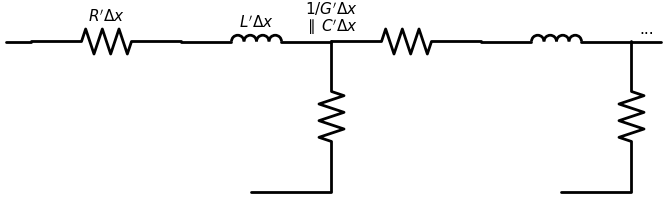

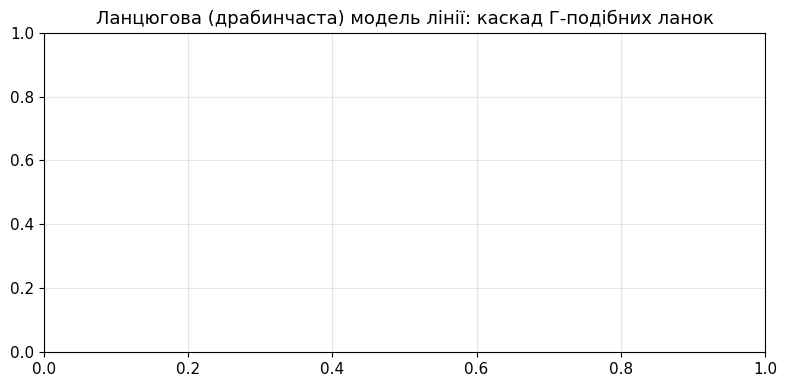

In [22]:
# Schemdraw: моделювання лінії ланцюговою (драбинчастою) схемою з Г-подібних ланок
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=11) as d:
        d += elm.Line().right(0.5)
        for k in range(2):
            d += elm.Resistor().right().label(f"$R'\\Delta x$" if k == 0 else '', loc='top')
            d += elm.Inductor().right().label(f"$L'\\Delta x$" if k == 0 else '', loc='top')
            d.push()
            d += elm.Resistor().down().label(f"$1/G'\\Delta x$\n$\\parallel\\, C'\\Delta x$" if k == 0 else '', loc='right')
            d += elm.Line().left(1.6 if k == 0 else 1.4)
            d.pop()
        d += elm.Line().right(0.6).label('...')
    plt.title("Ланцюгова (драбинчаста) модель лінії: каскад Г-подібних ланок")
    plt.tight_layout(); plt.show()
else:
    print('Встановіть schemdraw: pip install schemdraw')


Запишемо закони Кірхгофа для однієї ланки між координатами $x$ і $x+\Delta x$:

$$v(x+\Delta x,t)-v(x,t) = -\Delta x\left[R' i(x,t) + L'\frac{\partial i}{\partial t}\right]$$

$$i(x+\Delta x,t)-i(x,t) = -\Delta x\left[G' v(x+\Delta x,t) + C'\frac{\partial v}{\partial t}\right]$$

Поділимо обидві частини на $\Delta x$ і перейдемо до границі $\Delta x\to0$ — різницеві відношення стають частинними похідними за координатою, і виходять саме **телеграфні рівняння**, наведені нижче:

$$\frac{\partial v}{\partial x} = -R'i-L'\frac{\partial i}{\partial t}, \qquad \frac{\partial i}{\partial x} = -G'v-C'\frac{\partial v}{\partial t}$$

Таким чином, телеграфні рівняння — це граничний випадок ланцюгової схеми при нескінченно малому кроці розбиття, а сама ланцюгова схема — зручна модель для чисельного (SPICE-подібного) моделювання лінії скінченним числом елементів.


### Телеграфне рівняння <a class="anchor" id="Line-Telegraphe-equation"></a>

Телеграфне рівняння

$$ 
\begin{cases} 
\cfrac{\partial}{\partial x} V(x,t) = -L \cfrac{\partial}{\partial t} I(x,t)- R I(x,t) \\
\cfrac{\partial}{\partial x} I(x,t) = -C \cfrac{\partial}{\partial t} V(x,t)- G V(x,t)
\end{cases}$$

---
### Рухома хвиля. Пряма і зворотна хвилі <a class="anchor" id="traveling-wave"></a>

Для **лінії без втрат** ($R'=G'=0$, див. нижче) телеграфні рівняння зводяться до одного хвильового рівняння відносно напруги (аналогічно для струму):

$$\frac{\partial^2 v}{\partial x^2} = L'C'\frac{\partial^2 v}{\partial t^2}$$

Загальний розв'язок цього рівняння (розв'язок Д'Аламбера) має вигляд суми двох **рухомих хвиль**:

$$v(x,t) = \underbrace{f_1\!\left(t-\dfrac{x}{v_{ph}}\right)}_{\text{пряма хвиля}} + \underbrace{f_2\!\left(t+\dfrac{x}{v_{ph}}\right)}_{\text{зворотна хвиля}}, \qquad v_{ph}=\frac{1}{\sqrt{L'C'}}$$

- **Пряма хвиля** $f_1$ — довільна за формою функція, що переміщується від джерела до навантаження (у бік зростання $x$) зі швидкістю $v_{ph}$ без зміни форми — саме тому вона є функцією єдиної комбінованої змінної $t-x/v_{ph}$.
- **Зворотна хвиля** $f_2$ — функція, що рухається у протилежному напрямку (від навантаження до джерела); виникає внаслідок **відбиття** прямої хвилі від навантаження, якщо воно не узгоджене з хвильовим опором лінії ($Z_L\ne Z_0$, див. коефіцієнт відбиття $\Gamma$ вище).

Відповідний струм пов'язаний з хвилями напруги через характеристичний опір $Z_0$ (пряма й зворотна хвилі струму мають протилежний знак, бо рухаються у протилежних напрямках):

$$i(x,t) = \frac{1}{Z_0}\left[f_1\!\left(t-\frac{x}{v_{ph}}\right) - f_2\!\left(t+\frac{x}{v_{ph}}\right)\right]$$

У точці навантаження повна напруга й струм — це сума прямої та зворотної складових; саме такий запис (`V_fwd`, `V_bwd`) використано в інтерактивному розрахунку вище.


### Умова для лінії, що не спотворює (умова Хевісайда) <a class="anchor" id="distortionless-line"></a>

У загальному випадку коефіцієнт загасання $\alpha(\omega)$ і фазова швидкість $v_{ph}(\omega)=\omega/\beta(\omega)$ залежать від частоти — різні гармонічні складові сигналу загасають і затримуються по-різному, тому форма сигналу на виході спотворюється (явище **дисперсії**).

**Олівер Хевісайд** показав, що спотворення відсутнє, якщо виконується умова:

$$\frac{R'}{L'} = \frac{G'}{C'} \qquad\Longleftrightarrow\qquad R'C' = L'G'$$

За цієї умови коефіцієнт загасання і фазова швидкість **не залежать від частоти**:

$$\alpha = R'\sqrt{\frac{C'}{L'}} = \text{const}(\omega), \qquad v_{ph}=\frac{1}{\sqrt{L'C'}} = \text{const}(\omega)$$

тобто всі частотні складові сигналу однаково послаблюються й затримуються — сигнал на виході є точною (лише масштабованою й затриманою) копією вхідного, без спотворення форми. На практиці для кабельних ліній зазвичай $L'/R' \ll C'/G'$, тому історично для наближення до умови Хевісайда в лінії штучно збільшували погонну індуктивність, вмикаючи через певні відстані котушки навантаження (**котушки Пупіна**).

### Лінія без втрат <a class="anchor" id="lossless-line"></a>

**Лінія без втрат** — окремий (ідеалізований) випадок, коли $R'=0$ і $G'=0$ (немає ані активних втрат у провіднику, ані витоку в діелектрику). Умова Хевісайда при цьому виконується тривіально ($0=0$), тобто лінія без втрат автоматично є лінією, що не спотворює:

$$Z_0=\sqrt{\frac{L'}{C'}} \;\text{(дійсний, не залежить від }\omega),\qquad \gamma=j\beta=j\omega\sqrt{L'C'} \;(\alpha=0),\qquad v_{ph}=\frac{1}{\sqrt{L'C'}}$$

Це наближення добре працює для коротких високочастотних ліній (короткі відрізки коаксіального кабелю, мікросмужкові лінії на платі), де активні втрати за час проходження сигналу нехтовно малі.


In [23]:
# Based on
# https://github.com/ClecioJung/TransmissionLine/blob/main/TransmissionLine.m

#import numpy as np
#import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
#from scipy.signal import sawtooth, square


def g(V_in_sb, Signal_sb):
    # Transmission line parameters
    R = 45.3e-3  # ohm/m
    G = 0  # S/m (information not available in the catalog)
    L = 0.205e-6  # H/m
    C = 182e-13  # F/m
    Z = np.sqrt(L / C)  # ohm
    vel = 1 / np.sqrt(L * C)  # m/s
    
    # Load resistor
    Rl = 10  # ohm
    
    # Arbitrary function generator
    Rg = 50  # ohm
    Ton = 10e-9  # s
    Toff = 110e-9  # s
    Vamp = 10  # V
    fg = 10e6  # Hz
    
    # Type of signal applied by the function generator
    # Options: 'p'ulse, 's'ine wave, 't'riangle wave or s'q'uare wave

    if Signal_sb == 1:
        signal = 'p'
    elif Signal_sb == 2:
        signal = 's'
    elif Signal_sb == 3:
        signal = 't'
    else:
        signal = 'q'

    # Finite difference method used
    # Options: 'a'dvance, 'r'etrograde or 'c'entered
    finiteDiff = 'c'
    
    # Simulation method: 'e'xplicit or 'i'mplicit
    method = 'i'
    
    # Simulation intervals
    dt = 1e-10  # s
    t0 = 0  # s
    tf = 2000e-9  # s
    dx = 1e-1  # m
    x0 = 0  # m
    xf = 100  # m
    
    # Animation settings
    filename = 'wave.gif'  # File to save the animation
    Nmax = 200  # Maximum amount of points
    axisInc = Vamp / 10  # Quantization of axes
    
    # Initial calculations
    x = np.arange(x0, xf + dx, dx)
    t = np.arange(t0, tf + dt, dt)
    J = len(x)
    N = len(t)
    v = np.zeros((N, J))  # Null initial conditions
    
    # Function generator
    if signal == 's':
        Vg = lambda t: Vamp * np.heaviside(t - Ton, 0) * np.sin(2 * np.pi * fg * t)
    elif signal == 't':
        Vg = lambda t: Vamp * np.heaviside(t - Ton, 0) * sawtooth(2 * np.pi * fg * t, 0.5)
    elif signal == 'q':
        Vg = lambda t: Vamp * np.heaviside(t - Ton, 0) * square(2 * np.pi * fg * t)
    else:  # pulse by default
        Vg = lambda t: Vamp * (np.heaviside(t - Ton, 0) - np.heaviside(t - Toff, 0))
    
    # Parameters used in the simulation
    nu = (dt / dx) ** 2 * (1 / (L * C))
    tau = (G / C + R / L) * dt
    if finiteDiff == 'a':
        alfa = nu / (1 + tau)
        beta = -1 / (1 + tau)
        a = -(2 + 1 / nu + tau / nu)
        b = (-2 / nu - tau / nu + R * G * dx ** 2)
        c = 1 / nu
    elif finiteDiff == 'r':
        alfa = nu
        beta = -1 + tau
        a = -(2 + 1 / nu)
        b = (-2 / nu + tau / nu + R * G * dx ** 2)
        c = (1 / nu - tau / nu)
    else:  # centered by default
        alfa = nu / (1 + tau / 2)
        beta = -1 + tau / (1 + tau / 2)
        a = -(2 + 1 / nu + tau / (2 * nu))
        b = (-2 / nu + R * G * dx ** 2)
        c = (1 / nu - tau / (2 * nu))
    gama = 1 - beta - (2 + R * G * dx ** 2) * alfa
    
    # Expressions for the frontier
    delta = Rg * dt / (L * dx)
    ro = 1 - R * dt / L - Rg * dt / (L * dx)
    theta = -1 + R * dt / L
    phi = Rl * dt / (L * dx)
    epslon = 1 - R * dt / L - Rl * dt / (L * dx)
    if Rg == 0:
        d, e, f, g = 0, 0, 0, 1
    else:
        d = -1 + L * dx / (Rg * dt)
        e = -R * dx / Rg + L * dx / (Rg * dt)
        f = R * dx / Rg - L * dx / (Rg * dt)
        g = L * dx / (Rg * dt)
    if Rl == 0:
        h, i = 0, 0
    else:
        h = -1 + L * dx / (Rl * dt)
        i = -R * dx / Rl + L * dx / (Rl * dt)
    
    # Simulation
    if method == 'e':  # Explicit method
        for n in range(1, N - 1):
            v[n + 1, 0] = delta * v[n, 1] + ro * v[n, 0] + Vg((n + 1) * dt) + theta * Vg(n * dt)
            for j in range(1, J - 1):
                v[n + 1, j] = alfa * (v[n, j + 1] + v[n, j - 1]) + beta * v[n - 1, j] + gama * v[n, j]
            v[n + 1, J - 1] = phi * v[n, J - 2] + epslon * v[n, J - 1]
    else:  # Implicit method
        A = np.zeros((J, J))
        B = np.zeros((J, J))
        F = np.zeros(J)
        G = np.zeros(J)
        for j in range(1, J - 1):
            A[j, j - 1] = 1
            A[j, j] = a
            A[j, j + 1] = 1
            B[j, j] = b
        A[0, 0] = a - d
        A[0, 1] = 1
        B[0, 0] = b - e
        A[J - 1, J - 1] = a - h
        A[J - 1, J - 2] = 1
        B[J - 1, J - 1] = b - i
        F[0] = -f
        G[0] = -g
        mA = np.linalg.solve(A, B)
        mB = c * np.linalg.inv(A)
        mC = np.linalg.solve(A, F)
        mD = np.linalg.solve(A, G)
    
        for n in range(1, N - 1):
            v[n + 1, :] = np.dot(mA, v[n, :]) + np.dot(mB, v[n - 1, :]) + mC * Vg(n * dt) + mD * Vg((n + 1) * dt)
    
    # Function to update the animation frames
    def update(frame):
        line.set_ydata(v[frame, :])
        ax.set_ylim(np.min(v), np.max(v))  # Adjust y-axis limits
        return line,
    
    # Create animation
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_xlabel('Відстань, [м]')
    ax.set_ylabel('Напруга, [В]')
    ax.set_title('Розповсюдження сигналу вздовж лінії')
    line, = ax.plot(x, v[0, :])
    ax.set_ylim(np.min(v), np.max(v))  # Adjust y-axis limits
    
    inc = N // Nmax if N >= Nmax else 1
    N2 = (N // inc) * inc
    
    anim = FuncAnimation(fig, update, frames=range(0, N2, inc), interval=100)
    plt.close()
    
    # Save animation as an MP4 file
    anim.save('temp/wave_propagation.mp4', writer='ffmpeg')
    # Display animation using HTML5 video tag
    HTML('<video controls src="temp/wave_propagation.mp4" type="video/mp4">')
    
    #an = matplotlib.animation.FuncAnimation(fig, update, frames=range(0, N2, inc))

windoww = interactive(g,
                {'manual': True},
                V_in_sb=widgets.IntSlider(min=1, max=10, step=1, value=5, description ='$V_{вх}, [V]$'),
                Signal_sb=[('Pulse', 1), ('Sine', 2), ('Triangle', 3), ('Square', 4)]
               )
display(windoww)

interactive(children=(IntSlider(value=5, description='$V_{вх}, [V]$', max=10, min=1), Dropdown(description='Si…

---
### ⚡ Практичне застосування: Довга лінія

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Де на практиці враховують ефекти довгої лінії:**

| Застосування | Типовий $Z_0$ | Чому важливо |
|---------------|--------------|--------------|
| **Коаксіальний антенний фідер** | 50 / 75 Ом | Неузгодженість ($Z_L \neq Z_0$) дає відбиту хвилю і втрату потужності в антені |
| **Мікросмужкові лінії на платі (ВЧ/НВЧ)** | 50 Ом | Якщо довжина доріжки $\gtrsim \lambda/10$, її вже не можна вважати зосередженим провідником |
| **Кабельне телебачення** | 75 Ом | Узгодження знижує відбиття (примарні зображення) |
| **Цифрові шини (USB, HDMI, Ethernet)** | 90 / 100 / 120 Ом (диференціальні) | Неузгодженість спотворює фронти цифрових імпульсів |

> **Правило великого пальця:** лінію слід розглядати як «довгу», якщо її фізична довжина перевищує приблизно $\lambda/10$ на робочій частоті.


</div>


---
### ✅ Питання для самоперевірки: Довга лінія

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Коли лінію можна вважати «довгою»?</summary>

> **Відповідь:** Коли фізична довжина $l$ порівнянна або більша за довжину хвилі $\lambda = v_{ph}/f$. Практично: $l > \lambda/10$. Наприклад, для $f = 300$ МГц, $\lambda = 1$ м, то $l > 10$ см.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Що таке узгоджений режим і чому він важливий?</summary>

> **Відповідь:** $Z_L = Z_0$ — відбита хвиля відсутня ($\Gamma = 0$). Важливо для: максимальної передачі потужності, відсутності стоячих хвиль (КСХ = 1), уникнення перенапруг і резонансних явищ.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Що таке КСХ і які значення є допустимими?</summary>

> **Відповідь:** КСХ (Коефіцієнт Стоячої Хвилі) = $(1+|\Gamma|)/(1-|\Gamma|) \geq 1$. КСХ = 1 — ідеальне узгодження. Для антенних систем допустимо КСХ $\leq 1.5 \ldots 2.0$.

</details>

---

## Радіотехнічні сигнали. Основні поняття та визначення <a class="anchor" id="radio-signals-intro"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Класифікувати сигнали за детермінованістю, часовою та амплітудною структурою
> - Розрізняти сигнали зі скінченною енергією та зі скінченною потужністю
> - Використовувати функцію Хевісайда та дельта-функцію для динамічного представлення сигналів
> - Пояснювати просіювальну (фільтрувальну) властивість дельта-функції

</div>

### Класифікація сигналів

**Сигнал** — фізичний процес (найчастіше — зміна напруги чи струму в часі), що несе інформацію. У радіотехніці сигнали класифікують за кількома незалежними ознаками:

| Ознака | Види | Приклад |
|--------|------|---------|
| Детермінованість | **Детерміновані** (наперед точно відомі) / **випадкові** (стохастичні, відомі лише ймовірнісно) | Синусоїда несучої / тепловий шум, мовний сигнал |
| Часова структура | **Періодичні** ($s(t)=s(t+T)$) / **неперіодичні** (одиночні) | Меандр тактового генератора / одиночний радіоімпульс |
| Природа за часом і рівнем | **Аналогові** (неперервні за часом і рівнем) / **дискретні за часом** (відліки) / **цифрові** (дискретні і за часом, і за рівнем) | Мовний сигнал з мікрофона / відліки АЦП / цифровий потік |
| Енергетична ознака | **Сигнали зі скінченною енергією** / **сигнали зі скінченною потужністю** | Одиночний імпульс / періодичний сигнал, шум |

**Енергетичний сигнал** — має скінченну енергію $E=\displaystyle\int_{-\infty}^{\infty}|s(t)|^2dt<\infty$ (і, як наслідок, нульову середню потужність) — типово одиночні, згасаючі в часі сигнали (імпульси, перехідні процеси).

**Потужнісний сигнал** — має скінченну середню потужність $P=\displaystyle\lim_{T\to\infty}\frac1T\int_{-T/2}^{T/2}|s(t)|^2dt<\infty$, але нескінченну енергію — типово періodичні сигнали (несуча, меандр) і стаціонарний шум.

**Типи радіотехнічних сигналів:** гармонічний (несуча частота), модульований (АМ/ЧМ/ФМ — див. розділ «Модуляція» нижче), імпульсний (відео- та радіоімпульси), шумоподібний (завади, псевдовипадкові послідовності), цифровий (кодово-імпульсний, ІКМ).


### Динамічне представлення сигналів. Функція Хевісайда. Дельта-функція

**Функція Хевісайда (одиничний стрибок)** описує миттєве вмикання сигналу в момент $t=t_0$:

$$\mathbf{1}(t-t_0) = \begin{cases} 0, & t<t_0 \\ 1, & t>t_0\end{cases}$$

Довільний сигнал, що існує лише при $t\geq t_0$ (наприклад, реакція кола після комутації), зручно записувати як добуток «природної» формули на $\mathbf{1}(t-t_0)$ — так свідомо «вмикають» математичний вираз лише з потрібного моменту.

**Дельта-функція (функція Дірака)** $\delta(t)$ — узагальнена функція, яка не є звичайною функцією в класичному сенсі, а визначається через свою дію під інтегралом. Її ключові властивості:

$$\delta(t)=0 \;\; (t\neq0), \qquad \int_{-\infty}^{\infty}\delta(t)\,dt = 1$$

**Просіювальна (фільтрувальна) властивість** — найважливіша на практиці:

$$\int_{-\infty}^{\infty} f(t)\,\delta(t-t_0)\,dt = f(t_0)$$

Дельта-функція — це (в узагальненому сенсі) похідна від функції Хевісайда, а функція Хевісайда — інтеграл від дельта-функції:

$$\delta(t) = \frac{d}{dt}\mathbf{1}(t), \qquad \mathbf{1}(t) = \int_{-\infty}^{t}\delta(\tau)\,d\tau$$

**Динамічне представлення довільного сигналу.** Із просіювальної властивості напряму випливає, що будь-який сигнал $s(t)$ можна подати як суперпозицію (неперервну суму, тобто інтеграл) нескінченно вузьких, зсунутих у часі імпульсів:

$$s(t) = \int_{-\infty}^{\infty} s(\tau)\,\delta(t-\tau)\,d\tau$$

Це і є **динамічне представлення сигналу** — воно є основою для означення **імпульсної характеристики** кола $h(t)$ (реакції на $\delta(t)$) та **інтеграла згортки (Дюамеля)**: реакція лінійного кола на довільний вхідний сигнал $s(t)$ дорівнює

$$y(t) = \int_{-\infty}^{\infty} s(\tau)\,h(t-\tau)\,d\tau = s(t)*h(t)$$

тобто розглядається як сума реакцій на нескінченно багато елементарних дельта-імпульсів, з яких «складено» вхідний сигнал.


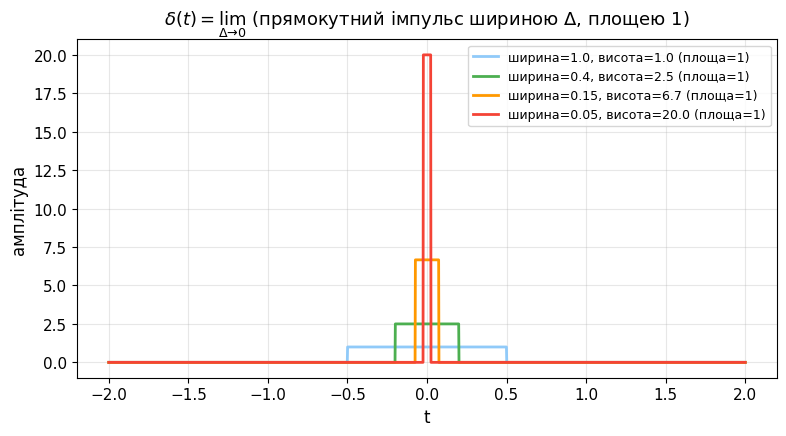

In [24]:
# Наближення дельта-функції прямокутними імпульсами дедалі меншої ширини (і більшої висоти, площа = 1)
fig, ax = plt.subplots(figsize=(8, 4.5))
t_d = np.linspace(-2, 2, 2000)
for width, color in [(1.0, '#90caf9'), (0.4, '#4CAF50'), (0.15, '#FF9800'), (0.05, '#F44336')]:
    height = 1/width
    y = np.where(np.abs(t_d) < width/2, height, 0)
    ax.plot(t_d, y, color=color, lw=2, label=f'ширина={width}, висота={height:.1f} (площа=1)')
ax.set_xlabel('t'); ax.set_ylabel('амплітуда')
ax.set_title(r'$\delta(t) = \lim_{\Delta\to0}$ (прямокутний імпульс шириною $\Delta$, площею 1)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


---
### ⚡ Практичне застосування: Функція Хевісайда і дельта-функція

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

- **Імпульсна характеристика кола (радіотехніки, фільтрів)** $h(t)$ — реакція системи саме на $\delta(t)$; за нею через інтеграл згортки повністю визначається реакція кола на будь-який вхідний сигнал.
- **Перетворення Лапласа/Фур'є одиничного стрибка й дельта-функції** — базові пари з таблиці перетворень (розділи вище): $\mathbf{1}(t)\to\dfrac1p$, $\delta(t)\to1$ — саме тому дельта-імпульс називають «універсальним тестовим сигналом»: його спектр рівномірний на всіх частотах.
- **Моделювання комутації** — множення сигналу на $\mathbf{1}(t-t_0)$ математично точно відповідає ідеальному ключу, що замикається в момент $t_0$ (див. розділ «Перехідні процеси» вище).

</div>

---
### ✅ Питання для самоперевірки: Радіотехнічні сигнали. Функція Хевісайда, дельта-функція

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чим енергетичний сигнал відрізняється від потужнісного?</summary>

> **Відповідь:** Енергетичний сигнал має скінченну енергію $E=\int|s(t)|^2dt<\infty$ і нульову середню потужність — типово одиночні (згасаючі) сигнали. Потужнісний сигнал має скінченну середню потужність, але нескінченну енергію — типово періодичні сигнали й стаціонарний шум.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> У чому полягає просіювальна властивість дельта-функції?</summary>

> **Відповідь:** $\int f(t)\delta(t-t_0)dt=f(t_0)$ — інтегрування добутку довільної функції на зсунуту дельта-функцію «вибирає» (просіює) значення цієї функції рівно в точці зсуву $t_0$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Як пов'язані функція Хевісайда і дельта-функція?</summary>

> **Відповідь:** Дельта-функція — узагальнена похідна функції Хевісайда: $\delta(t)=\dfrac{d}{dt}\mathbf{1}(t)$; і навпаки, функція Хевісайда — інтеграл дельта-функції від $-\infty$ до $t$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Навіщо потрібне динамічне (інтегральне) представлення сигналу через дельта-функції?</summary>

> **Відповідь:** Воно дозволяє звести реакцію лінійного кола на довільний сигнал до суми (інтеграла) реакцій на елементарні зсунуті імпульси — це і є інтеграл згортки (Дюамеля) через імпульсну характеристику кола $h(t)$, один із фундаментальних інструментів аналізу лінійних систем.

</details>

---
### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати, чому сигнали можна розглядати як вектори лінійного простору
> - Обчислювати енергію, норму та скалярний добуток сигналів
> - Перевіряти ортогональність двох сигналів
> - Пояснювати, чому ряд Фур'є — окремий випадок розкладу сигналу за ортогональним базисом


</div>


---
# Елементи функціонального аналізу <a class="anchor" id="functional-analysis"></a>

Функціональний аналіз відіграє важливу роль у розумінні властивостей лінійних просторів сигналів та їх взаємодії. В цьому тексті ми розглянемо основні елементи функціонального аналізу, такі як лінійний простір, нормований лінійний простір, скалярний добуток, ортогональні сигнали та концепція ортогонального базису.

## Лінійний простір та його властивості

Лінійний простір - це множина $ V $ над полем $ \mathbb{F} $, де визначені операції додавання та множення на скаляр. Він має наступні властивості:
- Комутативність: $ u + v = v + u, \forall u, v \in V $
- Асоціативність: $ (u + v) + w = u + (v + w), \forall u, v, w \in V $
- Існування нейтрального елемента: $ \exists 0 \in V : v + 0 = v, \forall v \in V $
- Існування оберненого елемента: $ \forall v \in V, \exists -v \in V : v + (-v) = 0 $

## Нормований лінійний простір сигналів

Нормований лінійний простір - це лінійний простір $ V $ над полем $ \mathbb{F} $, в якому визначено норму, тобто відображення $ \| \cdot \| : V \to \mathbb{R} $, що задовольняє наступні аксіоми норми:
- Невід'ємність: $ \|v\| \geq 0, \forall v \in V $ та $ \|v\| = 0 $ тільки якщо $ v = 0 $
- Однорідність: $ \|\alpha v\| = |\alpha| \|v\|, \forall v \in V, \alpha \in \mathbb{F} $
- Нерівність трикутника: $ \|u + v\| \leq \|u\| + \|v\|, \forall u, v \in V $

## Енергія та норма сигналу

Енергія сигналу $ x(t) $ визначається як

$$ E = \int_{-\infty}^{\infty} |x(t)|^2 dt $$

де $ |x(t)|^2 $ - це квадрат модуля сигналу. 

Норма сигналу в нормованому лінійному просторі визначається як

$$ \|x\| = \sqrt{E} $$

## Концепція метрики

Метрика вводиться в нормованому просторі для вимірювання відстані між двома елементами. 

Вона задовольняє такі властивості, як неузгодженість, симетричність та нерівність трикутника.

## Скалярний добуток сигналів та його властивості

Скалярний добуток в нормованому просторі сигналів визначається як
$ \langle x, y \rangle = \int_{-\infty}^{\infty} x(t)y(t) dt $
де $ x(t) $ та $ y(t) $ - це сигнали. Скалярний добуток має наступні властивості:

- Лінійність: $ \langle \alpha x_1 + \beta x_2, y \rangle = \alpha \langle x_1, y \rangle + \beta \langle x_2, y \rangle $

- Симетричність: $ \langle x, y \rangle = \overline{\langle y, x \rangle} $, де $ \overline{\langle y, x \rangle} $ - комплексно спряжений до $ \langle y, x \rangle $

## Ортогональні сигнали

Два сигнали $ x(t) $ та $ y(t) $ в нормованому просторі називаються ортогональними, якщо їх скалярний добуток дорівнює нулю, тобто
$ \langle x, y \rangle = 0 $

## Концепція ортогонального базису

Ортогональний базис - це система векторів, в якій кожні два різних вектори є ортогональними, а також кожен вектор є ненульовим. Ортогональні базиси знаходять широке застосування у сигнальній обробці та аналізі сигналів.

## Приклади ортогональних базисів

Одним з найпоширеніших прикладів ортогонального базису є система тригонометричних функцій, таких як синуси та косинуси, що використовуються в ряді Фур'є для представлення складних сигналів. Іншим прикладом є система власних функцій оператора, таких як власні функції диференціального оператора.

Цей огляд надає загальне уявлення про елементи функціонального аналізу, які є важливими для розуміння властивостей сигналів та їх обробки.


### ✅ Питання для самоперевірки: Функціональний аналіз

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому сигнали можна розглядати як вектори лінійного простору, а не лише як функції часу?</summary>

> **Відповідь:** Множина сигналів задовольняє аксіомам лінійного простору (замкненість щодо додавання й множення на скаляр, існування нульового елемента тощо), тому до неї застосовні геометричні поняття — норма, кут (ортогональність), проєкція — так само, як до звичайних векторів.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Що означає ортогональність двох сигналів фізично?</summary>

> **Відповідь:** $\langle x,y\rangle=0$ означає, що енергія суми сигналів дорівнює сумі їхніх енергій — «теорема Піфагора» для сигналів: $\|x+y\|^2 = \|x\|^2 + \|y\|^2$. Сигнали не «інтерферують» енергетично.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому саме тригонометричні функції обираються базисом для ряду Фур'є?</summary>

> **Відповідь:** Вони утворюють ортогональний базис на інтервалі періоду $T$, зручні аналітично (похідна й інтеграл синуса/косинуса — знову синус/косинус) і є власними функціями лінійних кіл: реакція лінійного кола на синусоїду залишається синусоїдою тієї ж частоти, що значно спрощує аналіз.

</details>


### 🎯 Мета вивчення розділу: Ряди Фур'є

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Формулювати умови розкладу сигналу в ряд Фур'є
> - Обчислювати коефіцієнти тригонометричного ряду Фур'є
> - Переходити між тригонометричною та комплексною формами
> - Будувати спектральні діаграми (амплітудний та фазовий спектри)
> - Застосовувати ДПФ для спектрального аналізу дискретних сигналів

</div>

### 📐 Форми запису ряду Фур'є

<div style="background-color: #f8fafc; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #475569; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Тригонометрична форма:**
$$s(t) = a_0 + \sum_{n=1}^{\infty}\left[a_n \cos(n\omega_1 t) + b_n \sin(n\omega_1 t)\right]$$

**Полярна (амплітудно-фазова) форма:**
$$s(t) = A_0 + \sum_{n=1}^{\infty} A_n \cos(n\omega_1 t + \varphi_n)$$

**Комплексна (експоненціальна) форма:**
$$s(t) = \sum_{n=-\infty}^{\infty} c_n e^{jn\omega_1 t}$$

</div>



---

# Ряди Фур'є <a class="anchor" id="Fourier_series"></a>

## Узагальнений ряд Фур'є <a class="anchor" id="Fourier_series_basic"></a>

Довільний сигнал $s(t)$ може бути представлений рядом 

$$ s(t) = \sum_{n=-\infty}^{\infty}U_{n}(t)C_{n} $$

де $C_{n}$ - коефіцієнти, що залежать від виду $s(t)$, а $u_{n}$ - $n$-та функція обраного базису $\{u_{n}(t)\}$ , причому базисні функції на інтервалі ортогональності повинні мати властивості: 

1. ортогональності $$ \int_{a}^{b}u_{n}(t)u_{k}(t)dt = 0 $$, за умови $n \neq k $, $[a,b]$ - інтервал ортогональності. 

2. скінченності енергії: $$\int_{a}^{b}u_{n}^{2}(t)dt \neq 0 $$. Величина цієї енергії називається квадратом норми:

$$  \int_{a}^{b}u_{n}^{2}(t)dt  =  || u(t)_{n}||^{2}  $$

Коефіцієнти узагальненого ряду Фур'є визначаються за формулою: 

$$ C_{n} = \cfrac{1}{ || u(t)_{n}||^{2}  } \int_{a}^{b}s(t)u_{n}(t)dt $$

Якщо набір базисних функцій містить комплексні функції, то властивості відображаються таким чином:

$$ \int_{a}^{b}u_{n}(t)u_{k}^{\bullet}(t)dt = 0 $$ для $n \neq k$;

 тут $u_{k}^{\bullet}(t)$ - функція, комплексно спряжена $u_{k}(t)$;
 
$$ \int_{a}^{b}u_{n}(t)u_{k}^{\bullet}(t)dt \neq 0 $$

, а комплексні коефіцієнти ряду визначаються співвідношенням: 

$$ C_{n} = \cfrac{1}{ || u(t)_{n}||^{2}  } \int_{a}^{b}s(t)u_{n}^{+}(t)dt $$



**Енергія сигналу, представленого узагальненим рядом Фур'є.** Оскільки базисні функції ортогональні, енергія сигналу (за узагальненою теоремою Піфагора) дорівнює сумі енергій, внесених кожною складовою окремо — «перехресні» доданки при інтегруванні добутку різних $u_n(t)$ зникають:

$$E = \int_a^b |s(t)|^2\,dt = \sum_{n} |C_n|^2\,\|u_n(t)\|^2$$

Якщо базис ще й **нормований** ($\|u_n(t)\|=1$), формула спрощується до $E=\sum_n|C_n|^2$ — саме такий вигляд має теорема Парсеваля для ряду й перетворення Фур'є, наведена нижче.

### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Жан-Батіст Фур'є розробив свою теорію у **1807 році**, досліджуючи не електричні сигнали, а розповсюдження **тепла** у твердих тілах — в оригінальній роботі йдеться саме про «теплові ряди». Ідея, що будь-яку (навіть розривну) функцію можна подати сумою синусоїд, на той час здалася математикам настільки неймовірною, що Лагранж особисто заперечував публікацію статті. Сьогодні саме цей принцип лежить в основі радіомовлення, амплітудної й частотної модуляції, стиснення JPEG/MP3 та цифрової обробки сигналів загалом.


</div>


In [25]:
# Інтерактивна візуалізація ряду Фур'є: наближення прямокутного сигналу
def fourier_series_interactive(N_terms=5, T=2.0, A=1.0, duty=0.5):
    """Ряд Фур'є для прямокутного сигналу (меандру)"""
    t = np.linspace(0, 2*T, 1000)
    # Ideal square wave
    f_ideal = np.where((t % T) < duty * T, A, 0.0)

    # Fourier series approximation (odd harmonics for 50% duty)
    f_approx = np.zeros_like(t)
    omega0 = 2 * np.pi / T
    coeffs = []
    freqs = []
    for n in range(1, N_terms * 2 + 1):
        bn = (2 * A / (n * np.pi)) * np.sin(n * np.pi * duty)  # Fourier coefficient
        f_approx += bn * np.sin(n * omega0 * t)
        coeffs.append(abs(bn))
        freqs.append(n)
    a0 = A * duty
    f_approx += a0

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(t, f_ideal, 'k--', lw=1.5, label='Ідеальний')
    axes[0].plot(t, f_approx, '#2196F3', lw=2, label=f'N={N_terms} гармонік')
    axes[0].set_xlabel('Час, с'); axes[0].set_ylabel('Амплітуда')
    axes[0].set_title(f'Наближення ряду Фур\'є (N={N_terms})')
    axes[0].legend()

    # Spectrum (amplitude)
    axes[1].bar(freqs, coeffs, color='#4CAF50', edgecolor='k', width=0.6)
    axes[1].set_xlabel('Номер гармоніки n'); axes[1].set_ylabel('|C_n|')
    axes[1].set_title('Амплітудний спектр')

    # Error vs N
    ns = range(1, 20)
    errors = []
    for n_test in ns:
        fa = np.ones_like(t) * A * duty
        for k in range(1, n_test * 2 + 1):
            bk = (2 * A / (k * np.pi)) * np.sin(k * np.pi * duty)
            fa += bk * np.sin(k * omega0 * t)
        errors.append(np.sqrt(np.mean((f_ideal - fa)**2)))
    axes[2].plot(list(ns), errors, '#FF9800', marker='o', ms=5)
    axes[2].axvline(N_terms, color='red', ls='--')
    axes[2].set_xlabel('Кількість гармонік N')
    axes[2].set_ylabel('RMS помилка')
    axes[2].set_title('Збіжність ряду Фур\'є')

    plt.suptitle(f'Ряд Фур\'є: прямокутний сигнал, T={T}с, A={A}, D={duty*100:.0f}%',
                 fontsize=11)
    plt.tight_layout(); plt.show()
    rms_err = np.sqrt(np.mean((f_ideal - f_approx)**2))
    print(f'RMS похибка при N={N_terms}: {rms_err:.4f}')
    print(f'Нульова гармоніка (постійна складова): a0 = {a0:.4f}')
    print(f'Перша гармоніка: b1 = {(2*A/np.pi)*np.sin(np.pi*duty):.4f}')

interact(fourier_series_interactive,
         N_terms=widgets.IntSlider(min=1, max=30, step=1, value=5, description='N гармонік'),
         T=widgets.FloatSlider(min=0.5, max=5, step=0.5, value=2.0, description='T (с)'),
         A=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1.0, description='Амплітуда'),
         duty=widgets.FloatSlider(min=0.1, max=0.9, step=0.05, value=0.5, description='Шпаруватість'))

interactive(children=(IntSlider(value=5, description='N гармонік', max=30, min=1), FloatSlider(value=2.0, desc…

<function __main__.fourier_series_interactive(N_terms=5, T=2.0, A=1.0, duty=0.5)>

---
### ⚡ Практичне застосування: Ряди та перетворення Фур'є

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Спектральний аналіз у радіотехніці:**

| Застосування | Опис |
|-------------|------|
| **Аналіз модульованих сигналів (AM/FM)** | Спектр АМ-сигналу: несуча + дві бічних смуги |
| **Аналіз гармонічних спотворень (THD)** | $\text{THD} = \sqrt{\sum_{n=2}^N C_n^2}/C_1$ — відношення вищих гармонік до основної |
| **Цифрова обробка сигналів (DSP)** | Швидке перетворення Фур'є (FFT) — основа спектроаналізаторів |
| **Синтез сигналів (DDS)** | Прямий цифровий синтез: таблиця синусів + ряд Фур'є |
| **Фільтрація сигналів** | Множення спектрів у частотній області = згортка у часовій |

**Теорема відліків Котельникова (Найквіста–Шеннона):**
$$f_s \geq 2 f_{max}$$
Мінімальна частота дискретизації вдвічі більша за максимальну частоту в спектрі сигналу.

> **Ефект Гіббса:** При обриві ряду Фур'є на N-й гармоніці поблизу стрибків функції виникають пульсації ~9% від величини стрибка. Не зникають зі збільшенням N, але стають вужчими.

</div>

### Тригонометричний ряд Фур'є  <a class="anchor" id="Fourier_series_trig"></a>

Нехай є періодичний сигнал із періодом $Т$ тобто 

$$ s(t) = s(t+T)$$

Для тригонометричного ряду Фур'є набір базисних функцій має вигляд: 

$$
\{ u(t)_{n}\} = 
\begin{bmatrix}
1 & cos(\omega_{1}t) & cos(2\omega_{1}t) & cos(3\omega_{1}t) & ... & cos(n\omega_{1}t) \\
  & sin(\omega_{1}t) & sin(2\omega_{1}t) & sin(3\omega_{1}t) & ... & sin(n\omega_{1}t) \\
\end{bmatrix}
$$
 
де 
- $\omega_{1} = \cfrac{2\pi}{T}$; $f_{1} = \cfrac{1}{T}$ частота першої гармоніки; 

Частоти $n \cdot \omega_{1}$ або $n \cdot f_{1}$ - частоти вищих гармонійних складових. 

Інтервал ортогональності в цьому випадку дорівнює $Т$. Тригонометричні функції кратних аргументів ортогональні одна одній. 

Квадрат норми базисної функції $u(t)_{0}=1$ дорівнює: 

$$ || u_{0}(t)dt||^{2} = \int_{0}^{T}1^{2}dt = T $$

Квадрат норми для базисних функцій $u_{n}(t)=cos(n \omega_{1} t)$ при $(n \neq 0)$ дорівнює: 

$$ || u(t)_{n}dt||^{2} = \int_{0}^{T}  cos^{2}(n \omega_{1} t) dt = \cfrac{T}{2} $$

Квадрат норми для функцій $u_{n}(t)=sin(n \omega_{1} t)$ при $(n \neq 0)$ дорівнює. 

$$ || u(t)_{n}dt||^{2} = \int_{0}^{T}  sin^{2}(n \omega_{1} t) dt = \cfrac{T}{2} $$
 
Таким чином, коефіцієнти ряду визначаються як:

> $$ C_{0} = a_{0} = \cfrac{1}{T} \cdot \int_{0}^{T}  s(t) \cdot 1 dt $$
> 
> $$ C_{0}^{cos} = a_{n} = \cfrac{2}{T} \cdot \int_{0}^{T}  s(t) \cdot cos(n \omega_{1} t) dt $$
> 
> $$ C_{0}^{sin} = b_{n} = \cfrac{2}{T} \cdot \int_{0}^{T}  s(t) \cdot sin(n \omega_{1} t) dt $$

Тригонометричний ряд Фур'є матиме вигляд: 

 $$
 s(t) = a_{0} + a_{1}\cdot cos(1 \omega_{1} t) + a_{2}\cdot cos(2 \omega_{1} t) + ... + a_{n}\cdot cos(n \omega_{1} t) \newline
 + b_{1}\cdot sin(1 \omega_{1} t) + b_{2}\cdot sin(2 \omega_{1} t) + ... + b_{n}\cdot sin(n \omega_{1} t) \\
 $$

> $$ s(t) = a_{0} + \sum_{n=1}^{\infty} a_{n}\cdot cos(n \omega_{1} t) + b_{n}\cdot sin(n \omega_{1} t) $$



### Тригонометричний ряд Фур'є з полярними координатами  <a class="anchor" id="Fourier_series_polar"></a>

Перетворимо кожну пару з однаковими частотами: 

$$ a_{n}\cdot cos(n \omega_{1} t) + b_{n}\cdot sin(n \omega_{1} t) =  A_{n} \cdot cos(n \omega_{1} t - \alpha_{n})$$

Дійсно:

$$A_{n} \cdot cos(n \omega_{1} t - \alpha_{n}) =   A_{n} \cdot cos(\alpha_{n}) \cdot cos(n \omega_{1} t) + A_{n} \cdot sin(\alpha_{n})\cdot sin(n \omega_{1} t) $$

Таким чином:

$$A_{n} = \sqrt{a_{n}^{2} + b_{n}^{2}}$$

$$\alpha_{n} = arctg \cfrac{b_{n}}{a_{n}}$$

Величину $a_{0}$ можна виразити через загальну формулу для $cos(n \omega_{1} t)$ при $n=0$, тоді $a_{0} = \cfrac{A_{0}}{2}$. 

Позначивши $$ \varphi_{n} = - \alpha_{n} $$, отримуємо відому форму запису тригонометричного ряду Фур'є: 

> $$ s(t) = a_{0} + \sum_{n=1}^{\infty} A_{n} cos(n \omega_{1}t+\varphi_{n}) $$

Для парних функцій $s(t)$ усі непарні члени ряду дорівнюють 0, тобто $b_{n}=0$, отже:

$$A_{n} = a_{n}$$

$$\alpha_{n} = 0$$

Для непарних функцій, усі парні члени ряду дорівнюють 0, тобто всі a_{n}, зокрема й $a_{0}$ дорівнюють 0, отже:

$$A_{n} = b_{n}$$

$$\alpha_{n} = - \cfrac{\pi}{2}$$

Часова інтерпретація тригонометричного ряду Фур'є показана на риcунку. 

Складаючи в кожен момент часу миттєві значення всіх гармонік, отримуємо миттєве значення самого сигналу в цей момент часу. 
 
Знаходження частот, амплітуд і фаз складових сигналу називається **спектральним аналізом**. 

Отримання сигналу за заданими коефіцієнтами $ A_{n} $, фазами $ \varphi_{n} $, і частотами $n\omega_{1}$ називається **синтезом сигналів**. Складаючи обмежену кількість гармонік, отримуємо сигнал, відмінний від того, для якого розраховувалися амплітуди і фази гармонік. 

### Спектральна діаграма <a class="anchor" id="spectral-diagram"></a>

**Спектральною діаграмою** називають графічне представлення набору амплітуд $A_n$ (амплітудна спектральна діаграма) і фаз $\varphi_n$ (фазова спектральна діаграма) гармонік сигналу як функцій частоти $n\omega_1$ — у вигляді окремих вертикальних ліній (ліній спектру) на відповідних частотах, а не неперервної кривої, оскільки спектр періодичного сигналу **дискретний**.


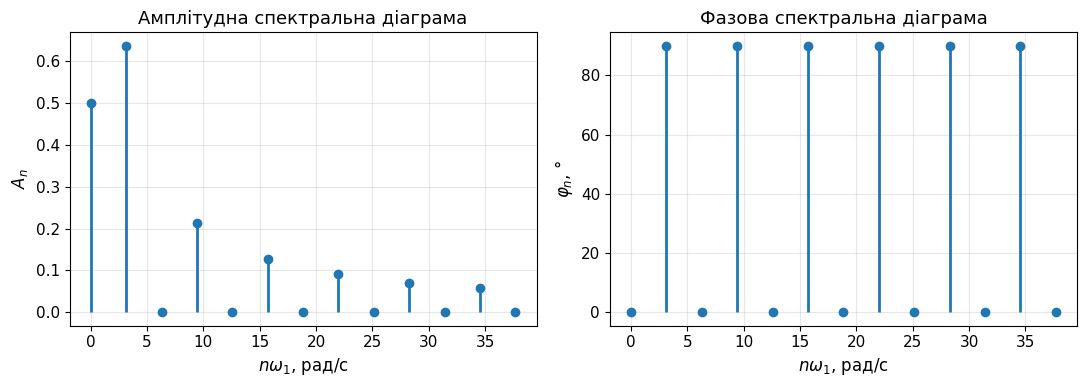

In [26]:
# Спектральна діаграма прямокутного (меандрового) сигналу: амплітудний і фазовий спектри
A_sd, T_sd, duty_sd, N_sd = 1.0, 2.0, 0.5, 12
w1_sd = 2*np.pi/T_sd

ns = np.arange(0, N_sd+1)
An = np.zeros(len(ns)); phin = np.zeros(len(ns))
An[0] = A_sd*duty_sd
for k in ns[1:]:
    an = (A_sd/(k*np.pi))*np.sin(2*np.pi*k*duty_sd)
    bn = (A_sd/(k*np.pi))*(1-np.cos(2*np.pi*k*duty_sd))
    An[k] = np.sqrt(an**2+bn**2)
    phin[k] = np.arctan2(bn, an) if An[k] > 1e-12 else 0.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.stem(ns*w1_sd, An, basefmt=' ')
ax1.set_xlabel(r'$n\omega_1$, рад/с'); ax1.set_ylabel('$A_n$')
ax1.set_title('Амплітудна спектральна діаграма')

ax2.stem(ns*w1_sd, np.degrees(phin), basefmt=' ')
ax2.set_xlabel(r'$n\omega_1$, рад/с'); ax2.set_ylabel(r'$\varphi_n$, °')
ax2.set_title('Фазова спектральна діаграма')
plt.tight_layout(); plt.show()


### Комплексна форма ряду Фур'є  <a class="anchor" id="Fourier_series_complex"></a>

Довільну **періодичну функцію** з періодом $T$ можна наблизити довільно точно за допомогою суми комплексних експонент (формула Ейлера):

$$S_N(t) = \sum_{n=-N}^{N} c_n \exp\left( \frac{j 2\pi n t}{T}\right)$$

де **комплексні коефіцієнти Фур'є** $c_n$ визначаються як:

$$c_n = \frac{1}{T} \int_{t_0}^{t_0 + T} f(t) \exp\left( \frac{-j 2\pi n t}{T}\right) dt$$

**Зв'язок з тригонометричними коефіцієнтами:**

$$c_n = \frac{a_n - jb_n}{2}, \quad c_{-n} = \frac{a_n + jb_n}{2}, \quad c_0 = a_0$$

**Двостороннє амплітудно-частотне:** $|c_n| = \frac{1}{2}\sqrt{a_n^2 + b_n^2} = \frac{A_n}{2}$

**Фазово-частотне:** $\angle c_n = -\arctan\frac{b_n}{a_n} = \varphi_n$


### Приклад розрахунку тригонометричного ряду Фурьє  <a class="anchor" id="Fourier_series_trig_example"></a>

4.0*cos(pi*t)/pi**2 + 0.444444444444444*cos(3*pi*t)/pi**2 + 0.16*cos(5*pi*t)/pi**2 + 0.5


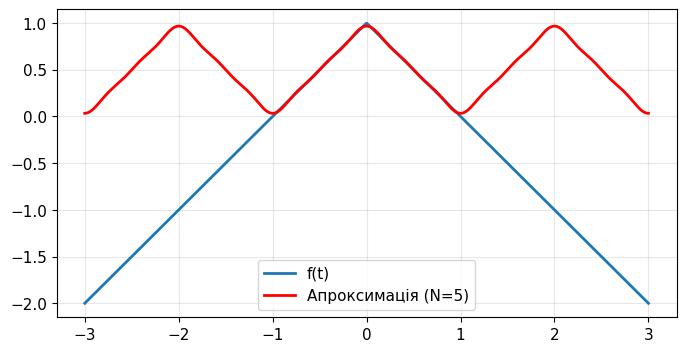

In [27]:
import sympy as smp
i2pi = smp.I*2*smp.pi
exp = smp.exp

def f(t):
    #return -t+smp.Heaviside(t)*t
    #return smp.sin(t)+smp.sin(2*t)+smp.cos(2*t)
    #return (1+1*t) - smp.Heaviside(t)*(1+1*t)  + smp.Heaviside(t)*(1-1*t) 
    return (1+1*t) + smp.Heaviside(t)*(0-2*t) 

    #return -t+smp.Heaviside(t)*t




def a0():
    return 1/T*smp.integrate(
        f(t),
        (t, t0, t0 + T))

def a(n):
    return 2/T*smp.integrate(
        f(t)*smp.cos(2*smp.pi*n*t/T),
        (t, t0, t0 + T))

def b(n):
    return 2/T*smp.integrate(
        f(t)*smp.sin(2*smp.pi*n*t/T),
        (t, t0, t0 + T))

def S(N):
    return a0()+sum( a(n)*smp.cos(n*t*2*smp.pi/T)+b(n)*smp.sin(n*t*2*smp.pi/T) for n in range(1, N+1)).expand(complex=True).simplify()
        
T = 2
t0 = -1

t = smp.Symbol('t', real=True)

N = 5

analytic_approx = S(N).expand()
print(analytic_approx)

interval = (t, t0-T, t0+2*T)

### Тригонометричний ряд Фур'є
t_vals = np.linspace(float(interval[1]), float(interval[2]), 1000)
f_vals = (1 + t_vals) + np.heaviside(t_vals, 0.5) * (0 - 2 * t_vals)
approx_func = smp.lambdify(t, analytic_approx, 'numpy')
approx_vals = approx_func(t_vals)

plt.figure(figsize=(8, 4))
plt.plot(t_vals, f_vals, label='f(t)')
plt.plot(t_vals, approx_vals, color='red', label=f'Апроксимація (N={N})')
plt.legend()
plt.show()

---
## Пряме та зворотне перетворення Фур'є <a class="anchor" id="fourier-transform-direct-inverse"></a>

Ряд Фур'є придатний лише для **періодичних** сигналів. Щоб поширити спектральне представлення на **неперіодичний** (одиночний) сигнал, розглядають граничний перехід $T\to\infty$: період прямує до нескінченності, відстань між сусідніми гармоніками $\omega_1=2\pi/T\to0$, дискретний набір частот $n\omega_1$ стає неперервною змінною $\omega$, а сума в комплексному ряді Фур'є переходить в інтеграл. У результаті отримують пару **перетворень Фур'є**:

**Пряме перетворення Фур'є** (від оригіналу $f(t)$ до спектральної густини $F(j\omega)$):
$$F(j\omega) = \int_{-\infty}^{\infty} f(t)\,e^{-j\omega t}\,dt$$

**Обернене (зворотне) перетворення Фур'є** (відновлення оригіналу зі спектра):
$$f(t) = \frac{1}{2\pi}\int_{-\infty}^{\infty} F(j\omega)\,e^{j\omega t}\,d\omega$$

Умова існування (**достатня**): сигнал абсолютно інтегрований, $\int_{-\infty}^{\infty}|f(t)|\,dt<\infty$ (та умови Діріхле на кожному скінченному інтервалі). $F(j\omega)$ у загальному випадку — комплексна функція: $F(j\omega)=|F(j\omega)|\,e^{j\theta(\omega)}$, де $|F(j\omega)|$ — (неперервний) амплітудний спектр, $\theta(\omega)$ — фазовий спектр.

### Основні властивості перетворення Фур'є <a class="anchor" id="fourier-transform-properties"></a>

| Властивість | Часова область | Частотна область |
|-------------|-----------------|--------------------|
| Лінійність | $a f_1(t)+b f_2(t)$ | $aF_1(j\omega)+bF_2(j\omega)$ |
| Зсув у часі (затримка) | $f(t-t_0)$ | $F(j\omega)\,e^{-j\omega t_0}$ |
| Зсув за частотою (модуляція) | $f(t)\,e^{j\omega_0 t}$ | $F(j(\omega-\omega_0))$ |
| Масштабування | $f(at)$ | $\dfrac{1}{|a|}F\!\left(j\dfrac{\omega}{a}\right)$ |
| Диференціювання | $\dfrac{d f}{dt}$ | $j\omega F(j\omega)$ |
| Інтегрування | $\displaystyle\int_{-\infty}^t f(\tau)d\tau$ | $\dfrac{F(j\omega)}{j\omega}$ (+ доданок з $\delta(\omega)$, якщо $F(0)\neq0$) |
| Згортка в часі | $f_1(t)*f_2(t)$ | $F_1(j\omega)\cdot F_2(j\omega)$ |
| Добуток у часі (дуальність згортки) | $f_1(t)\cdot f_2(t)$ | $\dfrac{1}{2\pi}F_1(j\omega)*F_2(j\omega)$ |
| Симетрія для дійсного $f(t)$ | $f(t)\in\mathbb{R}$ | $F(-j\omega)=F^{*}(j\omega)$ (парний модуль, непарна фаза) |

**Властивість згортки** — ключова для теорії кіл: реакція лінійного кола на вхідний сигнал є згорткою вхідного сигналу з імпульсною характеристикою $y(t)=s(t)*h(t)$ (див. розділ «Динамічне представлення сигналів» вище), тому в частотній області це просто **множення спектрів**: $Y(j\omega)=S(j\omega)H(j\omega)$, де $H(j\omega)$ — частотна характеристика кола.

### Формула Релея <a class="anchor" id="rayleigh-formula"></a>

**Формула (теорема) Релея** — енергетичний аналог теореми Парсеваля для неперіодичних сигналів: повна енергія сигналу, обчислена в часовій області, дорівнює енергії, обчисленій за його спектром:

$$E = \int_{-\infty}^{\infty}|f(t)|^2\,dt = \frac{1}{2\pi}\int_{-\infty}^{\infty}|F(j\omega)|^2\,d\omega$$

Величину $W(\omega)=|F(j\omega)|^2$ називають **спектральною густиною енергії** — вона показує, як енергія сигналу розподілена за частотою (детальніше — у розділі «Взаємна спектральна густина. Енергетичний спектр» нижче).


f(t) = 1.0 В при |t|<0.25 с (прямокутний імпульс)
Енергія в часовій області:      E = A^2*tau       = 0.500000 Дж (на 1 Ом)
Енергія за спектром (формула Релея): E = (1/2π)∫|F|^2 dω = 0.498415 Дж (на 1 Ом)
Збіг підтверджує формулу Релея.


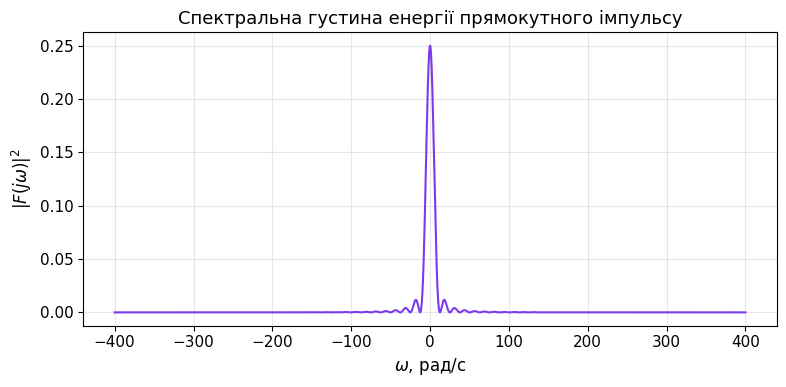

In [28]:
# Перевірка формули Релея на прикладі прямокутного відеоімпульсу
A_r, tau_r = 1.0, 0.5   # амплітуда і тривалість імпульсу f(t) = A, |t|<tau/2

E_time = A_r**2 * tau_r   # енергія в часовій області: інтеграл A^2 на інтервалі tau

w_r = np.linspace(-400, 400, 200000)
F_w = A_r*tau_r*np.sinc(w_r*tau_r/(2*np.pi))   # F(jw) = A*tau*sinc(w*tau/2), np.sinc(x)=sin(pi x)/(pi x)
E_freq = np.trapezoid(np.abs(F_w)**2, w_r) / (2*np.pi)

print(f'f(t) = {A_r} В при |t|<{tau_r/2} с (прямокутний імпульс)')
print(f'Енергія в часовій області:      E = A^2*tau       = {E_time:.6f} Дж (на 1 Ом)')
print(f'Енергія за спектром (формула Релея): E = (1/2π)∫|F|^2 dω = {E_freq:.6f} Дж (на 1 Ом)')
print('Збіг підтверджує формулу Релея.')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(w_r, np.abs(F_w)**2, color='#7c3aed', lw=1.5)
ax.set_xlabel(r'$\omega$, рад/с'); ax.set_ylabel(r'$|F(j\omega)|^2$')
ax.set_title('Спектральна густина енергії прямокутного імпульсу')
plt.tight_layout(); plt.show()


### Приклад розрахунку перетворення Фурьє  <a class="anchor" id="Fourier_series_polar_example"></a>

2*sin(t) - sin(2*t) + 2*sin(3*t)/3 - sin(4*t)/2 + 2*sin(5*t)/5


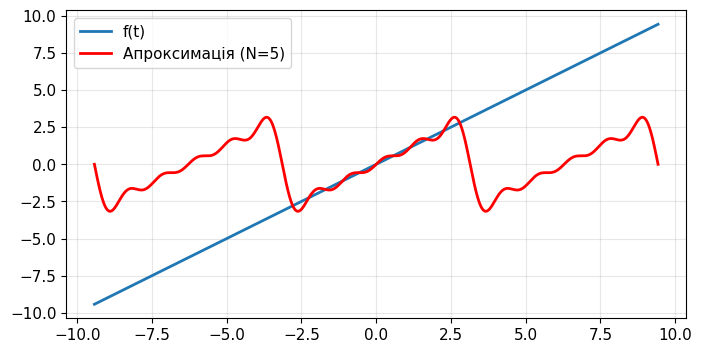

In [29]:
import sympy
i2pi = sympy.I*2*sympy.pi
exp = sympy.exp

def f(t):
    return t

def c(n):
    return (sympy.integrate(
               f(t)*exp((-i2pi * n * t)/P),
               (t, t0, t0 + P))/P)    
def S(N):
    return sum(c(n)*exp(i2pi*n*t/P) for n in range(-N, N+1)).expand(complex=True).simplify()
    
a = sympy.Symbol('a', positive=True)

P = 2*sympy.pi
t0 = -sympy.pi

t = sympy.Symbol('t', real=True)

N = 5

analytic_approx = S(N).expand()
print(analytic_approx)

interval = (t, t0-P, t0+2*P)
t_vals = np.linspace(float(interval[1]), float(interval[2]), 1000)
f_vals = t_vals
approx_func = sympy.lambdify(t, analytic_approx, 'numpy')
approx_vals = approx_func(t_vals)

plt.figure(figsize=(8, 4))
plt.plot(t_vals, f_vals, label='f(t)')
plt.plot(t_vals, approx_vals, color='red', label=f'Апроксимація (N={N})')
plt.legend()
plt.show()

### Приклад використання дискретного перетворення Фурьє для отримання спектру сигналу з мікрофона   <a class="anchor" id="Fourier_transform_discrete_microphone"></a>

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd

# Define parameters
duration = 5  # seconds
sample_rate = 44100  # Hz

# Function to capture audio
def capture_audio(duration, sample_rate):
    print("Recording...")
    audio_data = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1, dtype='float64')
    sd.wait()
    print("Recording stopped.")
    return audio_data.flatten()

# Function to compute Fourier transform
def compute_fft(audio_data, sample_rate):
    n = len(audio_data)
    freqs = np.fft.fftfreq(n, d=1/sample_rate)
    fft_vals = np.abs(np.fft.fft(audio_data))
    return freqs[:n//2], fft_vals[:n//2]

# Function to plot spectrum with limited frequency range
def plot_spectrum(freqs, fft_vals, max_freq=1200):
    plt.figure(figsize=(10, 4))
    plt.plot([262, 262], [0, 400], 'r') # plotting t, b separately 
    plt.text(262, 200, r'$\leftarrow$ Нота С 1 октава', fontsize = 10)
    plt.plot([524, 524], [0, 400], 'r') # plotting t, b separately 
    plt.text(524, 200, r'$\leftarrow$ Нота С 2 октава', fontsize = 10)
    plt.plot(freqs, fft_vals)
    plt.title('Спектр сигналу')
    plt.xlabel('Частота, [Гц]')
    plt.ylabel('Амплітуда')
    plt.grid(True)
    plt.xlim(0, max_freq)  # Limit x-axis from 0 to max_freq Hz
    plt.show()

# Function to handle button click event
def on_button_clicked(b):
    audio_data = capture_audio(duration, sample_rate)
    freqs, fft_vals = compute_fft(audio_data, sample_rate)
    plot_spectrum(freqs, fft_vals)

# Create button widget
button = widgets.Button(description="Почати запис")
button.on_click(on_button_clicked)

# Display button
display(button)


ModuleNotFoundError: No module named 'sounddevice'

In [31]:
audio_data = capture_audio(duration, sample_rate)
freqs, fft_vals = compute_fft(audio_data, sample_rate)
plot_spectrum(freqs, fft_vals)

NameError: name 'capture_audio' is not defined

---
### ✅ Питання для самоперевірки: Ряди та перетворення Фур'є

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Яка умова існування ряду Фур'є для функції f(t)?</summary>

> **Відповідь:** Умови Діріхле: f(t) — обмежена, має скінченну кількість максимумів, мінімумів і точок розриву 1-го роду на кожному обмеженому інтервалі. На практиці всі фізично реальні сигнали задовольняють ці умови.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому спектр парної функції містить лише косинусні складові?</summary>

> **Відповідь:** Для парної $f(t) = f(-t)$ всі коефіцієнти $b_n = 0$, оскільки $b_n = \frac{2}{T}\int_0^T f(t)\sin(n\omega_0 t)dt = 0$ (добуток парної та непарної функцій — непарна, інтеграл по симетричному відрізку = 0).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Що таке теорема Парсеваля і як вона пов'язана з енергією сигналу?</summary>

> **Відповідь:** $\frac{1}{T}\int_0^T |f(t)|^2 dt = \sum_{n=-\infty}^{\infty} |C_n|^2$ — потужність сигналу дорівнює сумі квадратів модулів комплексних коефіцієнтів Фур'є. Кожна гармоніка вносить незалежний внесок у потужність.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4 (поглиблений).</b> Яка різниця між рядом Фур'є та перетворенням Фур'є?</summary>

> **Відповідь:** Ряд Фур'є — для **періодичних** сигналів, дає дискретний спектр із гармонічними складовими. Перетворення Фур'є — для **неперіодичних** (або одиночних) сигналів, дає неперервний спектр $F(\omega) = \int_{-\infty}^{\infty} f(t) e^{-j\omega t} dt$.

</details>

---

## Кореляційний аналіз та модуляція сигналів <a class="anchor" id="correlation-modulation"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Обчислювати енергетичний спектр і взаємну спектральну густину сигналів
> - Пояснювати фізичний зміст автокореляційної та взаємокореляційної функцій та їх властивості
> - Записувати спектр і енергетичні характеристики АМ, балансної, однополосної, ЧМ та ФМ модуляції
> - Формулювати теорему Котельникова і будувати ряд Котельникова для сигналу з обмеженим спектром

</div>

### Взаємна спектральна густина сигналів. Енергетичний спектр <a class="anchor" id="cross-spectral-density"></a>

За формулою Релея (розділ вище) величина $W(\omega)=|F(j\omega)|^2$ — **енергетичний спектр** (спектральна густина енергії) сигналу $f(t)$: вона показує розподіл енергії сигналу за частотою, причому $W(\omega)\ge0$ і $W(-\omega)=W(\omega)$ (парна функція для дійсного сигналу).

Для **двох** сигналів $x(t)$ і $y(t)$ зі спектрами $X(j\omega)$, $Y(j\omega)$ вводять **взаємну спектральну густину**:

$$W_{xy}(\omega) = X(j\omega)\,Y^{*}(j\omega)$$

На відміну від енергетичного спектра одного сигналу, $W_{xy}(\omega)$ — комплексна і, взагалі кажучи, не парна функція; вона показує, наскільки узгоджено два сигнали змінюються на кожній частоті. Нижче показано, що взаємна спектральна густина й кореляційна функція двох сигналів пов'язані перетворенням Фур'є (теорема Вінера–Хінчина) — так само, як енергетичний спектр пов'язаний з автокореляційною функцією.


### Кореляційний аналіз сигналів. Порівняння сигналів, зсунутих у часі <a class="anchor" id="correlation-analysis"></a>

**Кореляційний аналіз** дає кількісну міру **схожості** двох сигналів — або одного сигналу з власною зсунутою в часі копією — залежно від величини зсуву $\tau$. Для сигналів зі скінченною енергією вводять **кореляційний інтеграл**:

$$R_{xy}(\tau) = \int_{-\infty}^{\infty} x(t)\,y(t+\tau)\,dt$$

Чим більше значення $|R_{xy}(\tau)|$ при деякому $\tau$, тим краще $x(t)$ узгоджується з $y(t)$, зсунутим саме на цей інтервал часу. Максимум кореляційної функції за $\tau$ вказує **найкращий момент вирівнювання (затримку)** між сигналами — на цьому й ґрунтується виявлення сигналів на тлі завад, вимірювання відстані (радіолокація, гідролокація) та синхронізація в цифровому зв'язку.


### Автокореляційна функція сигналу та її властивості <a class="anchor" id="autocorrelation"></a>

**Автокореляційна функція (АКФ)** — окремий випадок кореляційного інтеграла, коли другий сигнал — це той самий $x(t)$:

$$R_x(\tau) = \int_{-\infty}^{\infty} x(t)\,x(t+\tau)\,dt$$

**Властивості АКФ:**

| Властивість | Формулювання |
|-------------|--------------|
| Максимум при $\tau=0$ | $R_x(0) = \displaystyle\int|x(t)|^2dt = E$ (енергія сигналу), і $R_x(\tau)\le R_x(0)\;\forall\tau$ |
| Парність | $R_x(-\tau)=R_x(\tau)$ для дійсного $x(t)$ |
| Згасання | Для сигналів без періодичної складової $R_x(\tau)\to0$ при $\tau\to\infty$ (декореляція) |
| Теорема Вінера–Хінчина | $R_x(\tau)$ і енергетичний спектр $W(\omega)=|X(j\omega)|^2$ пов'язані перетворенням Фур'є: $W(\omega)=\displaystyle\int_{-\infty}^{\infty}R_x(\tau)e^{-j\omega\tau}d\tau$ |

Отже, АКФ і енергетичний спектр несуть еквівалентну інформацію про сигнал, лише в різних (часовій і частотній) областях.


### Взаємокореляційна функція двох сигналів та її властивості <a class="anchor" id="cross-correlation"></a>

**Взаємокореляційна функція (ВКФ)** — загальний випадок $R_{xy}(\tau)$ для двох **різних** сигналів. Властивості:

- **Несиметрична відносно перестановки:** $R_{xy}(\tau) = R_{yx}(-\tau)$ (на відміну від АКФ, взагалі не парна функція).
- **Нерівність Коші–Буняковського:** $|R_{xy}(\tau)| \le \sqrt{R_x(0)\,R_y(0)}$ — ВКФ обмежена «геометричним середнім» енергій обох сигналів.
- Положення максимуму $\tau_{max}=\arg\max_\tau|R_{xy}(\tau)|$ дає оцінку **затримки** одного сигналу відносно іншого — принцип роботи **узгодженого фільтра (matched filter)**: кореляція прийнятого сигналу з еталонним (опорним) сигналом виявляє його на тлі шуму й визначає затримку (наприклад, час поширення сигналу радара до цілі й назад).


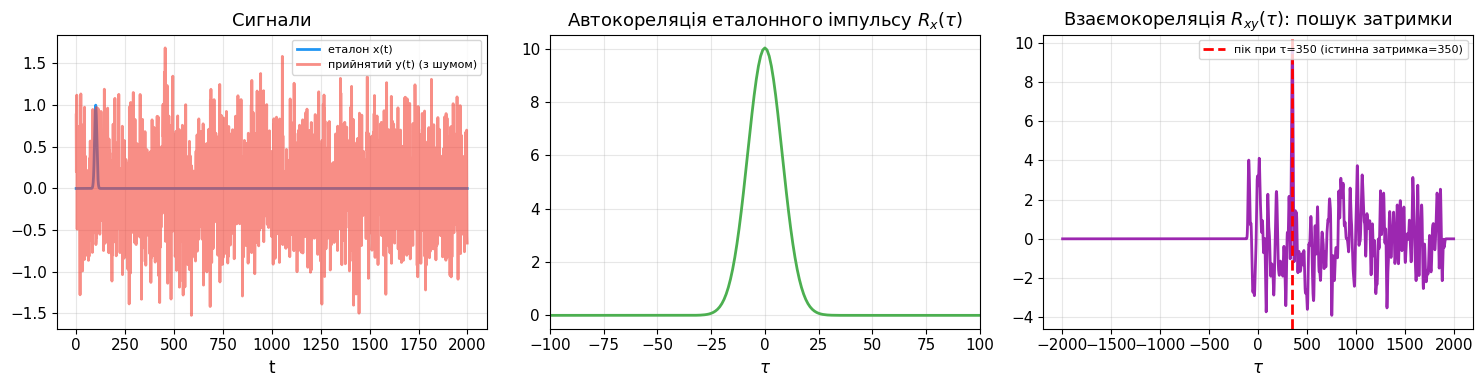

Істинна затримка: 350. Затримка, знайдена за максимумом ВКФ: 350.


In [32]:
# Демонстрація АКФ і ВКФ: виявлення затримки сигналу на тлі шуму методом кореляції
np.random.seed(0)
N_c = 2000
t_c = np.arange(N_c)
pulse = np.exp(-((t_c-100)/8.0)**2)              # короткий еталонний імпульс (опорний сигнал)

delay_true = 350
received = np.roll(pulse, delay_true) + 0.5*np.random.randn(N_c)   # прийнятий сигнал: затриманий імпульс + шум

acf = np.correlate(pulse, pulse, mode='full')
ccf = np.correlate(received, pulse, mode='full')
lags = np.arange(-N_c+1, N_c)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(t_c, pulse, '#2196F3', label='еталон x(t)')
axes[0].plot(t_c, received, '#F44336', alpha=0.6, label='прийнятий y(t) (з шумом)')
axes[0].set_xlabel('t'); axes[0].set_title('Сигнали'); axes[0].legend(fontsize=8)

axes[1].plot(lags, acf, '#4CAF50')
axes[1].set_xlim(-100, 100)
axes[1].set_xlabel(r'$\tau$'); axes[1].set_title('Автокореляція еталонного імпульсу $R_x(\\tau)$')

axes[2].plot(lags, ccf, '#9C27B0')
peak_lag = lags[np.argmax(ccf)]
axes[2].axvline(peak_lag, color='red', ls='--', label=f'пік при τ={peak_lag} (істинна затримка={delay_true})')
axes[2].set_xlabel(r'$\tau$'); axes[2].set_title('Взаємокореляція $R_{xy}(\\tau)$: пошук затримки')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f'Істинна затримка: {delay_true}. Затримка, знайдена за максимумом ВКФ: {peak_lag}.')


### Модульовані сигнали: основні поняття та області застосування <a class="anchor" id="modulation-basics"></a>

**Модуляція** — процес зміни одного чи кількох параметрів високочастотного гармонічного коливання (**несучої**) $u_н(t)=U_m\cos(\omega_0t+\varphi_0)$ за законом, що відповідає низькочастотному **інформаційному (модулюючому)** сигналу $s(t)$. Залежно від того, який параметр змінюється, розрізняють:

| Вид модуляції | Змінюваний параметр |
|----------------|----------------------|
| **Амплітудна (АМ)** | Амплітуда $U_m$ |
| **Фазова (ФМ)** | Початкова фаза $\varphi_0$ |
| **Частотна (ЧМ)** | Частота $\omega_0$ |

ФМ і ЧМ разом називають **кутовою модуляцією**, оскільки в обох випадках змінюється повна фаза коливання $\theta(t)=\omega_0t+\varphi(t)$.

**Навіщо потрібна модуляція:**
- **Узгодження з антеною** — ефективне випромінювання вимагає розміру антени порядку довжини хвилі; перенесення низькочастотного сигналу на високу несучу частоту робить антену практичного розміру можливою.
- **Розділення каналів (частотне ущільнення)** — різні передавачі використовують різні несучі частоти, тому багато незалежних сигналів можуть передаватися одночасно, не заважаючи одне одному.
- **Завадостійкість** — кутова модуляція (ЧМ/ФМ) значно менш чутлива до амплітудних завад, ніж АМ.

**Застосування:** радіомовлення (АМ на ДХ/СХ/КХ, ЧМ на УКХ), телебачення, мобільний і супутниковий зв'язок, радіолокація.


### Амплітудна модуляція: спектральні діаграми та енергетичні характеристики <a class="anchor" id="am-modulation"></a>

Для тональної (однотонової) АМ модулюючий сигнал — гармонічний, $s(t)=U_\Omega\cos\Omega t$:

$$s_{АМ}(t) = U_m\bigl(1+m\cos\Omega t\bigr)\cos\omega_0 t, \qquad m=\frac{U_\Omega}{U_m}\in[0,1]$$

де $m$ — **коефіцієнт (глибина) модуляції** ($m>1$ призводить до перемодуляції й спотворення обвідної). Розкриваючи добуток, отримуємо суму трьох гармонік:

$$s_{АМ}(t) = U_m\cos\omega_0t + \frac{mU_m}{2}\cos(\omega_0-\Omega)t + \frac{mU_m}{2}\cos(\omega_0+\Omega)t$$

тобто **несуча** ($\omega_0$) плюс **нижня** (НБС, $\omega_0-\Omega$) і **верхня** (ВБС, $\omega_0+\Omega$) **бічні смуги**. Для довільного (не гармонічного) модулюючого сигналу з максимальною частотою спектра $F_{max}$ ширина спектра АМ-сигналу:

$$\Delta f_{АМ} = 2F_{max}$$

**Потужності:** $P_{несуча}=\dfrac{U_m^2}{2R}$, кожна бічна смуга $P_{бс}=\dfrac{m^2U_m^2}{8R}$, повна потужність:

$$P_{АМ} = P_{несуча}\left(1+\frac{m^2}{2}\right)$$

При максимальній глибині модуляції $m=1$ обидві бічні смуги несуть разом лише $1/3$ повної потужності — основний недолік класичної АМ: значна частина потужності «марно» витрачається на несучу, яка сама по собі не переносить інформації.


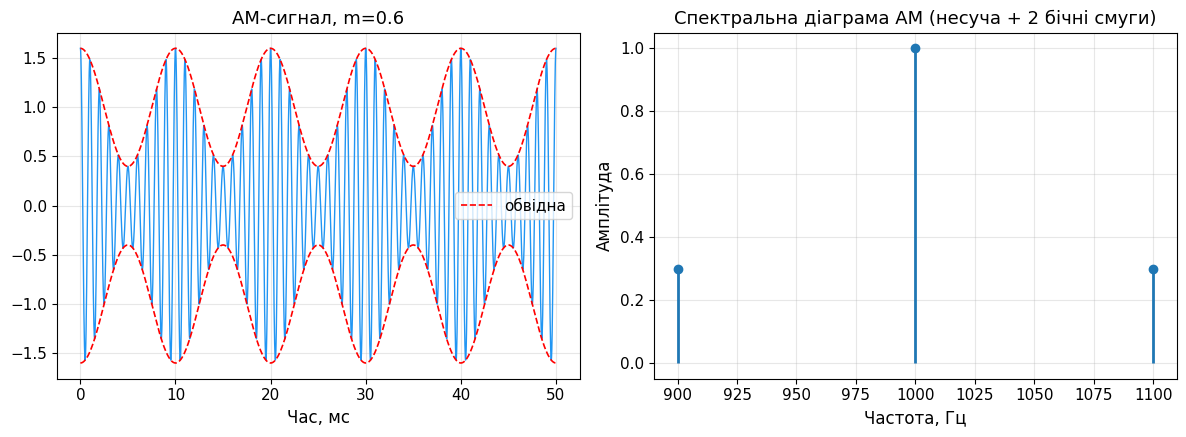

P_несуча = 0.500 (відн. од.), P_повна = 0.590, частка бічних смуг = 15.3%


In [33]:
# Амплітудна модуляція: часова діаграма і спектральна діаграма (3 лінії)
Um_am, f0_am, F_am, m_am = 1.0, 1000.0, 100.0, 0.6
w0_am, W_am = 2*np.pi*f0_am, 2*np.pi*F_am
t_am = np.linspace(0, 5/F_am, 5000)
s_am = Um_am*(1+m_am*np.cos(W_am*t_am))*np.cos(w0_am*t_am)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(t_am*1e3, s_am, '#2196F3', lw=1)
ax1.plot(t_am*1e3, Um_am*(1+m_am*np.cos(W_am*t_am)), 'r--', lw=1.2, label='обвідна')
ax1.plot(t_am*1e3, -Um_am*(1+m_am*np.cos(W_am*t_am)), 'r--', lw=1.2)
ax1.set_xlabel('Час, мс'); ax1.set_title(f'АМ-сигнал, m={m_am}'); ax1.legend()

freqs_am = [f0_am-F_am, f0_am, f0_am+F_am]
amps_am = [m_am*Um_am/2, Um_am, m_am*Um_am/2]
ax2.stem(freqs_am, amps_am, basefmt=' ')
ax2.set_xlabel('Частота, Гц'); ax2.set_ylabel('Амплітуда')
ax2.set_title('Спектральна діаграма АМ (несуча + 2 бічні смуги)')
plt.tight_layout(); plt.show()

P_carrier = Um_am**2/2
P_am_total = P_carrier*(1+m_am**2/2)
print(f'P_несуча = {P_carrier:.3f} (відн. од.), P_повна = {P_am_total:.3f}, частка бічних смуг = {(P_am_total-P_carrier)/P_am_total*100:.1f}%')


### Балансна та односмугова амплітудні модуляції <a class="anchor" id="dsb-ssb-modulation"></a>

**Балансна модуляція (DSB-SC — Double SideBand Suppressed Carrier)** отримується перемножувачем (балансним модулятором), а не суматором: несуча в спектрі відсутня (**придушена**):

$$s_{ДБП}(t) = mU_m\cos\Omega t \cdot \cos\omega_0t = \frac{mU_m}{2}\cos(\omega_0-\Omega)t + \frac{mU_m}{2}\cos(\omega_0+\Omega)t$$

Оскільки вся потужність тепер зосереджена лише в двох бічних смугах (немає «марної» несучої), ДБП ефективніше використовує потужність передавача, ніж класична АМ, але вимагає **когерентного (синхронного) детектування** на прийомі — простий діодний детектор обвідної тут не працює, оскільки немає несучої, відносно якої обвідна визначена.

**Односмугова модуляція (SSB/ОБП — Single SideBand)** передає лише **одну** бічну смугу (фільтрацією зайвої смуги або фазовим методом Хартлі), тому ширина спектра вдвічі менша:

$$\Delta f_{SSB} = F_{max}$$

**Порівняння видів амплітудної модуляції:**

| Вид | Ширина спектра | Потужність у несучій | Складність приймача |
|-----|-----------------|------------------------|------------------------|
| Класична АМ | $2F_{max}$ | Значна (до 2/3 повної при m=1) | Проста (детектор обвідної) |
| Балансна (ДБП) | $2F_{max}$ | Відсутня | Потрібне когерентне детектування |
| Односмугова (ОБП) | $F_{max}$ | Відсутня | Найскладніша (потрібен опорний генератор і фазування/фільтрація) |


### Фазова та частотна модуляції: спектральні діаграми та енергетичні характеристики <a class="anchor" id="fm-pm-modulation"></a>

Загальна форма кутово-модульованого коливання: $s(t)=U_m\cos(\omega_0t+\varphi(t))$. При **фазовій модуляції (ФМ)** фаза пропорційна модулюючому сигналу $\varphi(t)=k_ф s(t)$; при **частотній модуляції (ЧМ)** пропорційна модулюючому сигналу — миттєва частота $\omega(t)=\omega_0+k_ч s(t)$, тобто $\varphi(t)=k_ч\int s(t)\,dt$ — ФМ і ЧМ математично зв'язані інтегруванням/диференціюванням модулюючого сигналу.

Для тональної ЧМ ($s(t)=U_\Omega\cos\Omega t$):

$$s_{ЧМ}(t) = U_m\cos(\omega_0t + m_ч\sin\Omega t), \qquad m_ч=\frac{\Delta\omega}{\Omega}$$

де $m_ч$ — **індекс модуляції**, $\Delta\omega=k_чU_\Omega$ — **девіація частоти**. На відміну від АМ (лише 2 бічні складові), спектр ЧМ/ФМ навіть для однотонового модулюючого сигналу містить теоретично **нескінченну** кількість бічних складових на частотах $\omega_0\pm n\Omega$ з амплітудами $U_m J_n(m_ч)$, де $J_n$ — функції Бесселя першого роду порядку $n$.

**Практична ширина смуги — формула Карсона:**

$$\Delta f_{ЧМ} \approx 2\left(\Delta f_{дев}+F_{max}\right) = 2F_{max}(m_ч+1)$$

**Енергетика:** амплітуда несучої $U_m$ при кутовій модуляції залишається **сталою** незалежно від глибини модуляції, тому повна потужність сигналу $P=U_m^2/(2R)=\text{const}$ **не залежить** від індексу модуляції — вся інформація закодована у фазі/частоті, а не в амплітуді. Звідси головна перевага ЧМ/ФМ: висока завадостійкість — амплітудні завади (які додаються до сигналу адитивно) легко пригнічуються обмежувачем амплітуди на прийомі, не впливаючи на закодовану фазу.


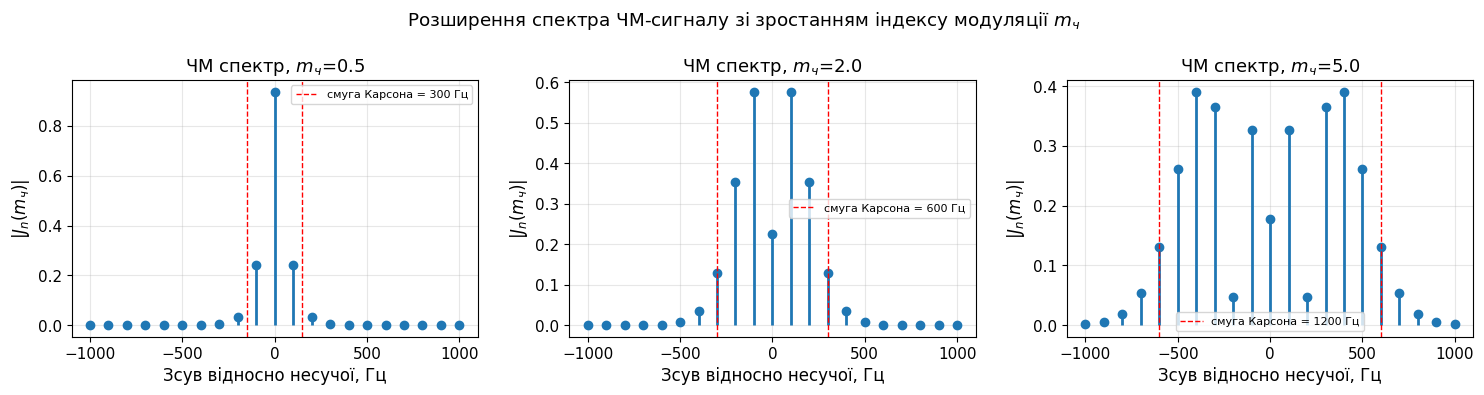

In [34]:
# Спектр частотно-модульованого сигналу через функції Бесселя (формула Карсона)
from scipy.special import jv

F_fm = 100.0
n_max = 10
ns_fm = np.arange(-n_max, n_max+1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, mf in zip(axes, [0.5, 2.0, 5.0]):
    amps_fm = np.abs(jv(ns_fm, mf))
    ax.stem(ns_fm*F_fm, amps_fm, basefmt=' ')
    carson_bw = 2*F_fm*(mf+1)
    ax.axvline(carson_bw/2, color='red', ls='--', lw=1)
    ax.axvline(-carson_bw/2, color='red', ls='--', lw=1, label=f'смуга Карсона = {carson_bw:.0f} Гц')
    ax.set_xlabel('Зсув відносно несучої, Гц'); ax.set_ylabel('$|J_n(m_ч)|$')
    ax.set_title(f'ЧМ спектр, $m_ч$={mf}')
    ax.legend(fontsize=8)
plt.suptitle('Розширення спектра ЧМ-сигналу зі зростанням індексу модуляції $m_ч$')
plt.tight_layout(); plt.show()


### Сигнали з обмеженим спектром <a class="anchor" id="band-limited-signals"></a>

Сигнал $s(t)$ називають **сигналом з обмеженим спектром**, якщо його спектральна густина дорівнює нулю поза деякою смугою: $F(j\omega)=0$ при $|\omega|>\omega_{max}=2\pi F_{max}$.

Строго кажучи, сигнал не може бути **одночасно** обмеженим і за часом, і за спектром (принцип невизначеності для сигналів: $\Delta t\cdot\Delta f \ge \text{const}$) — нескінченно довгий у часі сигнал теоретично потрібен, щоб мати строго нульовий спектр поза смугою. На практиці, однак, енергія реальних сигналів природно зосереджена у скінченній смузі частот, а позасмугова частина настільки мала, що нею нехтують без відчутної похибки.

Припущення про обмежений спектр — фундаментальна основа для **теореми Котельникова** (нижче): без нього неможливо точно (без втрати інформації) дискретизувати сигнал скінченною кількістю відліків.


### Теорема Котельникова. Побудова ортонормованого базису та ряд Котельникова <a class="anchor" id="kotelnikov-theorem"></a>

**Формулювання (теорема Котельникова, або Найквіста–Шеннона):** якщо сигнал $s(t)$ має спектр, обмежений частотою $F_{max}$, то він **повністю й однозначно** визначається своїми відліками (миттєвими значеннями), взятими через інтервал

$$\Delta t = \frac{1}{2F_{max}} \qquad\Longleftrightarrow\qquad f_д \ge 2F_{max} \;\text{(умова Найквіста)}$$

**Ряд Котельникова** (формула точного відновлення сигналу з відліків):

$$s(t) = \sum_{k=-\infty}^{\infty} s(k\Delta t)\cdot\operatorname{sinc}\!\left(\frac{t-k\Delta t}{\Delta t}\right), \qquad \operatorname{sinc}(x)=\frac{\sin(\pi x)}{\pi x}$$

Базисні функції $\varphi_k(t)=\operatorname{sinc}\!\left(\dfrac{t}{\Delta t}-k\right)$ утворюють **ортонормований базис** у просторі сигналів з обмеженим спектром $F_{max}$: інтеграл добутку двох зсунутих sinc-функцій дорівнює $\displaystyle\int\varphi_k(t)\varphi_l(t)\,dt=\Delta t\cdot\delta_{kl}$ — це прямий приклад скалярного добутку й ортогональності з розділу «Функціональний аналіз» вище. Коефіцієнти розкладу за цим базисом (узагальнений ряд Фур'є, розділ вище) якраз і є самі відліки сигналу $s(k\Delta t)$.

**Якщо умова Найквіста не виконується** ($f_д<2F_{max}$), спектри сусідніх копій сигналу (що виникають при дискретизації) перекриваються — виникає **накладання спектрів (аліасинг)**, і точне відновлення оригінального сигналу за відліками стає неможливим. Саме тому перед АЦП завжди встановлюють **протиаліасинговий (anti-aliasing) фільтр**, що обмежує смугу вхідного сигналу до $F_{max}<f_д/2$.


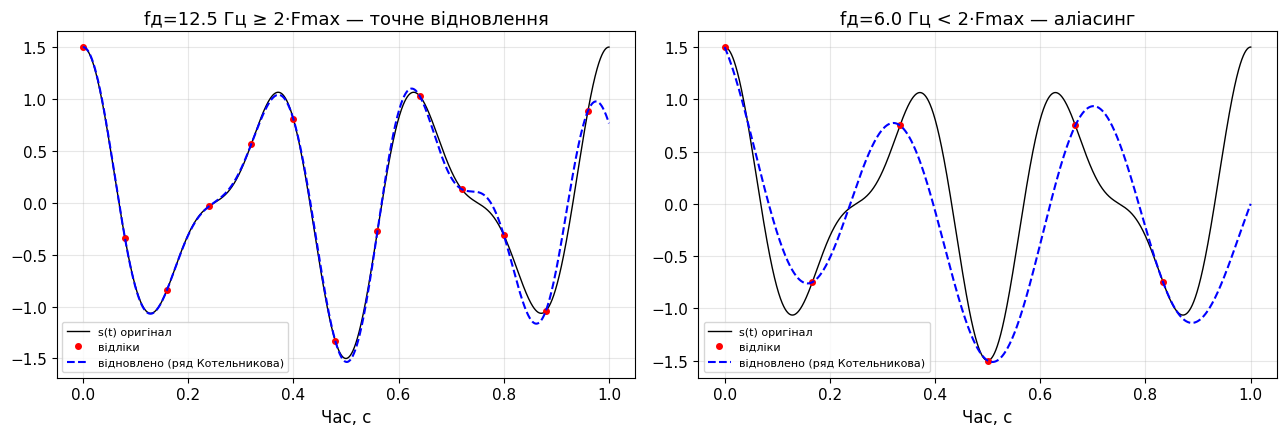

Fmax = 5.0 Гц, умова Найквіста: fд ≥ 10.0 Гц


In [35]:
# Демонстрація теореми Котельникова: дискретизація і точне відновлення сигналу з обмеженим спектром
Fmax_k = 5.0             # максимальна частота в спектрі сигналу, Гц
fd_ok = 2.5*Fmax_k       # частота дискретизації ВИЩЕ Найквіста (умова виконана)
fd_bad = 1.2*Fmax_k      # частота дискретизації НИЖЧЕ Найквіста (аліасинг)

def s_signal(t):
    return np.cos(2*np.pi*3*t) + 0.5*np.cos(2*np.pi*Fmax_k*t)

t_cont = np.linspace(0, 1, 4000)
s_cont = s_signal(t_cont)

def sample_and_reconstruct(fd):
    dt = 1/fd
    t_samples = np.arange(0, 1, dt)
    s_samples = s_signal(t_samples)
    # ряд Котельникова: сума зсунутих sinc
    recon = np.array([np.sum(s_samples*np.sinc((tt-t_samples)/dt)) for tt in t_cont])
    return t_samples, s_samples, recon

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, fd, title in [(axes[0], fd_ok, f'fд={fd_ok:.1f} Гц ≥ 2·Fmax — точне відновлення'),
                       (axes[1], fd_bad, f'fд={fd_bad:.1f} Гц < 2·Fmax — аліасинг')]:
    t_s, s_s, recon = sample_and_reconstruct(fd)
    ax.plot(t_cont, s_cont, 'k-', lw=1, label='s(t) оригінал')
    ax.plot(t_s, s_s, 'ro', ms=4, label='відліки')
    ax.plot(t_cont, recon, 'b--', lw=1.5, label='відновлено (ряд Котельникова)')
    ax.set_xlabel('Час, с'); ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f'Fmax = {Fmax_k} Гц, умова Найквіста: fд ≥ {2*Fmax_k} Гц')


---
### ⚡ Практичне застосування: Кореляційний аналіз і модуляція сигналів

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Застосування | Що саме використовується |
|--------------|-----------------------------|
| **Радіолокація, гідролокація, GPS** | Взаємокореляція прийнятого сигналу з опорним — вимірювання затримки (відстані) |
| **Синхронізація в цифровому зв'язку (Wi-Fi, LTE, 5G)** | Автокореляція преамбули для виявлення початку кадру й символьної синхронізації |
| **Радіомовлення АМ (ДХ/СХ/КХ)** | Класична АМ — простий детектор обвідної на прийомі |
| **Стереомовлення УКХ, супутниковий зв'язок** | Балансна й однополосна модуляція — економія потужності і смуги |
| **Радіомовлення ЧМ (УКХ), стільниковий зв'язок** | Частотна модуляція — висока завадостійкість |
| **АЦП, цифрова обробка сигналів** | Теорема Котельникова визначає мінімально допустиму частоту дискретизації; протиаліасинговий фільтр — обов'язковий елемент будь-якого АЦП-тракту |

</div>

---
### ✅ Питання для самоперевірки: Кореляційний аналіз та модуляція сигналів

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чим енергетичний спектр одного сигналу відрізняється від взаємної спектральної густини двох сигналів?</summary>

> **Відповідь:** Енергетичний спектр $W(\omega)=|F(j\omega)|^2$ одного сигналу — дійсна, невід'ємна, парна функція. Взаємна спектральна густина $W_{xy}(\omega)=X(j\omega)Y^*(j\omega)$ двох різних сигналів — комплексна і, взагалі, не парна функція; вона характеризує узгодженість (кореляцію) сигналів на кожній частоті, а не енергію одного сигналу.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому автокореляційна функція завжди досягає максимуму саме при τ=0?</summary>

> **Відповідь:** $R_x(0)=\int|x(t)|^2dt=E$ — енергія сигналу. За нерівністю Коші–Буняковського $|R_x(\tau)|\le R_x(0)$ для будь-якого зсуву τ: жодна зсунута копія сигналу не може корелювати з оригіналом сильніше, ніж сигнал сам із собою без зсуву.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Як взаємокореляційна функція дозволяє визначити затримку сигналу (наприклад, у радарі)?</summary>

> **Відповідь:** Обчислюють $R_{xy}(\tau)$ між випроміненим (опорним) і прийнятим (відбитим) сигналами для різних τ; положення максимуму $\tau_{max}$ вказує затримку поширення сигналу, за якою (знаючи швидкість поширення) обчислюють відстань до цілі.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> У чому головний недолік класичної амплітудної модуляції з погляду енергетики?</summary>

> **Відповідь:** При максимальній глибині модуляції m=1 обидві бічні смуги (які й переносять інформацію) несуть разом лише 1/3 повної потужності сигналу — решта 2/3 витрачається на несучу, яка сама по собі інформації не містить.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 5.</b> Чим балансна модуляція (ДБП) відрізняється від класичної АМ і яка за це ціна?</summary>

> **Відповідь:** У ДБП несуча пригнічена, вся потужність зосереджена в двох бічних смугах — це ефективніше використання потужності передавача. Ціна — потрібне когерентне (синхронне) детектування на прийомі, оскільки простий детектор обвідної без несучої не працює.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 6.</b> Чому спектр ЧМ-сигналу (навіть при тональній модуляції) містить нескінченну кількість бічних складових, на відміну від АМ?</summary>

> **Відповідь:** Амплітуда ЧМ-коливання $U_m\cos(\omega_0t+m_ч\sin\Omega t)$ — нелінійна функція часу (аргумент косинуса містить $\sin\Omega t$ всередині), тому розклад у ряд Фур'є за гармоніками $\Omega$ дає нескінченну суму членів з коефіцієнтами — функціями Бесселя $J_n(m_ч)$, а не лише дві бічні складові, як у лінійній (за амплітудою) АМ.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 7.</b> Сигнал має максимальну частоту спектра Fmax=4 кГц. Яка мінімальна частота дискретизації і мінімальний інтервал між відліками?</summary>

> **Відповідь:** $f_д\ge2F_{max}=8$ кГц (умова Найквіста), $\Delta t=1/(2F_{max})=125$ мкс.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 8.</b> Що станеться, якщо дискретизувати сигнал з частотою, нижчою за частоту Найквіста?</summary>

> **Відповідь:** Виникне накладання (аліасинг) спектрів сусідніх копій дискретизованого сигналу — високочастотні складові оригіналу «підмінять» низькочастотні в спектрі відновленого сигналу, і точне відновлення оригінального сигналу за відліками стане неможливим.

</details>

---

## 📌 Підсумок курсу: Основи радіоелектроніки. Частина 2

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

### Зведена таблиця методів аналізу перехідних процесів

| Метод | Область застосування | Переваги | Обмеження |
|-------|---------------------|---------|-----------|
| **Класичний** | Прості RL, RC ланцюги | Наочний, фізична інтерпретація | Складний для вищих порядків |
| **Операторний (Лапласа)** | Будь-які лінійні кола | Зведення до алгебри, враховує початкові умови | Потребує таблиць |
| **Частотний (Фур'є)** | Стаціонарні сигнали | Спектральний аналіз, фільтрація | Тільки для стаціонарних сигналів |

### Зв'язок між методами

$$\text{Часова область} \xleftrightarrow{\mathcal{L}} \text{Операторна (Лапласа)} \xleftrightarrow{p=j\omega} \text{Частотна (Фур'є)}$$

### ⚡ Практичне застосування в радіотехніці

- **RL, RC ланцюги** — фільтри, інтегруючі та диференціюючі схеми
- **RLC ланцюги** — резонансні підсилювачі, смугові фільтри, осцилятори
- **Довга лінія** — коаксіальні кабелі, мікросмужкові лінії, антенні фідери
- **Ряди Фур'є** — спектральний аналіз, модуляція, синтез сигналів

</div>

---

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
